# Quantum-Classical Hybrid Heart Failure Death Event Prediction
## A Comprehensive Benchmark for Publication

**Dataset:** Heart Failure Clinical Records (299 patients, 12 features, binary target: DEATH_EVENT)  
**Models:** LR · SVM · RF · MLP · VQC · QCNN · QKernel-SVM · QAOA-VQC · HybridNet · QuantumBoost · QResNet  
**Experiments:** Input-size sweep · Ablation · 5-fold CV · Noise analysis · Hardware capture · Statistical tests  
**Hardware:** IBM Quantum (ibm_fez) real-device results with full metrics  
**Outputs:** `outputs/heartdisease/` · **Visualizations:** `results/heartdisease/`

## 0) Installation

In [1]:
# Run once if needed
# !pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms qiskit-ibm-runtime
# !pip install scikit-learn scipy matplotlib seaborn imbalanced-learn

## 1) Imports & Global Config

In [2]:
import time, warnings, itertools, os, json, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

from typing import Dict, Any, List, Tuple, Optional
from dataclasses import dataclass, field
from collections import Counter

# ── Sklearn ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              classification_report)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import ttest_rel, wilcoxon, mannwhitneyu, friedmanchisquare

# ── Imbalanced-learn ──────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("[WARN] imbalanced-learn not found – using fallback resampling")

# ── Qiskit ────────────────────────────────────────────────
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliFeatureMap
    from qiskit.primitives import Sampler as LocalSampler
    from qiskit.quantum_info import SparsePauliOp
    from qiskit_aer import Aer, AerSimulator
    from qiskit_aer.noise import (NoiseModel, depolarizing_error,
                                   amplitude_damping_error, pauli_error)
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    try:
        from qiskit_algorithms.optimizers import COBYLA, SPSA, L_BFGS_B
    except ImportError:
        from qiskit.algorithms.optimizers import COBYLA, SPSA, L_BFGS_B
    HAS_QISKIT = True
    print(f"[OK] Qiskit available")
except ImportError:
    HAS_QISKIT = False
    print("[INFO] Qiskit not found – numpy quantum simulator will be used")

GLOBAL_SEED = 42
DATASET_PATH = 'datasets/heart_failure_clinical_records_dataset.csv'
OUT_DIR = 'outputs/heartdisease/'
RES_DIR = 'results/heartdisease/'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

def set_seed(seed=GLOBAL_SEED):
    np.random.seed(seed)

set_seed()
print("Imports done. Output dirs created.")

[OK] Qiskit available
Imports done. Output dirs created.


## 2) Data Loading & EDA

In [3]:
# ── Load dataset ─────────────────────────────────────────
df_raw = pd.read_csv(DATASET_PATH)
TARGET_COL = 'DEATH_EVENT'
FEATURE_COLS = [c for c in df_raw.columns if c != TARGET_COL]

X_df = df_raw[FEATURE_COLS].copy()
y_s  = df_raw[TARGET_COL].copy()

print("Shape:", X_df.shape)
print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print("\nClass distribution:")
vc = y_s.value_counts().rename({0: 'Survived', 1: 'Died'})
print(vc)
print(f"\nClass imbalance ratio: {vc.max()/vc.min():.2f}:1")
print("\nMissing values:", X_df.isnull().sum().sum())
print("\nFeature statistics:")
print(X_df.describe().round(2))

Shape: (299, 12)

Features (12): ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']

Class distribution:
DEATH_EVENT
Survived    203
Died         96
Name: count, dtype: int64

Class imbalance ratio: 2.11:1

Missing values: 0

Feature statistics:
          age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
count  299.00   299.00                    299.00    299.00             299.00   
mean    60.83     0.43                    581.84      0.42              38.08   
std     11.89     0.50                    970.29      0.49              11.83   
min     40.00     0.00                     23.00      0.00              14.00   
25%     51.00     0.00                    116.50      0.00              30.00   
50%     60.00     0.00                    250.00      0.00              38.00   
75%     70.00     1.00                    582.00      1.00  

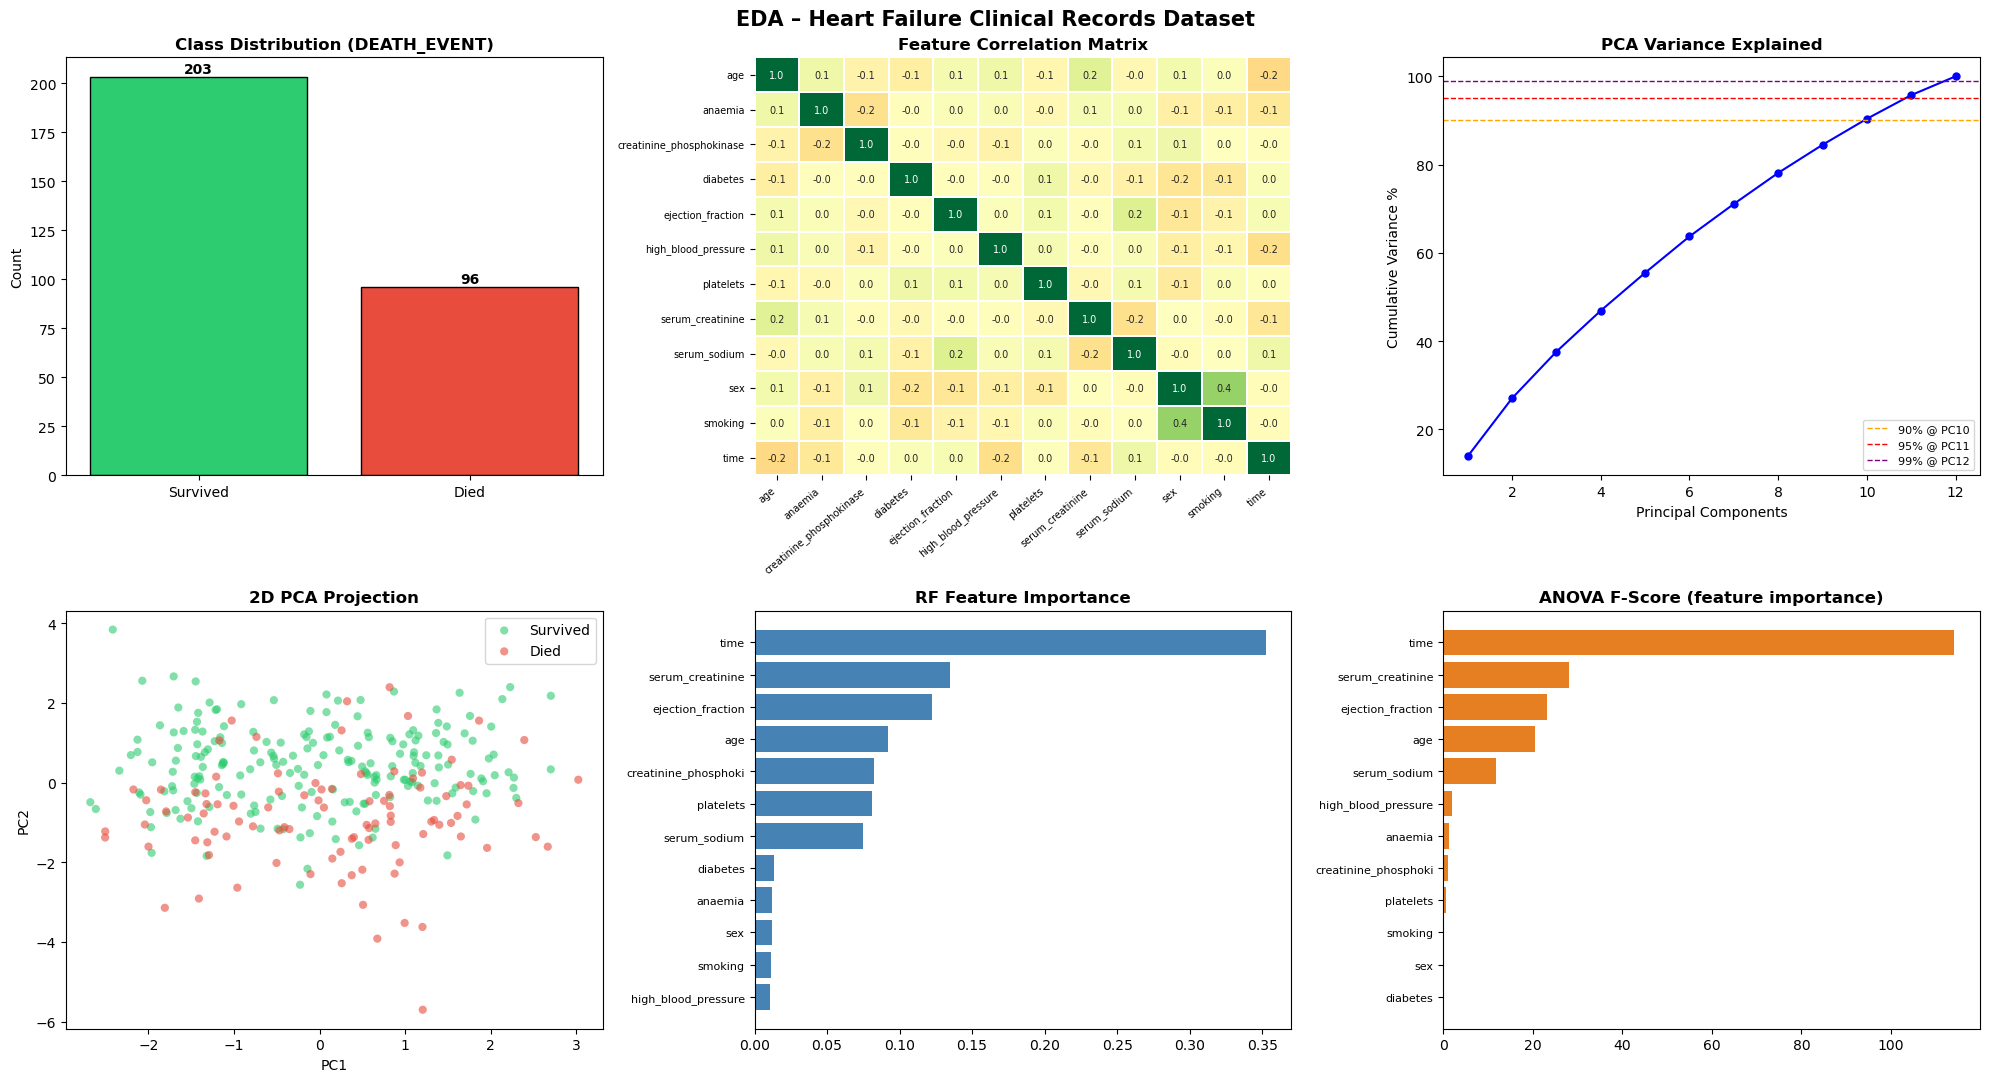

EDA plot saved.


In [4]:
# ── EDA Plots ─────────────────────────────────────────────
scaler_eda = StandardScaler()
Xs_eda = scaler_eda.fit_transform(X_df)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('EDA – Heart Failure Clinical Records Dataset', fontsize=15, fontweight='bold')

# 1) Class distribution
cnts = y_s.value_counts().rename({0: 'Survived', 1: 'Died'})
bars = axes[0,0].bar(cnts.index, cnts.values, color=['#2ecc71','#e74c3c'], edgecolor='k')
for bar, v in zip(bars, cnts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+2, str(v), ha='center', fontweight='bold')
axes[0,0].set_title('Class Distribution (DEATH_EVENT)', fontweight='bold')
axes[0,0].set_ylabel('Count')

# 2) Correlation heatmap
corr_df = pd.DataFrame(Xs_eda, columns=FEATURE_COLS)
corr = corr_df.corr()
sns.heatmap(corr, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=axes[0,1], cbar=False, linewidths=0.3, annot_kws={'size':7})
axes[0,1].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0,1].tick_params(labelsize=7)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=40, ha='right')

# 3) PCA variance explained
pca_full = PCA(random_state=GLOBAL_SEED).fit(Xs_eda)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[0,2].plot(range(1, len(cumvar)+1), cumvar*100, 'b-o', ms=5)
for thresh, col in [(0.90,'orange'), (0.95,'red'), (0.99,'purple')]:
    n = np.searchsorted(cumvar, thresh) + 1
    axes[0,2].axhline(thresh*100, color=col, ls='--', lw=1, label=f'{thresh*100:.0f}% @ PC{n}')
axes[0,2].set_xlabel('Principal Components')
axes[0,2].set_ylabel('Cumulative Variance %')
axes[0,2].set_title('PCA Variance Explained', fontweight='bold')
axes[0,2].legend(fontsize=8)

# 4) 2D PCA scatter
pca2 = PCA(2, random_state=GLOBAL_SEED).fit_transform(Xs_eda)
for lbl, col, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Survived','Died']):
    m = y_s == lbl
    axes[1,0].scatter(pca2[m,0], pca2[m,1], c=col, label=name,
                      alpha=0.6, s=35, edgecolors='none')
axes[1,0].set_title('2D PCA Projection', fontweight='bold')
axes[1,0].legend()
axes[1,0].set_xlabel('PC1'); axes[1,0].set_ylabel('PC2')

# 5) RF Feature importance
rf_eda = RandomForestClassifier(200, random_state=GLOBAL_SEED).fit(Xs_eda, y_s)
imp = rf_eda.feature_importances_
idx = np.argsort(imp)[::-1]
axes[1,1].barh(range(len(FEATURE_COLS)), imp[idx][::-1], color='steelblue')
axes[1,1].set_yticks(range(len(FEATURE_COLS)))
axes[1,1].set_yticklabels([FEATURE_COLS[i][:20] for i in idx[::-1]], fontsize=8)
axes[1,1].set_title('RF Feature Importance', fontweight='bold')

# 6) ANOVA F-score
f_scores, _ = f_classif(Xs_eda, y_s)
idx_f = np.argsort(f_scores)[::-1]
axes[1,2].barh(range(len(FEATURE_COLS)), f_scores[idx_f][::-1], color='#e67e22')
axes[1,2].set_yticks(range(len(FEATURE_COLS)))
axes[1,2].set_yticklabels([FEATURE_COLS[i][:20] for i in idx_f[::-1]], fontsize=8)
axes[1,2].set_title('ANOVA F-Score (feature importance)', fontweight='bold')

plt.tight_layout()
plt.savefig(RES_DIR + 'eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA plot saved.")

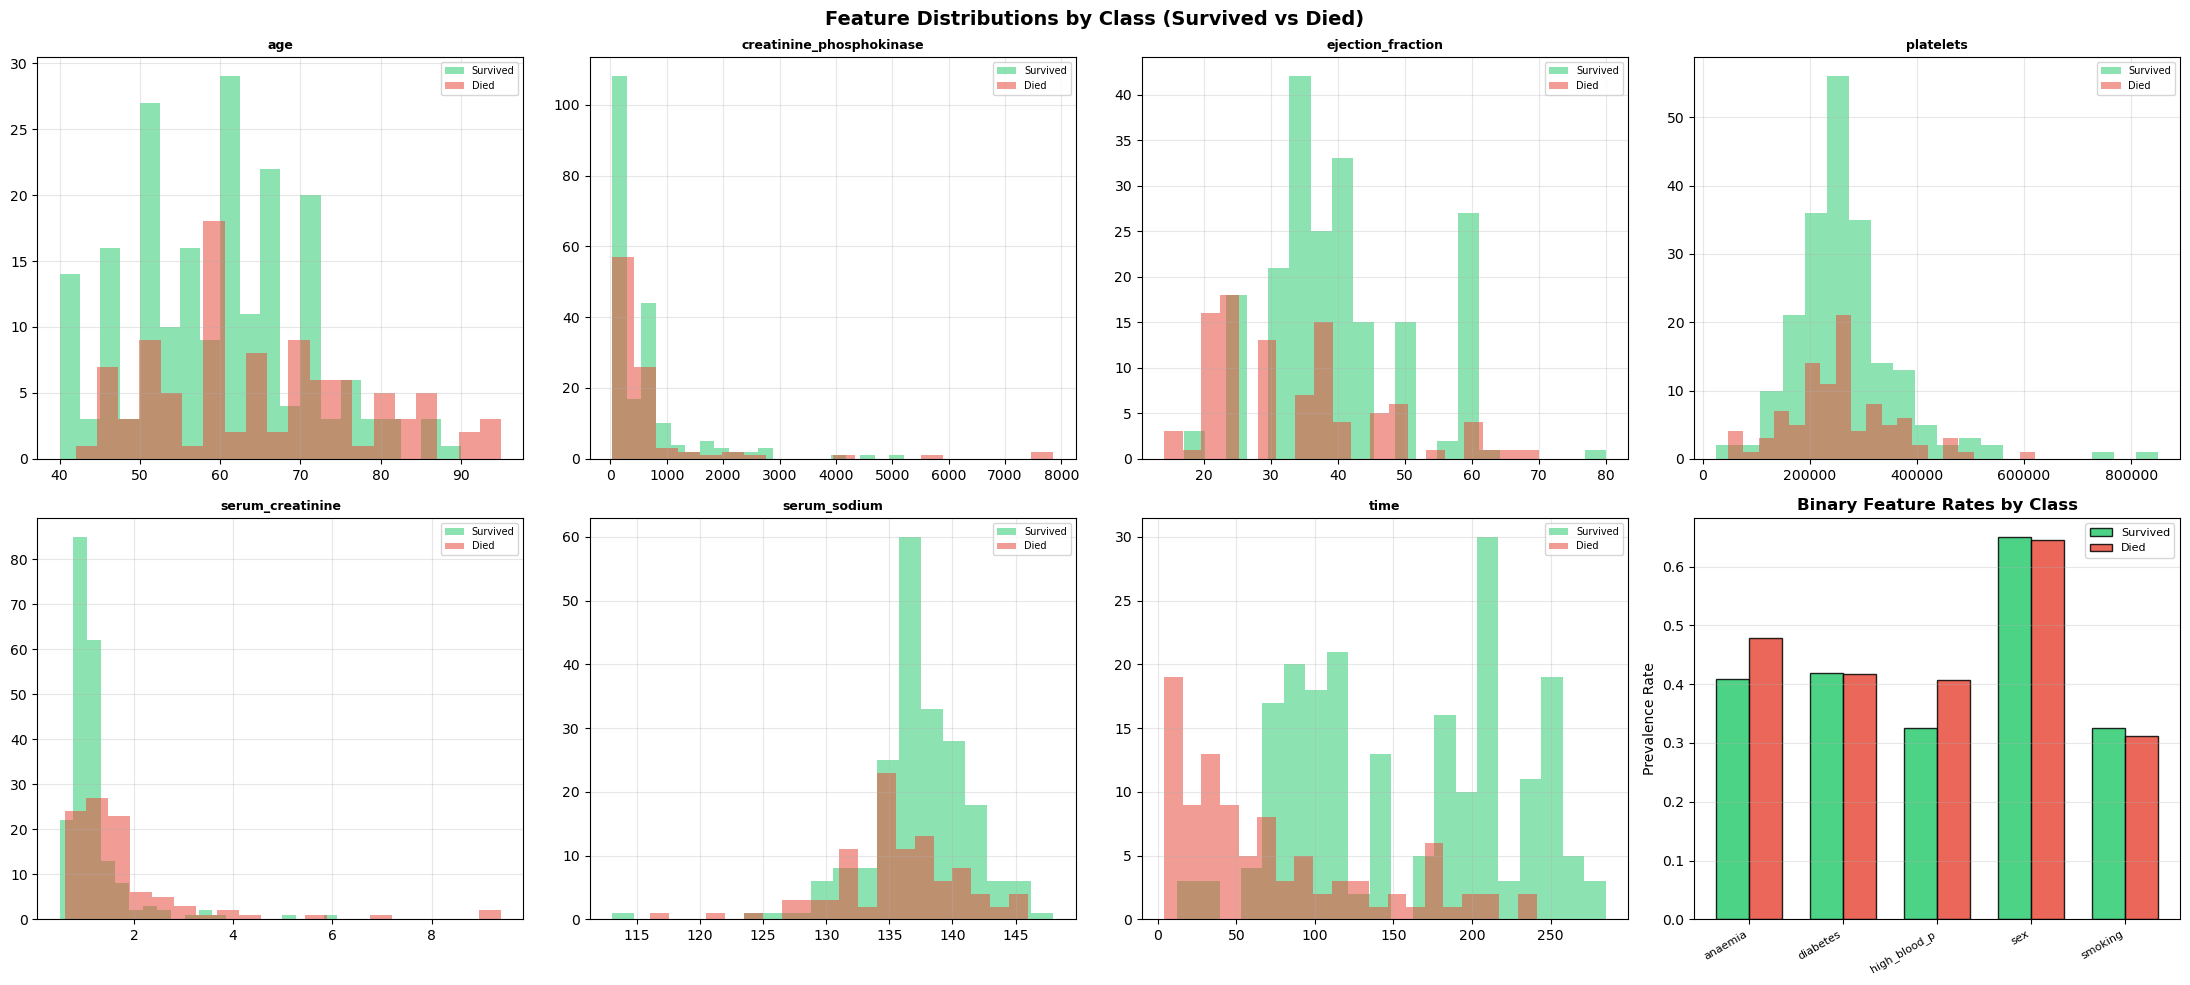

Feature distribution plots saved.


In [5]:
# ── Additional EDA: Feature distributions by class ────────
continuous_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                        'platelets', 'serum_creatinine', 'serum_sodium', 'time']
binary_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

n_cont = len(continuous_features)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Feature Distributions by Class (Survived vs Died)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    for lbl, col, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Survived','Died']):
        vals = df_raw[df_raw[TARGET_COL]==lbl][feat]
        ax.hist(vals, bins=20, alpha=0.55, color=col, label=name, edgecolor='none')
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Binary feature bar chart
ax = axes[n_cont]
x = np.arange(len(binary_features))
w = 0.35
for shift, lbl, col, name in [(-w/2, 0, '#2ecc71', 'Survived'), (w/2, 1, '#e74c3c', 'Died')]:
    rates = [df_raw[df_raw[TARGET_COL]==lbl][f].mean() for f in binary_features]
    ax.bar(x + shift, rates, w, color=col, label=name, edgecolor='k', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f[:12] for f in binary_features], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Prevalence Rate')
ax.set_title('Binary Feature Rates by Class', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

for ax in axes[n_cont+1:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(RES_DIR + 'feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Feature distribution plots saved.")

## 3) Adaptive Feature Selection

In [6]:
def select_relevant_features(X: pd.DataFrame, y: pd.Series,
                              threshold_cumvar: float = 0.95,
                              min_features: int = 4) -> Tuple[List[str], np.ndarray]:
    """
    Multi-method feature selection:
    1. ANOVA filter: keep features with F-score above median
    2. RF importance filter: keep features with importance > mean
    3. Mutual information filter: keep features above median
    4. Union of 2+ method agreement
    Returns: (selected_feature_names, feature_indices)
    """
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    f_scores, _ = f_classif(Xs, y)
    anova_mask = f_scores >= np.median(f_scores)

    rf = RandomForestClassifier(300, random_state=GLOBAL_SEED).fit(Xs, y)
    rf_mask = rf.feature_importances_ >= rf.feature_importances_.mean()

    mi_scores = mutual_info_classif(Xs, y, random_state=GLOBAL_SEED)
    mi_mask = mi_scores >= np.median(mi_scores)

    vote = anova_mask.astype(int) + rf_mask.astype(int) + mi_mask.astype(int)
    selected_mask = vote >= 2

    if selected_mask.sum() < min_features:
        top_idx = np.argsort(f_scores)[::-1][:min_features]
        selected_mask = np.zeros(len(f_scores), dtype=bool)
        selected_mask[top_idx] = True

    selected_names = X.columns[selected_mask].tolist()
    selected_idx = np.where(selected_mask)[0]

    pca_check = PCA(random_state=GLOBAL_SEED).fit(Xs[:, selected_idx])
    covered = np.sum(pca_check.explained_variance_ratio_)

    print(f"Feature selection: {selected_mask.sum()}/{len(f_scores)} features selected")
    print(f"  Variance covered by selected features: {covered:.3f}")
    print(f"  Selected: {selected_names}")

    return selected_names, selected_idx


relevant_features, relevant_idx = select_relevant_features(X_df, y_s)
X_relevant = X_df[relevant_features].values
print(f"\nUsing {len(relevant_features)} relevant features for quantum models")
print(f"Full feature set ({len(FEATURE_COLS)}) used for classical models")

Feature selection: 5/12 features selected
  Variance covered by selected features: 1.000
  Selected: ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']

Using 5 relevant features for quantum models
Full feature set (12) used for classical models


## 4) Preprocessing & Resampling Utilities

In [7]:
def apply_resampling(X, y, strategy='smote', seed=GLOBAL_SEED):
    if strategy == 'none':
        return X, y
    if HAS_IMBLEARN:
        sampler = SMOTE(random_state=seed) if strategy=='smote' else SMOTETomek(random_state=seed)
        return sampler.fit_resample(X, y)
    # fallback minority oversampling
    rng = np.random.default_rng(seed)
    minority = np.where(y==1)[0]
    majority = np.where(y==0)[0]
    dup = rng.choice(minority, size=len(majority)-len(minority), replace=True)
    Xr = np.vstack([X, X[dup]])
    yr = np.concatenate([y, y[dup]])
    perm = rng.permutation(len(yr))
    return Xr[perm], yr[perm]


def preprocess_dataset(X, y, n_features, seed=GLOBAL_SEED, test_size=0.2,
                        resample='smote', use_pca=True):
    """
    Split → resample → scale → (optionally PCA to n_features).
    Returns: Xtr, Xte, ytr, yte
    """
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                            stratify=y, random_state=seed)
    if resample != 'none':
        Xtr, ytr = apply_resampling(Xtr, ytr, strategy=resample, seed=seed)

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    if use_pca and n_features < Xtr.shape[1]:
        pca = PCA(n_components=n_features, random_state=seed)
        Xtr = pca.fit_transform(Xtr)
        Xte = pca.transform(Xte)

    return Xtr, Xte, ytr, yte


print("Preprocessing functions ready.")

Preprocessing functions ready.


## 5) Quantum Feature Encoders & Numpy Quantum Simulators

In [8]:
class ZZFeatureEncoder:
    """ZZFeatureMap-style encoding: rotations + pairwise ZZ interactions."""
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits

    def encode(self, x):
        x = x[:self.n_qubits]
        feats = list(x)
        for i in range(self.n_qubits - 1):
            feats.append((np.pi - x[i]) * (np.pi - x[i+1]))
        return np.array(feats)

    def encode_batch(self, X):
        return np.array([self.encode(xi) for xi in X])

    @property
    def dim(self):
        return self.n_qubits + (self.n_qubits - 1)


class PauliEncoder:
    """Pauli-style: includes cross terms up to 3-body."""
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits

    def encode(self, x):
        x = x[:self.n_qubits]
        feats = list(x)
        for i in range(self.n_qubits-1):
            feats.append(x[i]*x[i+1])
        for i in range(self.n_qubits-2):
            feats.append(x[i]*x[i+1]*x[i+2])
        return np.array(feats)

    def encode_batch(self, X):
        return np.array([self.encode(xi) for xi in X])

    @property
    def dim(self):
        return self.n_qubits + (self.n_qubits-1) + (self.n_qubits-2)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


class NumpyVQC(BaseEstimator, ClassifierMixin):
    """Variational Quantum Classifier (numpy simulation)."""
    def __init__(self, n_qubits=4, reps=2, shots=512, seed=GLOBAL_SEED,
                 maxiter=100, encoder='zz'):
        self.n_qubits=n_qubits; self.reps=reps; self.shots=shots
        self.seed=seed; self.maxiter=maxiter; self.encoder=encoder

    def _get_encoder(self):
        return ZZFeatureEncoder(self.n_qubits) if self.encoder=='zz' else PauliEncoder(self.n_qubits)

    def _shot_noise(self, p):
        return np.clip(p + np.random.randn(*p.shape)/np.sqrt(self.shots), 0, 1)

    def _loss(self, params, Xe, y):
        p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
        p = np.clip(p, 1e-7, 1-1e-7)
        return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe = enc.encode_batch(X)
        d = enc.dim
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.15
        for it in range(self.maxiter):
            self.loss_curve_.append(self._loss(params, Xe, y))
            grad = np.zeros_like(params)
            for i in range(len(params)):
                p_p = params.copy(); p_p[i] += np.pi/2
                p_m = params.copy(); p_m[i] -= np.pi/2
                grad[i] = (self._loss(p_p,Xe,y) - self._loss(p_m,Xe,y)) / 2
            params -= lr * grad
            lr *= 0.997
        self.params_ = params
        self.enc_ = enc
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self.enc_.encode_batch(X)
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


class NumpyQCNN(NumpyVQC):
    """QCNN: conv+pool on top of ZZ encoding."""
    def __init__(self, **kw):
        super().__init__(**kw)

    def _conv_pool(self, Xe):
        conv = np.array([Xe[:,i]*Xe[:,i+1] for i in range(Xe.shape[1]-1)]).T
        pool = np.array([conv[:,2*i:2*i+2].mean(1) for i in range(conv.shape[1]//2)]).T
        return np.hstack([Xe, conv, pool])

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe_raw = enc.encode_batch(X)
        Xe = self._conv_pool(Xe_raw)
        d = Xe.shape[1]
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.15
        for it in range(self.maxiter):
            p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
            p = np.clip(p, 1e-7, 1-1e-7)
            loss = -np.mean(y*np.log(p) + (1-y)*np.log(1-p))
            self.loss_curve_.append(loss)
            grad = np.zeros_like(params)
            eps = 1e-4
            for i in range(len(params)):
                pp = params.copy(); pp[i]+=eps
                pm = params.copy(); pm[i]-=eps
                lp = -np.mean(y*np.log(np.clip(sigmoid(Xe@pp[:-1]+pp[-1]),1e-7,1-1e-7))
                              + (1-y)*np.log(np.clip(1-sigmoid(Xe@pp[:-1]+pp[-1]),1e-7,1-1e-7)))
                lm = -np.mean(y*np.log(np.clip(sigmoid(Xe@pm[:-1]+pm[-1]),1e-7,1-1e-7))
                              + (1-y)*np.log(np.clip(1-sigmoid(Xe@pm[:-1]+pm[-1]),1e-7,1-1e-7)))
                grad[i] = (lp-lm)/(2*eps)
            params -= lr*grad; lr*=0.997
        self.params_ = params; self.enc_ = enc; self.classes_ = np.array([0,1])
        self._Xe_train = Xe
        return self

    def predict_proba(self, X):
        Xe_raw = self.enc_.encode_batch(X)
        Xe = self._conv_pool(Xe_raw)
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])


class NumpyQAOA(NumpyVQC):
    """QAOA-inspired: alternating cost/mixer layers."""
    def _encode_qaoa(self, Xe):
        cost = np.tanh(Xe)
        mixer = np.roll(cost, 1, axis=1) * cost
        return np.hstack([cost, mixer])

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe = self._encode_qaoa(enc.encode_batch(X))
        d = Xe.shape[1]
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.12
        for it in range(self.maxiter):
            p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
            p = np.clip(p, 1e-7, 1-1e-7)
            self.loss_curve_.append(-np.mean(y*np.log(p)+(1-y)*np.log(1-p)))
            grad = np.zeros_like(params)
            for i in range(len(params)):
                pp=params.copy(); pp[i]+=np.pi/2
                pm=params.copy(); pm[i]-=np.pi/2
                f = lambda p_: -np.mean(y*np.log(np.clip(self._shot_noise(
                    sigmoid(Xe@p_[:-1]+p_[-1])),1e-7,1-1e-7))
                    +(1-y)*np.log(np.clip(1-self._shot_noise(
                    sigmoid(Xe@p_[:-1]+p_[-1])),1e-7,1-1e-7)))
                grad[i] = (f(pp)-f(pm))/2
            params -= lr*grad; lr*=0.997
        self.params_=params; self.enc_=enc; self.classes_=np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self._encode_qaoa(self.enc_.encode_batch(X))
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])


class NumpyQKernelSVM(BaseEstimator, ClassifierMixin):
    """Quantum Kernel SVM: fidelity kernel via inner-product of encoded states."""
    def __init__(self, n_qubits=4, C=1.0, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.C=C; self.seed=seed

    def _kernel(self, X1, X2):
        enc = ZZFeatureEncoder(self.n_qubits)
        Z1 = enc.encode_batch(X1)
        Z2 = enc.encode_batch(X2)
        n1 = np.linalg.norm(Z1, axis=1, keepdims=True) + 1e-10
        n2 = np.linalg.norm(Z2, axis=1, keepdims=True) + 1e-10
        K = (Z1/n1) @ (Z2/n2).T
        return K**2

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        K = self._kernel(X, X)
        self.svm_ = SVC(kernel='precomputed', C=self.C, probability=True,
                         random_state=self.seed)
        self.svm_.fit(K, y)
        self.classes_ = np.array([0,1])
        self.loss_curve_ = []
        return self

    def predict_proba(self, X):
        K = self._kernel(X, self.X_train_)
        return self.svm_.predict_proba(K)

    def predict(self, X):
        K = self._kernel(X, self.X_train_)
        return self.svm_.predict(K)

print("Numpy quantum simulators ready.")

Numpy quantum simulators ready.


## 6) Hybrid Models

In [9]:
class HybridNet(BaseEstimator, ClassifierMixin):
    """
    Quantum Feature Extractor + Classical MLP.
    Architecture: Input → ZZFeatureMap (numpy) → Classical MLP(32,16) → Output
    """
    def __init__(self, n_qubits=4, hidden=(32,16), seed=GLOBAL_SEED, maxiter=300):
        self.n_qubits=n_qubits; self.hidden=hidden
        self.seed=seed; self.maxiter=maxiter

    def fit(self, X, y):
        enc = ZZFeatureEncoder(self.n_qubits)
        Xe = enc.encode_batch(X)
        X_aug = np.hstack([X[:,:self.n_qubits], Xe])
        self.enc_ = enc
        self.mlp_ = MLPClassifier(hidden_layer_sizes=self.hidden,
                                   max_iter=self.maxiter,
                                   random_state=self.seed,
                                   early_stopping=True)
        self.mlp_.fit(X_aug, y)
        self.loss_curve_ = list(self.mlp_.loss_curve_) if hasattr(self.mlp_,'loss_curve_') else []
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self.enc_.encode_batch(X)
        X_aug = np.hstack([X[:,:self.n_qubits], Xe])
        return self.mlp_.predict_proba(X_aug)

    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


class QuantumBoost(BaseEstimator, ClassifierMixin):
    """
    Quantum Residual Features + Gradient Boosting Classifier.
    Architecture: Input → [ZZ features || Pauli features || raw] → GradientBoostingClassifier
    """
    def __init__(self, n_qubits=4, n_estimators=100, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.n_estimators=n_estimators; self.seed=seed

    def _quantum_features(self, X):
        zz = ZZFeatureEncoder(self.n_qubits).encode_batch(X)
        pau = PauliEncoder(self.n_qubits).encode_batch(X)
        raw = X[:, :self.n_qubits]
        residual = zz[:, :self.n_qubits] - raw
        return np.hstack([raw, zz, pau, residual])

    def fit(self, X, y):
        Xq = self._quantum_features(X)
        self.gbm_ = GradientBoostingClassifier(n_estimators=self.n_estimators,
                                                random_state=self.seed)
        self.gbm_.fit(Xq, y)
        self.loss_curve_ = list(self.gbm_.train_score_)
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        return self.gbm_.predict_proba(self._quantum_features(X))

    def predict(self, X):
        return self.gbm_.predict(self._quantum_features(X))


class QResNet(BaseEstimator, ClassifierMixin):
    """
    Quantum ResNet: skip connections between quantum layers.
    Architecture:
        Layer 1: ZZ(x)  + x  (skip) → z1
        Layer 2: ZZ(z1) + z1 (skip) → z2
        Stack [z1, z2, x] → Logistic Regression
    """
    def __init__(self, n_qubits=4, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.seed=seed

    def _residual_forward(self, X):
        raw = X[:, :self.n_qubits]
        enc = ZZFeatureEncoder(self.n_qubits)
        z1_q = enc.encode_batch(raw)
        z1 = np.hstack([z1_q, raw])
        z1_norm = StandardScaler().fit_transform(z1[:, :self.n_qubits])
        z2_q = enc.encode_batch(z1_norm)
        z2 = np.hstack([z2_q, z1[:, :self.n_qubits]])
        return np.hstack([raw, z1, z2])

    def fit(self, X, y):
        Xr = self._residual_forward(X)
        self.lr_ = LogisticRegression(max_iter=2000, C=0.5, random_state=self.seed)
        self.lr_.fit(Xr, y)
        self.loss_curve_ = []
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        return self.lr_.predict_proba(self._residual_forward(X))

    def predict(self, X):
        return self.lr_.predict(self._residual_forward(X))


print("Hybrid models ready: HybridNet, QuantumBoost, QResNet")

Hybrid models ready: HybridNet, QuantumBoost, QResNet


## 7) Model Architecture Diagrams

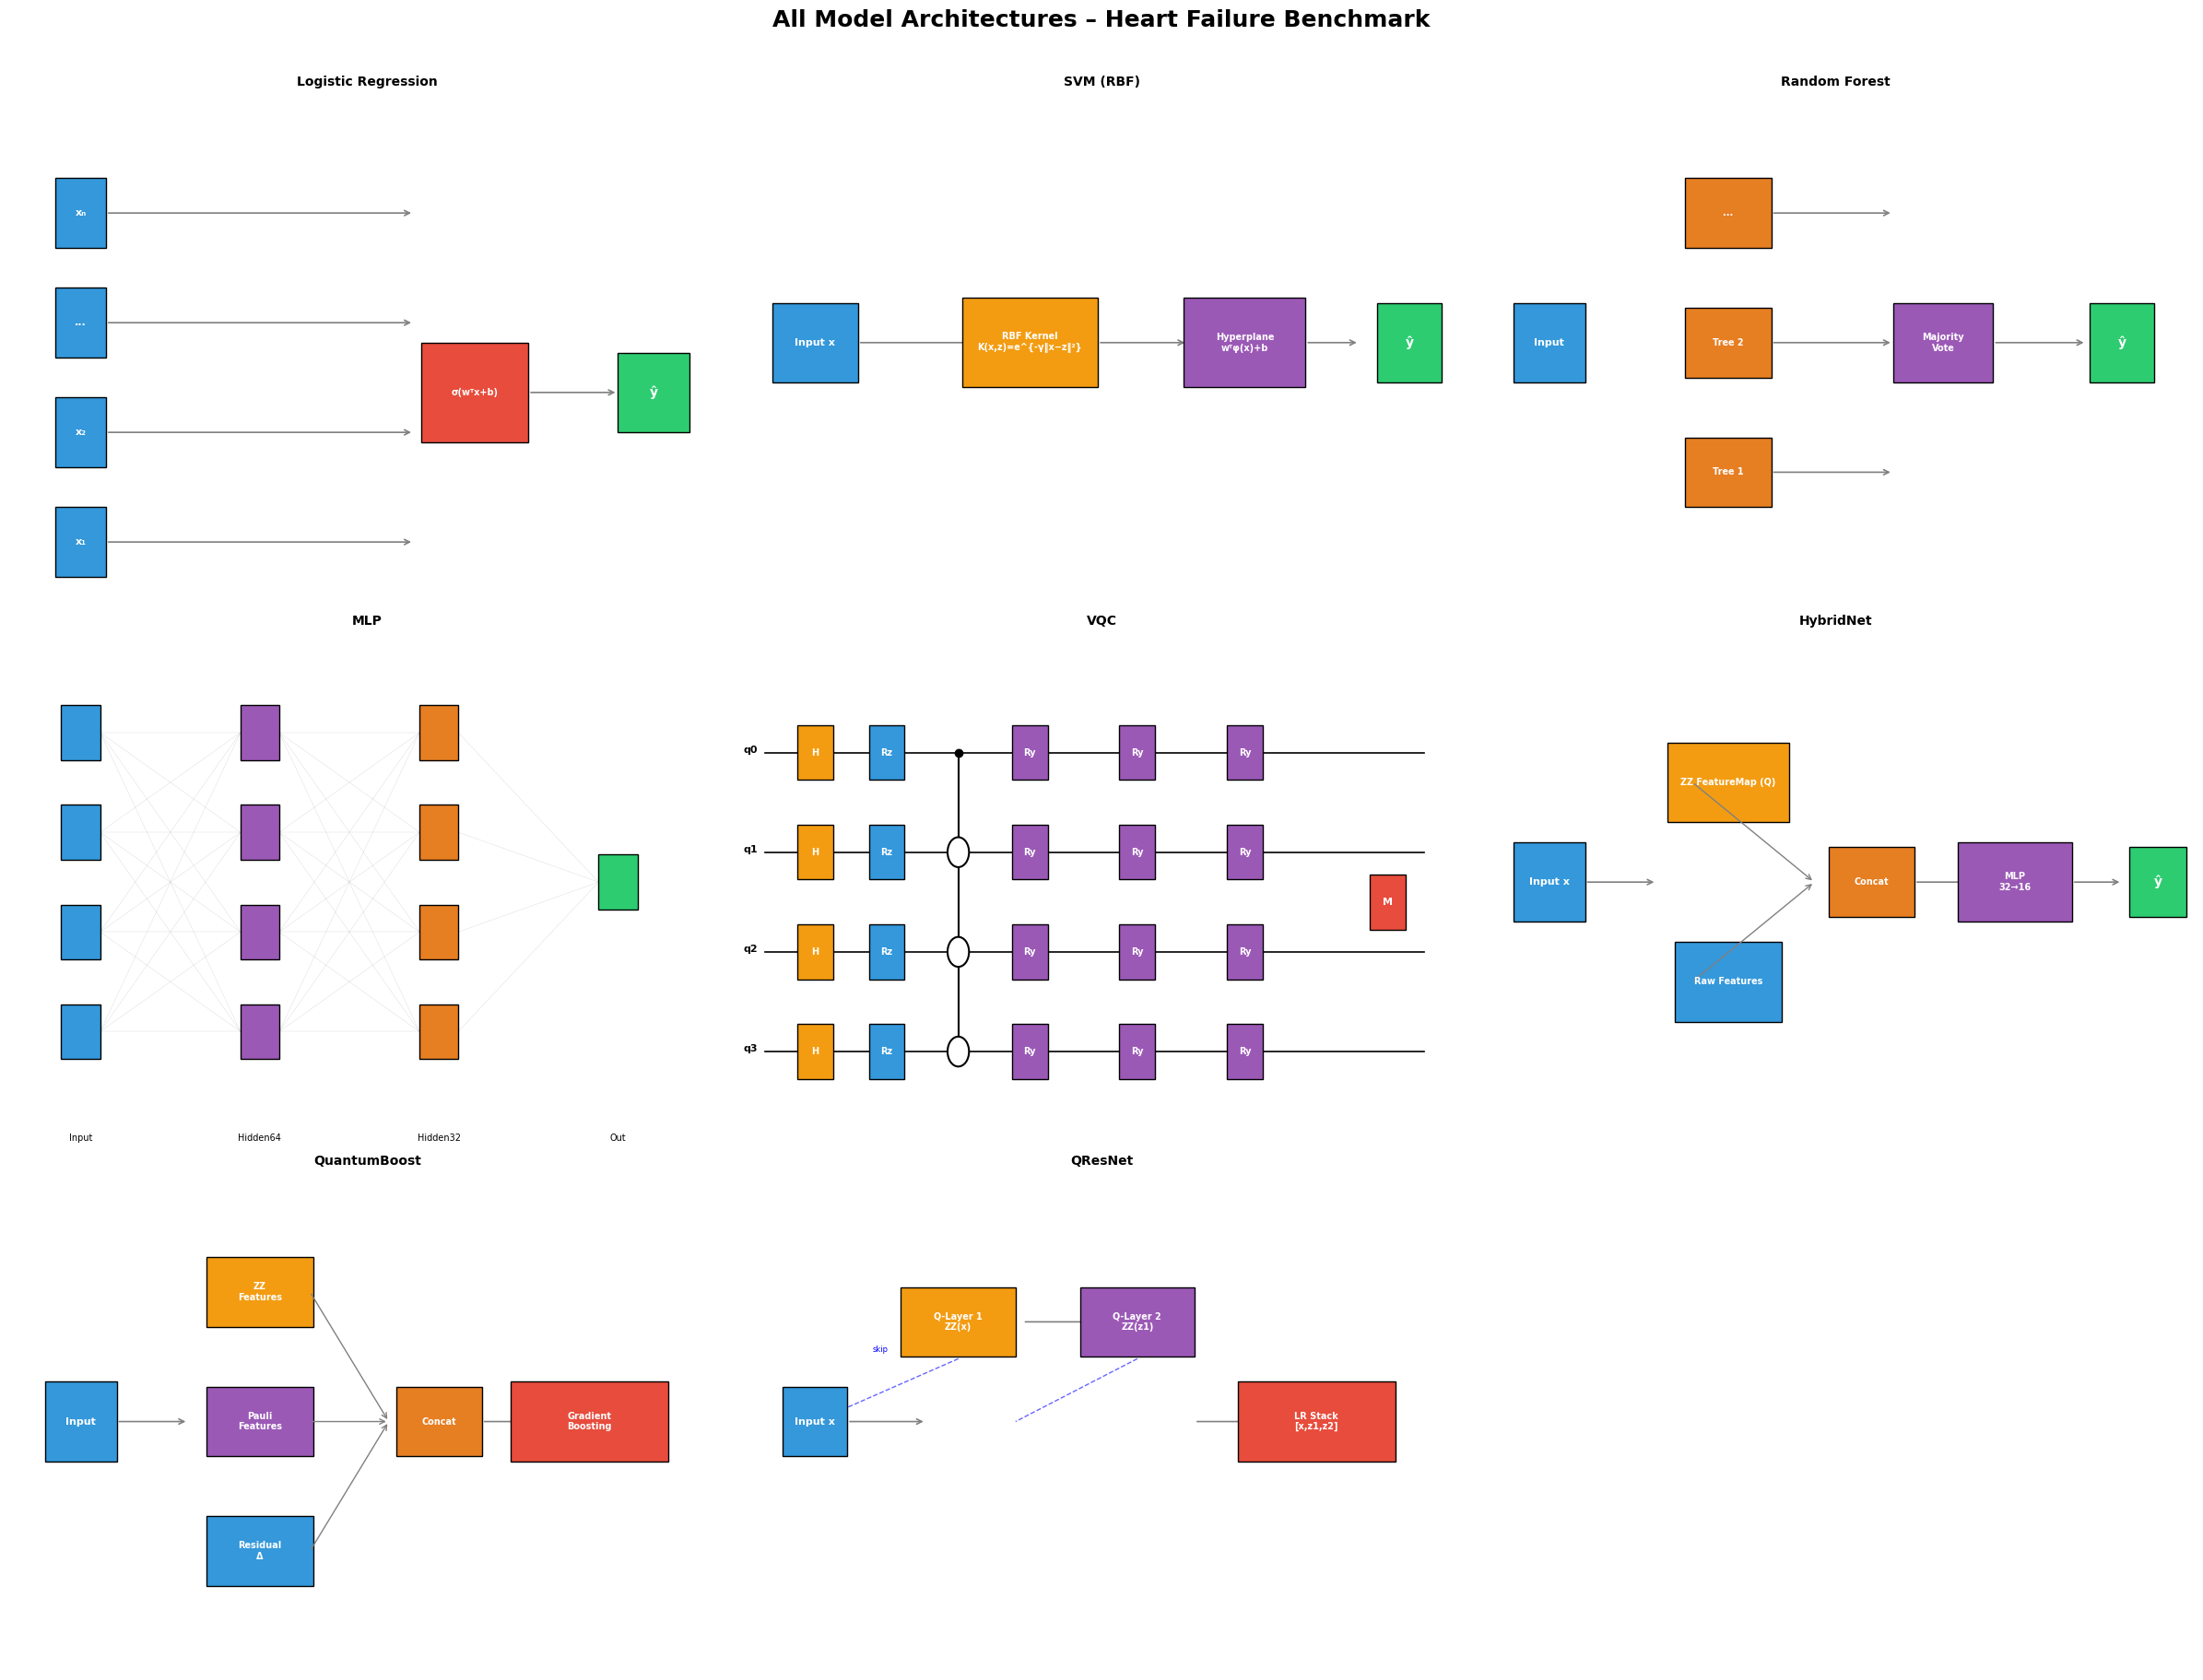

Architecture diagrams saved.


In [10]:
def draw_model_arch(name, ax):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.axis('off')
    ax.set_title(name, fontsize=10, fontweight='bold', pad=6)

    def box(x, y, w, h, col, txt, fs=8):
        w = float(w); h = float(h)
        ax.add_patch(plt.Rectangle((x-w/2, y-h/2), w, h,
                     facecolor=col, edgecolor='k', lw=1, zorder=3))
        ax.text(x, y, txt, ha='center', va='center', fontsize=fs, zorder=4,
                color='white', fontweight='bold')

    def arrow(x1, x2, y):
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

    if name == 'Logistic Regression':
        for i, t in enumerate(['x₁','x₂','...','xₙ']):
            y_ = 0.5 + i * 1.1
            box(1, y_, 0.7, 0.7, '#3498db', t)
            arrow(1.35, 5.65, y_)
        box(6.5, 2, 1.5, 1.0, '#e74c3c', 'σ(wᵀx+b)', 7)
        arrow(7.25, 8.5, 2)
        box(9, 2, 1.0, 0.8, '#2ecc71', 'ŷ', 10)
    elif name == 'SVM (RBF)':
        box(1, 2.5, 1.2, 0.8, '#3498db', 'Input x', 8)
        arrow(1.6, 3.4, 2.5)
        box(4, 2.5, 1.9, 0.9, '#f39c12', 'RBF Kernel\nK(x,z)=e^{-γ‖x−z‖²}', 7)
        arrow(4.95, 6.2, 2.5)
        box(7, 2.5, 1.7, 0.9, '#9b59b6', 'Hyperplane\nwᵀφ(x)+b', 7)
        arrow(7.85, 8.6, 2.5)
        box(9.3, 2.5, 0.9, 0.8, '#2ecc71', 'ŷ', 10)
    elif name == 'Random Forest':
        box(1, 2.5, 1.0, 0.8, '#3498db', 'Input', 8)
        for i, y_ in enumerate([1.2, 2.5, 3.8]):
            box(3.5, y_, 1.2, 0.7, '#e67e22', f'Tree {i+1}' if i<2 else '...', 7)
            arrow(4.1, 5.8, y_)
        box(6.5, 2.5, 1.4, 0.8, '#9b59b6', 'Majority\nVote', 7)
        arrow(7.2, 8.5, 2.5)
        box(9, 2.5, 0.9, 0.8, '#2ecc71', 'ŷ', 10)
    elif name == 'MLP':
        cols = ['#3498db','#9b59b6','#e67e22','#2ecc71']
        xs = [1, 3.5, 6, 8.5]; ns = [4, 4, 4, 1]
        labels = ['Input','Hidden64','Hidden32','Out']
        prev_ys = None; prev_x = None
        for xi, ni, col, lbl in zip(xs, ns, cols, labels):
            ys = [2.5 - (ni-1)*0.5 + j for j in range(ni)]
            for y_ in ys:
                box(xi, y_, 0.55, 0.55, col, '', 9)
            ax.text(xi, -0.1, lbl, ha='center', fontsize=7)
            if prev_ys is not None:
                for py in prev_ys:
                    for cy in ys:
                        ax.plot([prev_x+0.27, xi-0.27], [py, cy], color='gray', lw=0.3, alpha=0.3, zorder=1)
            prev_ys = ys; prev_x = xi
    elif name == 'VQC':
        for q, y_ in enumerate([3.8, 2.8, 1.8, 0.8]):
            ax.plot([0.3, 9.5], [y_, y_], 'k-', lw=1.2)
            ax.text(0.2, y_, f'q{q}', ha='right', fontsize=8, fontweight='bold')
            box(1, y_, 0.5, 0.55, '#f39c12', 'H', 7)
            box(2, y_, 0.5, 0.55, '#3498db', 'Rz', 7)
            for gx in [4, 5.5, 7]:
                box(gx, y_, 0.5, 0.55, '#9b59b6', 'Ry', 7)
        for q in range(3):
            y1 = 3.8 - q; y2 = 2.8 - q
            ax.plot([3, 3], [y1, y2], 'k-', lw=1.5)
            ax.plot([3], [y1], 'ko', ms=6)
            circ = plt.Circle((3, y2), 0.15, color='white', ec='k', lw=1.5, zorder=3)
            ax.add_patch(circ)
        box(9, 2.3, 0.5, 0.55, '#e74c3c', 'M', 8)
    elif name == 'HybridNet':
        box(1, 2.5, 1.0, 0.8, '#3498db', 'Input x', 8)
        arrow(1.5, 2.5, 2.5)
        box(3.5, 3.5, 1.7, 0.8, '#f39c12', 'ZZ FeatureMap (Q)', 7)
        box(3.5, 1.5, 1.5, 0.8, '#3498db', 'Raw Features', 7)
        ax.annotate('', xy=(4.7, 2.5), xytext=(3.0, 3.5), arrowprops=dict(arrowstyle='->', color='gray'))
        ax.annotate('', xy=(4.7, 2.5), xytext=(3.0, 1.5), arrowprops=dict(arrowstyle='->', color='gray'))
        box(5.5, 2.5, 1.2, 0.7, '#e67e22', 'Concat', 7)
        arrow(6.1, 7.0, 2.5)
        box(7.5, 2.5, 1.6, 0.8, '#9b59b6', 'MLP\n32→16', 7)
        arrow(8.3, 9.0, 2.5)
        box(9.5, 2.5, 0.8, 0.7, '#2ecc71', 'ŷ', 10)
    elif name == 'QuantumBoost':
        box(1, 2.5, 1.0, 0.8, '#3498db', 'Input', 8)
        arrow(1.5, 2.5, 2.5)
        box(3.5, 3.8, 1.5, 0.7, '#f39c12', 'ZZ\nFeatures', 7)
        box(3.5, 2.5, 1.5, 0.7, '#9b59b6', 'Pauli\nFeatures', 7)
        box(3.5, 1.2, 1.5, 0.7, '#3498db', 'Residual\nΔ', 7)
        for y_ in [3.8, 2.5, 1.2]:
            ax.annotate('', xy=(5.3, 2.5), xytext=(4.2, y_), arrowprops=dict(arrowstyle='->', color='gray'))
        box(6, 2.5, 1.2, 0.7, '#e67e22', 'Concat', 7)
        arrow(6.6, 7.5, 2.5)
        box(8.1, 2.5, 2.2, 0.8, '#e74c3c', 'Gradient\nBoosting', 7)
    elif name == 'QResNet':
        box(1, 2.5, 0.9, 0.7, '#3498db', 'Input x', 8)
        arrow(1.45, 2.55, 2.5)
        box(3, 3.5, 1.6, 0.7, '#f39c12', 'Q-Layer 1\nZZ(x)', 7)
        ax.plot([3, 1], [3.13, 2.5], 'b--', lw=1, alpha=0.6)
        ax.text(1.8, 3.2, 'skip', fontsize=6, color='blue')
        arrow(3.9, 5.0, 3.5)
        box(5.5, 3.5, 1.6, 0.7, '#9b59b6', 'Q-Layer 2\nZZ(z1)', 7)
        ax.plot([5.5, 3.8], [3.13, 2.5], 'b--', lw=1, alpha=0.6)
        arrow(6.3, 7.5, 2.5)
        box(8, 2.5, 2.2, 0.8, '#e74c3c', 'LR Stack\n[x,z1,z2]', 7)
    else:
        ax.text(5, 2.5, name, ha='center', va='center', fontsize=11, fontweight='bold')


model_names = ['Logistic Regression','SVM (RBF)','Random Forest','MLP',
               'VQC','HybridNet','QuantumBoost','QResNet']
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
fig.suptitle('All Model Architectures – Heart Failure Benchmark', fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()
for ax, name in zip(axes, model_names):
    draw_model_arch(name, ax)
for ax in axes[len(model_names):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(RES_DIR + 'all_architectures.png', dpi=120, bbox_inches='tight')
plt.show()
print("Architecture diagrams saved.")

## 8) Noise Configuration

In [11]:
@dataclass
class NoiseConfig:
    name: str
    noise_type: str
    noise_param: float = 0.0

NOISE_CONFIGS = [
    NoiseConfig('Ideal',                    'none',              0.00),
    NoiseConfig('Depolarizing p=0.01',      'depolarizing',      0.01),
    NoiseConfig('Depolarizing p=0.03',      'depolarizing',      0.03),
    NoiseConfig('Depolarizing p=0.05',      'depolarizing',      0.05),
    NoiseConfig('Bitflip p=0.01',           'bitflip',           0.01),
    NoiseConfig('Bitflip p=0.05',           'bitflip',           0.05),
    NoiseConfig('Amplitude Damp p=0.02',    'amplitude_damping', 0.02),
    NoiseConfig('Amplitude Damp p=0.05',    'amplitude_damping', 0.05),
    NoiseConfig('Gaussian σ=0.01',          'gaussian',          0.01),
    NoiseConfig('Gaussian σ=0.05',          'gaussian',          0.05),
]

def inject_noise(X, cfg: NoiseConfig, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    Xn = X.copy(); p = cfg.noise_param
    if cfg.noise_type == 'none':           return Xn
    elif cfg.noise_type == 'gaussian':     Xn += rng.normal(0, p, Xn.shape)
    elif cfg.noise_type == 'depolarizing':
        mask = rng.random(Xn.shape) < p
        Xn[mask] = rng.normal(0, 1, mask.sum())
    elif cfg.noise_type == 'bitflip':
        Xn[rng.random(Xn.shape) < p] *= -1
    elif cfg.noise_type == 'amplitude_damping':
        Xn[rng.random(Xn.shape) < p] *= (1 - p)
    return Xn

print("Noise models:", [c.name for c in NOISE_CONFIGS])

Noise models: ['Ideal', 'Depolarizing p=0.01', 'Depolarizing p=0.03', 'Depolarizing p=0.05', 'Bitflip p=0.01', 'Bitflip p=0.05', 'Amplitude Damp p=0.02', 'Amplitude Damp p=0.05', 'Gaussian σ=0.01', 'Gaussian σ=0.05']


## 9) Evaluation & Model Registry

In [12]:
def evaluate_model(model, Xtr, ytr, Xte, yte, cv_folds=5):
    """Full evaluation: accuracy, AUC, F1, MCC, sensitivity, specificity, train time, CV scores."""
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0

    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    f1 = f1_score(yte, pred, zero_division=0)
    cm = confusion_matrix(yte, pred)

    # Extra metrics for clinical use
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    sensitivity = tp / (tp + fn + 1e-10)  # recall for class 1
    specificity = tn / (tn + fp + 1e-10)
    mcc_denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + 1e-10
    mcc = (tp*tn - fp*fn) / mcc_denom

    try:
        proba = model.predict_proba(Xte)[:,1]
        auc = roc_auc_score(yte, proba)
    except:
        auc = float('nan')

    # 5-fold CV on combined data
    try:
        m2 = copy.deepcopy(model)
        Xall = np.vstack([Xtr, Xte])
        yall = np.concatenate([ytr, yte])
        cv_sc = cross_val_score(m2, Xall, yall,
                                cv=StratifiedKFold(cv_folds, shuffle=True, random_state=GLOBAL_SEED),
                                scoring='accuracy')
    except:
        cv_sc = np.array([float('nan')]*cv_folds)

    return dict(acc=acc, auc=auc, f1=f1, mcc=mcc,
                sensitivity=sensitivity, specificity=specificity,
                train_time=train_time,
                cv_mean=cv_sc.mean(), cv_std=cv_sc.std(),
                cm=cm, loss_curve=getattr(model,'loss_curve_',[]))


def get_all_models(n_qubits=4, seed=GLOBAL_SEED, maxiter=80):
    """Return dict of all models: classical + quantum + hybrid."""
    return {
        # Classical
        'LR':           LogisticRegression(max_iter=2000, C=1.0, random_state=seed),
        'SVM_RBF':      SVC(C=1.0, gamma='scale', probability=True, random_state=seed),
        'RF':           RandomForestClassifier(n_estimators=200, random_state=seed),
        'MLP':          MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300,
                                       early_stopping=True, random_state=seed),
        # Quantum
        'VQC':          NumpyVQC(n_qubits=n_qubits, reps=2, shots=512, seed=seed, maxiter=maxiter),
        'QCNN':         NumpyQCNN(n_qubits=n_qubits, reps=2, shots=512, seed=seed, maxiter=maxiter),
        'QKernel_SVM':  NumpyQKernelSVM(n_qubits=n_qubits, seed=seed),
        'QAOA_VQC':     NumpyQAOA(n_qubits=n_qubits, shots=512, seed=seed, maxiter=maxiter),
        # Hybrid
        'HybridNet':    HybridNet(n_qubits=n_qubits, seed=seed),
        'QuantumBoost': QuantumBoost(n_qubits=n_qubits, seed=seed),
        'QResNet':      QResNet(n_qubits=n_qubits, seed=seed),
    }

print("Evaluation utilities and model registry ready.")

Evaluation utilities and model registry ready.


## 10) Input Size Experiment

In [13]:
def run_input_size_experiment(seeds=range(3), maxiter=60):
    """
    Test all models across:
      - 4 PCA features
      - 6 PCA features
      - N relevant features (adaptively selected)
      - Full features (classical only)
    """
    X_np = X_df.values; y_np = y_s.values

    rel_names, rel_idx = select_relevant_features(X_df, y_s)
    n_rel = len(rel_idx)
    X_rel = X_np[:, rel_idx]
    n_full = X_np.shape[1]

    configs = [
        ('4-PCA',            4,      X_np,  True),
        ('6-PCA',            6,      X_np,  True),
        (f'{n_rel}-Relevant', n_rel,  X_rel, False),
        (f'{n_full}-Full',   n_full,  X_np,  False),
    ]

    rows = []
    quantum_models = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

    for cfg_name, n_feat, X_use, use_pca in configs:
        print(f"\n── Config: {cfg_name} (n_features={n_feat}) ──")
        for seed in seeds:
            set_seed(seed)
            Xtr, Xte, ytr, yte = preprocess_dataset(
                X_use, y_np, n_features=n_feat, seed=seed,
                resample='smote', use_pca=use_pca)

            models = get_all_models(n_qubits=min(n_feat, 8), seed=seed, maxiter=maxiter)

            # Skip quantum for full feature set
            if not use_pca and n_feat > 8:
                models = {k:v for k,v in models.items() if k not in quantum_models}

            for mname, model in models.items():
                try:
                    res = evaluate_model(model, Xtr, ytr, Xte, yte, cv_folds=5)
                    rows.append(dict(config=cfg_name, n_features=n_feat,
                                     model=mname, seed=seed,
                                     **{k:v for k,v in res.items() if k not in ('cm','loss_curve')}))
                    print(f"  {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f} mcc={res['mcc']:.3f}")
                except Exception as e:
                    print(f"  [SKIP] {mname}: {e}")

    return pd.DataFrame(rows)


print("Starting input-size experiment...")
df_input = run_input_size_experiment(seeds=range(3), maxiter=60)
print(f"\nDone. {len(df_input)} result rows.")

Starting input-size experiment...
Feature selection: 5/12 features selected
  Variance covered by selected features: 1.000
  Selected: ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']

── Config: 4-PCA (n_features=4) ──
  LR              acc=0.817 auc=0.842 mcc=0.571
  SVM_RBF         acc=0.783 auc=0.797 mcc=0.507
  RF              acc=0.767 auc=0.781 mcc=0.461
  MLP             acc=0.650 auc=0.807 mcc=0.378
  VQC             acc=0.733 auc=0.755 mcc=0.402
  QCNN            acc=0.683 auc=0.703 mcc=0.000
  QKernel_SVM     acc=0.800 auc=0.863 mcc=0.552
  QAOA_VQC        acc=0.767 auc=0.847 mcc=0.477
  HybridNet       acc=0.800 auc=0.802 mcc=0.569
  QuantumBoost    acc=0.783 auc=0.785 mcc=0.507
  QResNet         acc=0.817 auc=0.837 mcc=0.571
  LR              acc=0.867 auc=0.893 mcc=0.702
  SVM_RBF         acc=0.850 auc=0.891 mcc=0.659
  RF              acc=0.800 auc=0.873 mcc=0.526
  MLP             acc=0.867 auc=0.869 mcc=0.685
  VQC             acc=0.667 auc=0.69

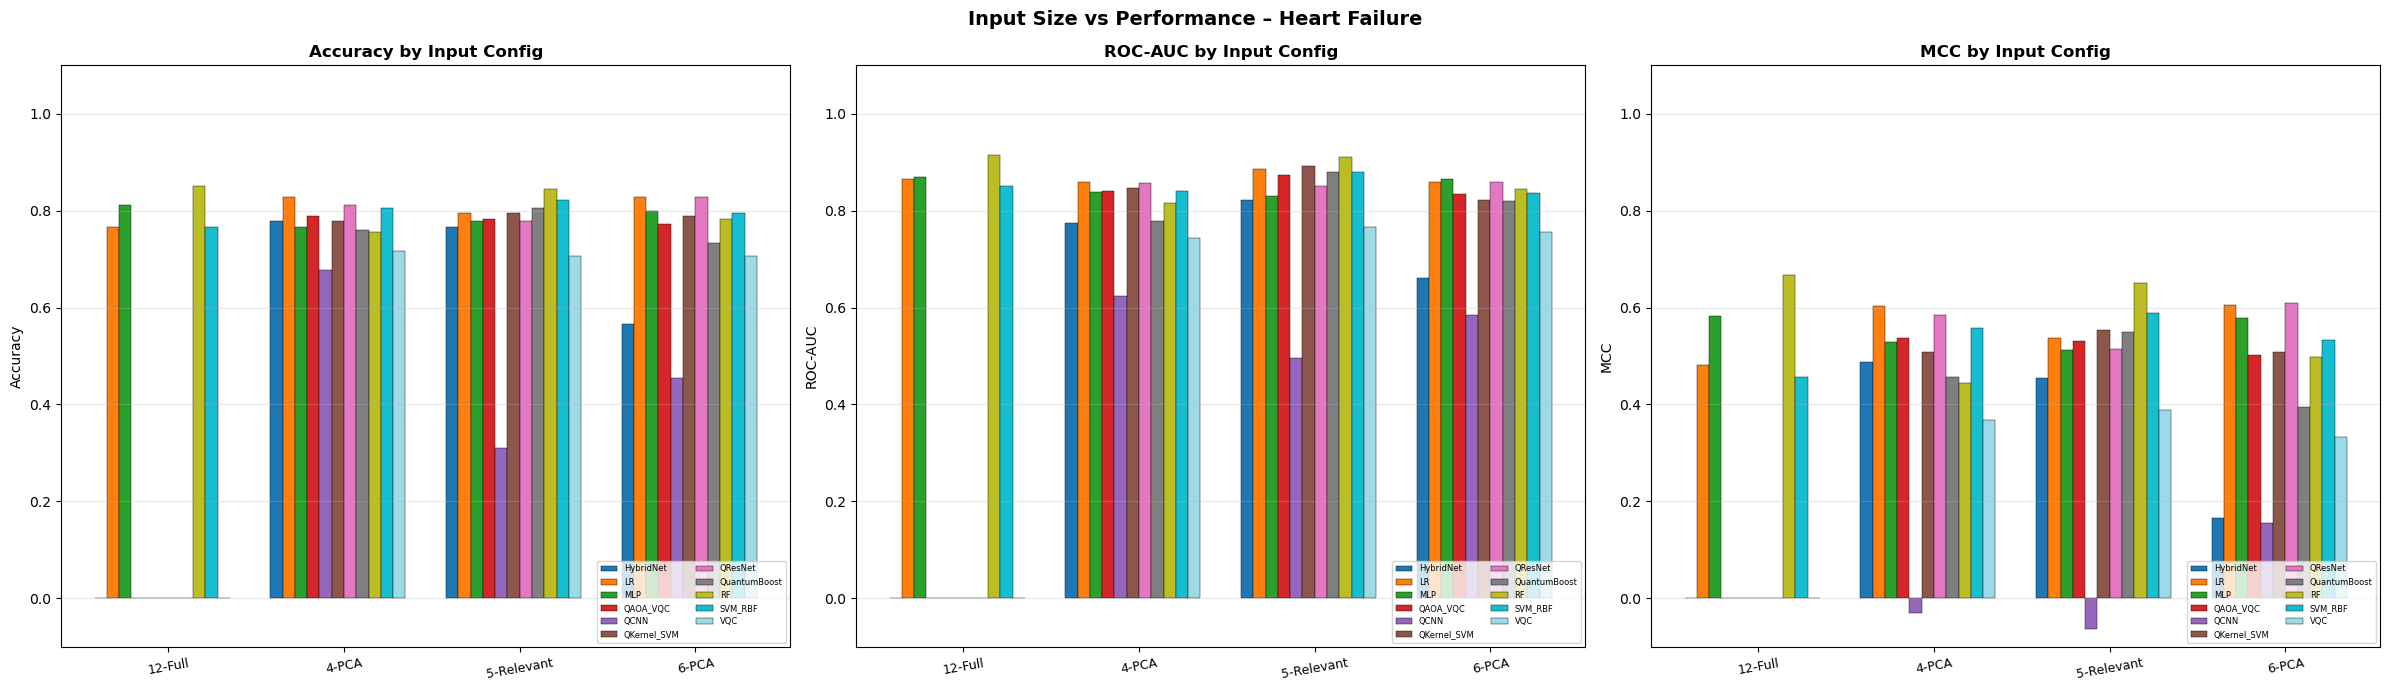

Input size comparison saved.


In [14]:
# ── Input size plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Input Size vs Performance – Heart Failure', fontsize=14, fontweight='bold')

for ax, metric, ylabel in zip(axes, ['acc','auc','mcc'], ['Accuracy','ROC-AUC','MCC']):
    pivot = df_input.groupby(['config','model'])[metric].mean().unstack('model')
    x = np.arange(len(pivot))
    w = 0.07
    models = pivot.columns.tolist()
    colors = plt.cm.tab20(np.linspace(0,1,len(models)))
    for i,(m,col) in enumerate(zip(models, colors)):
        if m in pivot.columns:
            ax.bar(x + i*w, pivot[m].fillna(0), w, label=m, color=col, edgecolor='k', lw=0.3)
    ax.set_xticks(x + w*len(models)/2)
    ax.set_xticklabels(pivot.index, fontsize=9, rotation=10)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Input Config', fontweight='bold')
    ax.legend(fontsize=6, ncol=2, loc='lower right')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'input_size_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Input size comparison saved.")

## 11) Main Benchmark (All Models × All Noise × 5 Seeds)

In [15]:
def run_main_benchmark(n_qubits=4, seeds=range(5), maxiter=80):
    """
    Full grid:
      - All 11 models
      - All 10 noise configs (quantum only for noise)
      - 5 seeds
      - 5-fold CV
    """
    X_np = X_df.values; y_np = y_s.values
    rows = []
    quantum_names = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

    for seed in seeds:
        set_seed(seed)
        # Classical: full features
        Xtr_f, Xte_f, ytr, yte = preprocess_dataset(
            X_np, y_np, n_features=X_np.shape[1], seed=seed, resample='smote', use_pca=False)
        # Quantum/hybrid: PCA to n_qubits
        Xtr_q, Xte_q, _, _ = preprocess_dataset(
            X_np, y_np, n_features=n_qubits, seed=seed, resample='smote', use_pca=True)

        models = get_all_models(n_qubits=n_qubits, seed=seed, maxiter=maxiter)

        for mname, model in models.items():
            Xtr = Xtr_q if mname in quantum_names else Xtr_f
            Xte = Xte_q if mname in quantum_names else Xte_f

            # No noise run
            try:
                res = evaluate_model(model, Xtr, ytr, Xte, yte)
                rows.append(dict(model=mname, seed=seed, noise='none', noise_param=0.0,
                                  **{k:v for k,v in res.items() if k not in ('cm','loss_curve')},
                                  loss_curve=res['loss_curve']))
                print(f"  seed={seed} {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f}")
            except Exception as e:
                print(f"[SKIP] {mname} seed={seed}: {e}")

            # Noise runs (quantum + hybrid only)
            if mname in quantum_names:
                for nc in NOISE_CONFIGS[1:]:
                    try:
                        m2 = copy.deepcopy(model)
                        Xtr_n = inject_noise(Xtr, nc, seed=seed)
                        Xte_n = inject_noise(Xte, nc, seed=seed+100)
                        res_n = evaluate_model(m2, Xtr_n, ytr, Xte_n, yte, cv_folds=3)
                        rows.append(dict(model=mname, seed=seed,
                                          noise=nc.noise_type, noise_param=nc.noise_param,
                                          **{k:v for k,v in res_n.items() if k not in ('cm','loss_curve')},
                                          loss_curve=res_n['loss_curve']))
                    except Exception as e:
                        print(f"  [SKIP noise] {mname} {nc.name}: {e}")

        print(f"Seed {seed} done.")

    return pd.DataFrame(rows)


print("Starting main benchmark (takes a few minutes)...")
df_main = run_main_benchmark(n_qubits=4, seeds=range(5), maxiter=80)
print(f"\nTotal rows: {len(df_main)}")
print("\nNo-noise summary:")
print(df_main[df_main['noise']=='none'].groupby('model')[['acc','auc','f1','mcc','cv_mean']].mean().round(3))

Starting main benchmark (takes a few minutes)...
  seed=0 LR              acc=0.850 auc=0.910
  seed=0 SVM_RBF         acc=0.783 auc=0.875
  seed=0 RF              acc=0.833 auc=0.922
  seed=0 MLP             acc=0.867 auc=0.892
  seed=0 VQC             acc=0.717 auc=0.757
  seed=0 QCNN            acc=0.683 auc=0.709
  seed=0 QKernel_SVM     acc=0.800 auc=0.863
  seed=0 QAOA_VQC        acc=0.783 auc=0.843
  seed=0 HybridNet       acc=0.800 auc=0.802
  seed=0 QuantumBoost    acc=0.783 auc=0.785
  seed=0 QResNet         acc=0.817 auc=0.837
Seed 0 done.
  seed=1 LR              acc=0.733 auc=0.840
  seed=1 SVM_RBF         acc=0.767 auc=0.828
  seed=1 RF              acc=0.833 auc=0.908
  seed=1 MLP             acc=0.783 auc=0.849
  seed=1 VQC             acc=0.667 auc=0.701
  seed=1 QCNN            acc=0.667 auc=0.712
  seed=1 QKernel_SVM     acc=0.800 auc=0.866
  seed=1 QAOA_VQC        acc=0.833 auc=0.872
  seed=1 HybridNet       acc=0.767 auc=0.714
  seed=1 QuantumBoost    acc=0.700 auc

## 12) Multiple Accuracy Metrics & Comprehensive Visualizations

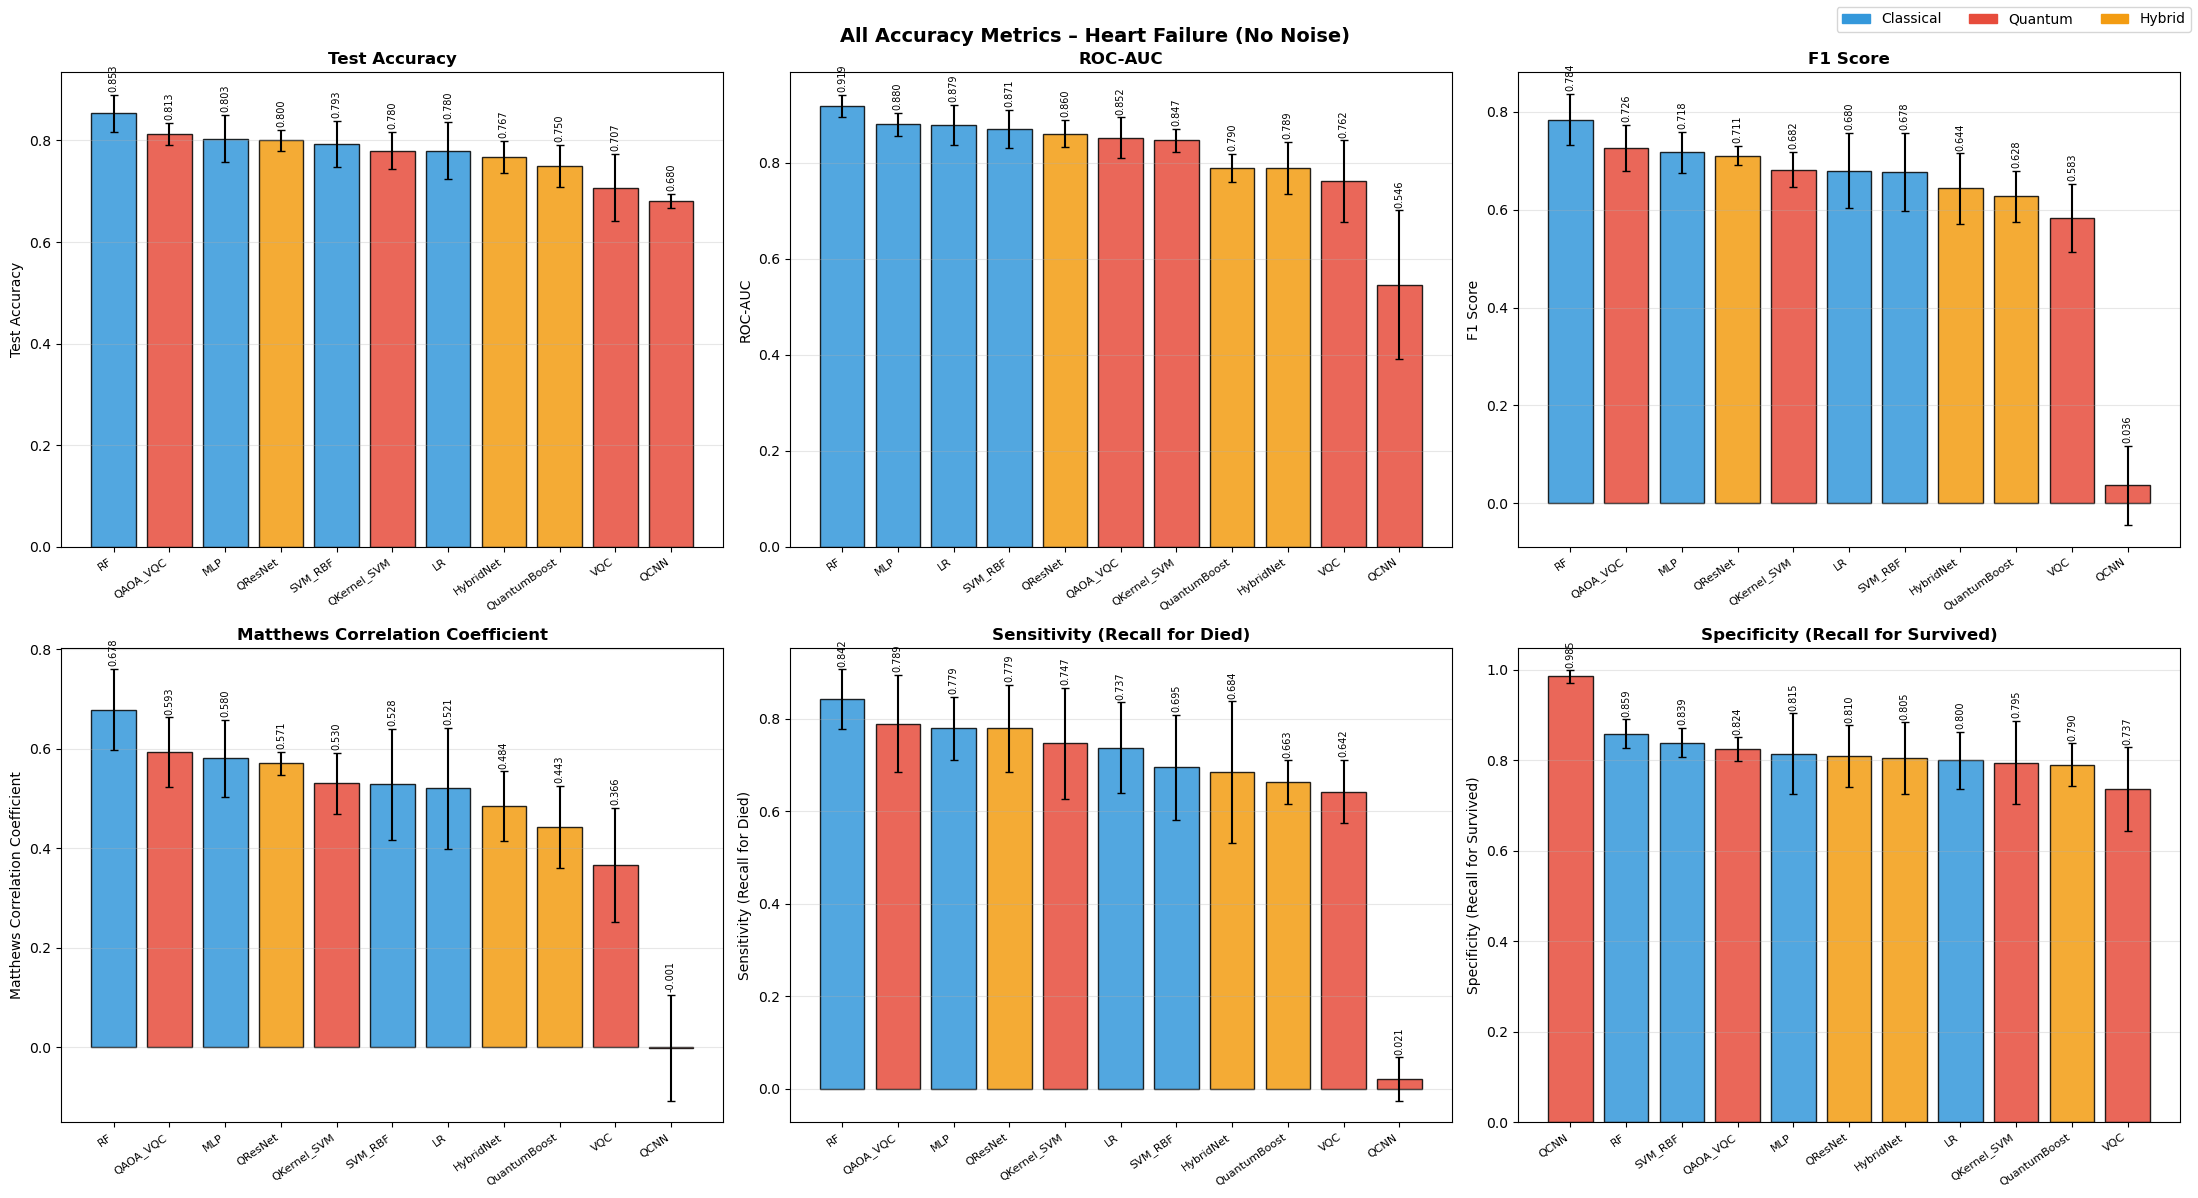

All accuracy metrics plot saved.


In [16]:
df_ideal = df_main[df_main['noise']=='none'].copy()
order = df_ideal.groupby('model')['acc'].mean().sort_values(ascending=False).index

# ── Plot 1: All accuracy metrics overview ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('All Accuracy Metrics – Heart Failure (No Noise)', fontsize=14, fontweight='bold')
axes = axes.flatten()

metrics_list = [
    ('acc',         'Test Accuracy'),
    ('auc',         'ROC-AUC'),
    ('f1',          'F1 Score'),
    ('mcc',         'Matthews Correlation Coefficient'),
    ('sensitivity', 'Sensitivity (Recall for Died)'),
    ('specificity', 'Specificity (Recall for Survived)'),
]

cat_col = {'LR':'#3498db','SVM_RBF':'#3498db','RF':'#3498db','MLP':'#3498db',
           'VQC':'#e74c3c','QCNN':'#e74c3c','QKernel_SVM':'#e74c3c','QAOA_VQC':'#e74c3c',
           'HybridNet':'#f39c12','QuantumBoost':'#f39c12','QResNet':'#f39c12'}

for ax, (metric, label) in zip(axes, metrics_list):
    ord_m = df_ideal.groupby('model')[metric].mean().sort_values(ascending=False).index
    means = df_ideal.groupby('model')[metric].mean().loc[ord_m]
    stds  = df_ideal.groupby('model')[metric].std().loc[ord_m]
    cols  = [cat_col.get(m, 'gray') for m in ord_m]
    bars  = ax.bar(range(len(ord_m)), means.values, yerr=stds.values,
                   color=cols, edgecolor='k', alpha=0.85, capsize=3)
    ax.set_xticks(range(len(ord_m)))
    ax.set_xticklabels(ord_m, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(label, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, v, s in zip(bars, means.values, stds.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
                f'{v:.3f}', ha='center', fontsize=7, rotation=90)

legend_h = [mpatches.Patch(color='#3498db', label='Classical'),
            mpatches.Patch(color='#e74c3c', label='Quantum'),
            mpatches.Patch(color='#f39c12', label='Hybrid')]
fig.legend(handles=legend_h, fontsize=10, loc='upper right', ncol=3)

plt.tight_layout()
plt.savefig(RES_DIR + 'all_accuracy_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print("All accuracy metrics plot saved.")

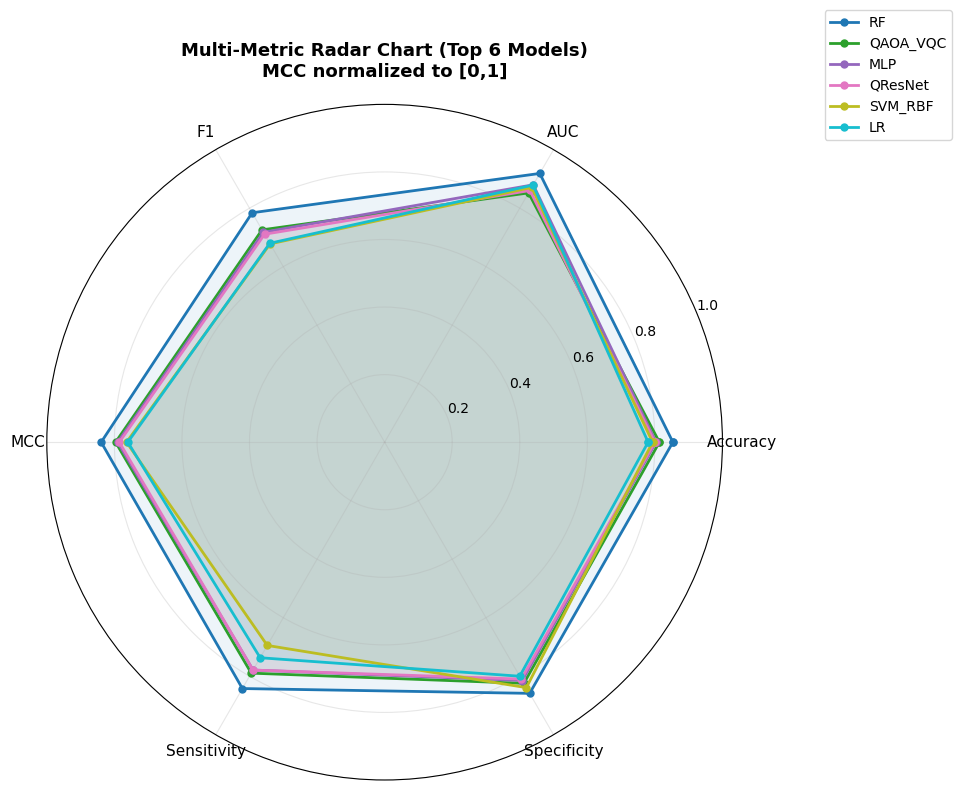

Radar chart saved.


In [17]:
# ── Plot 2: Multi-metric radar chart ─────────────────────
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['acc', 'auc', 'f1', 'mcc', 'sensitivity', 'specificity']
radar_labels  = ['Accuracy', 'AUC', 'F1', 'MCC', 'Sensitivity', 'Specificity']

# Normalize MCC to [0,1] for visualization
df_radar = df_ideal.groupby('model')[radar_metrics].mean()
df_radar['mcc'] = (df_radar['mcc'] + 1) / 2  # normalize to [0,1]

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # close circle

top_models = df_radar['acc'].nlargest(6).index.tolist()
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors_radar = plt.cm.tab10(np.linspace(0, 1, len(top_models)))

for model, col in zip(top_models, colors_radar):
    vals = df_radar.loc[model, radar_metrics].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=col, lw=2, label=model, ms=5)
    ax.fill(angles, vals, alpha=0.08, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Radar Chart (Top 6 Models)\nMCC normalized to [0,1]',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print("Radar chart saved.")

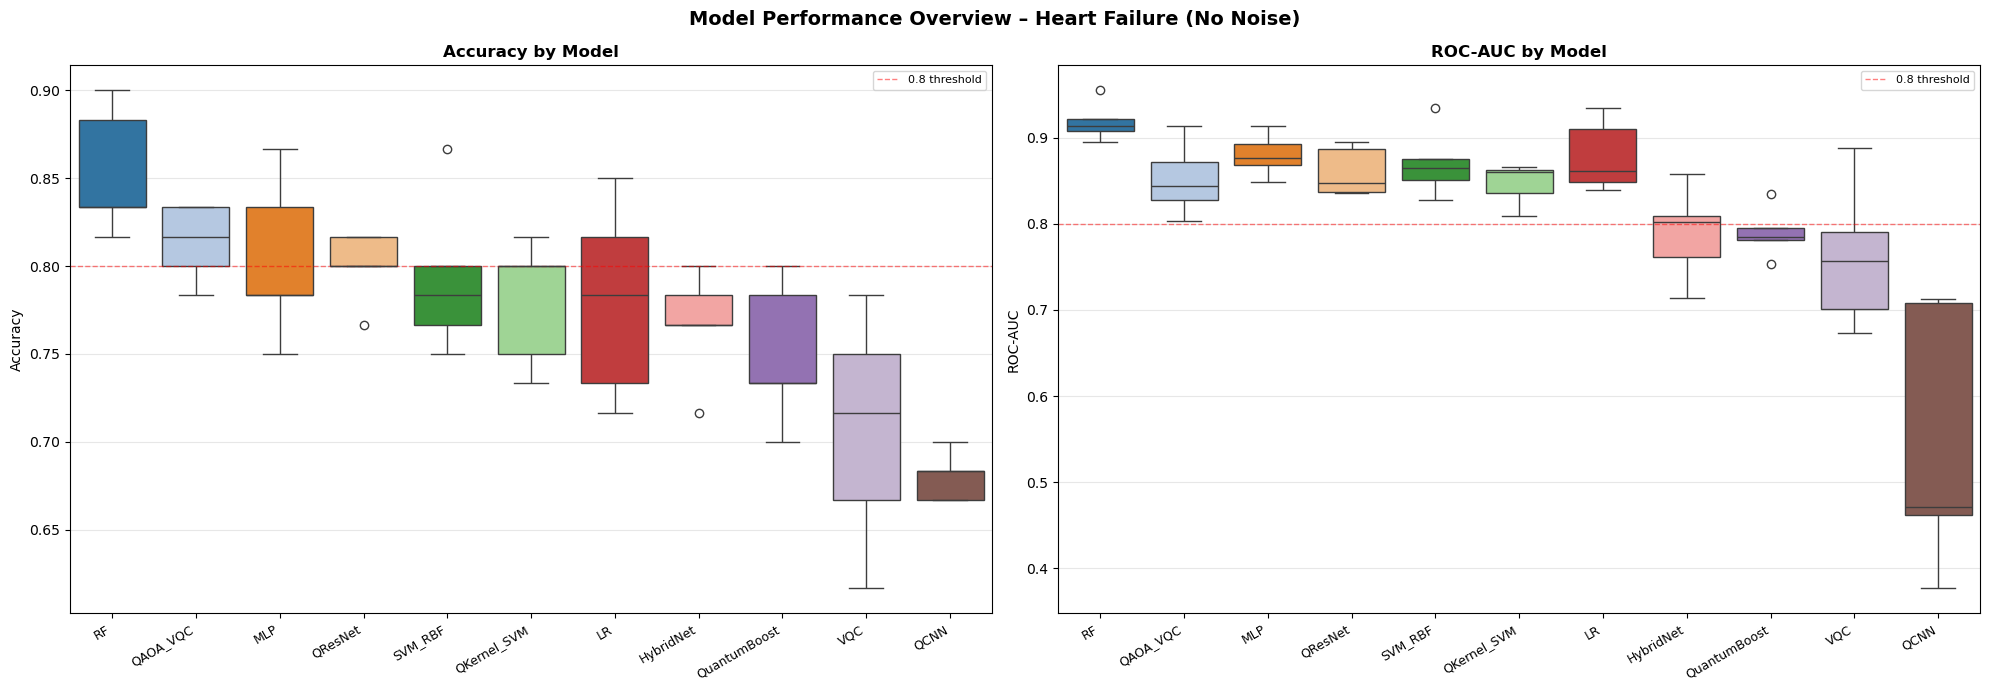

In [18]:
# ── Plot 3: Accuracy & AUC overview boxplot ────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Model Performance Overview – Heart Failure (No Noise)', fontsize=14, fontweight='bold')

for ax, metric, label in zip(axes, ['acc','auc'], ['Accuracy','ROC-AUC']):
    sns.boxplot(data=df_ideal, x='model', y=metric, order=order,
                palette='tab20', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{label} by Model', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(label)
    ax.axhline(0.8, color='red', ls='--', lw=1, alpha=0.5, label='0.8 threshold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'benchmark_overview.png', dpi=120, bbox_inches='tight')
plt.show()

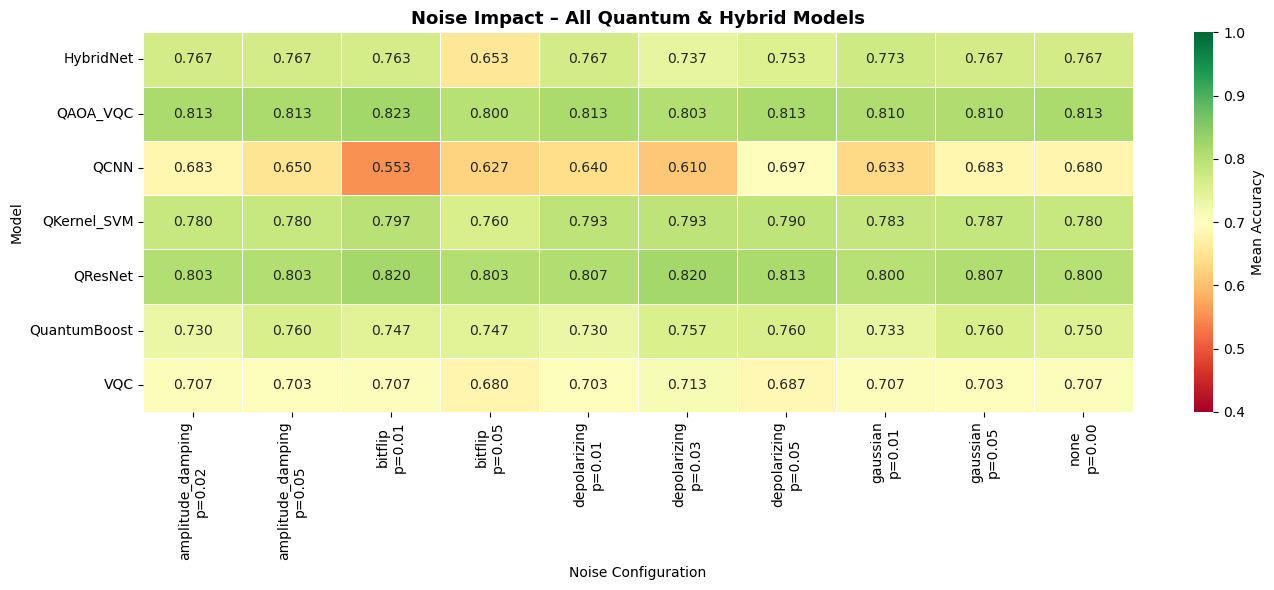

In [19]:
# ── Plot 4: Noise impact heatmap ──────────────────────────
quantum_models = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']
df_noise = df_main[df_main['model'].isin(quantum_models)].copy()
df_noise['noise_label'] = df_noise.apply(
    lambda r: f"{r['noise']}\np={r['noise_param']:.2f}", axis=1)

pivot_noise = df_noise.pivot_table(index='model', columns='noise_label',
                                    values='acc', aggfunc='mean')

fig, ax = plt.subplots(figsize=(max(14, len(pivot_noise.columns)*1.4), 6))
sns.heatmap(pivot_noise, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Mean Accuracy'})
ax.set_title('Noise Impact – All Quantum & Hybrid Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Noise Configuration'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(RES_DIR + 'noise_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

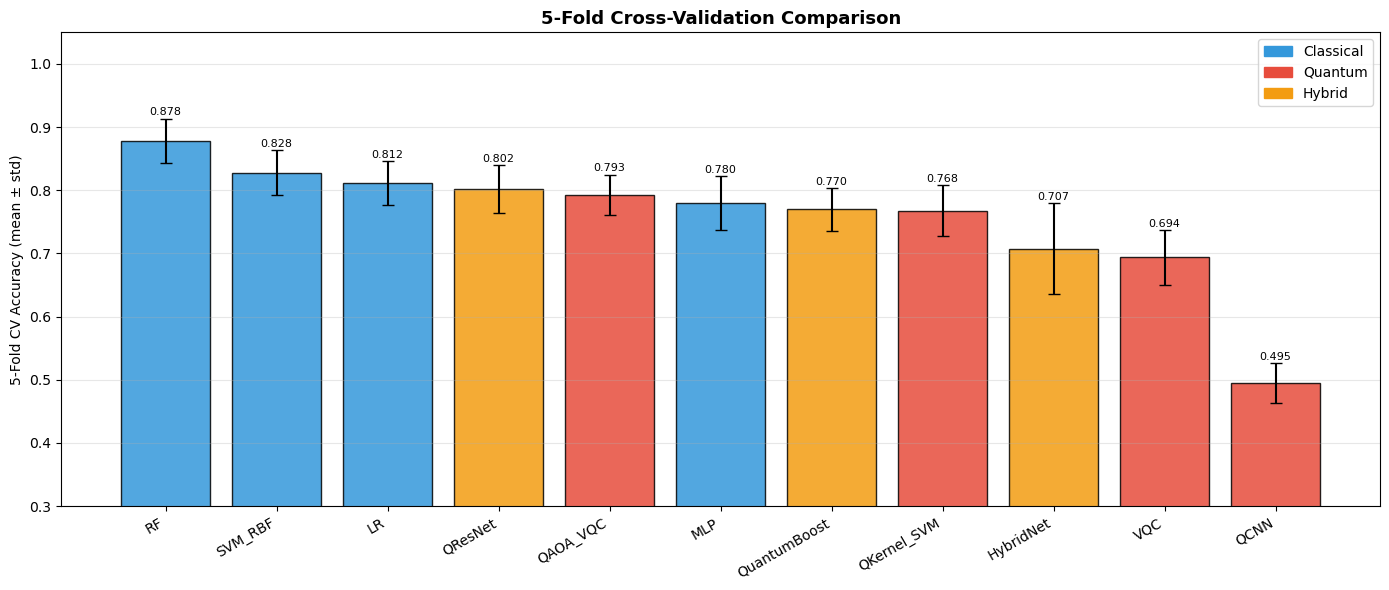

In [20]:
# ── Plot 5: 5-fold CV comparison ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
order_cv = df_ideal.groupby('model')['cv_mean'].mean().sort_values(ascending=False).index
means = df_ideal.groupby('model')['cv_mean'].mean().loc[order_cv]
stds  = df_ideal.groupby('model')['cv_std'].mean().loc[order_cv]

colors = []
for m in order_cv:
    if m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC']: colors.append('#e74c3c')
    elif m in ['HybridNet','QuantumBoost','QResNet']:  colors.append('#f39c12')
    else:                                               colors.append('#3498db')

bars = ax.bar(range(len(order_cv)), means, yerr=stds, capsize=4,
              color=colors, edgecolor='k', alpha=0.85, error_kw={'lw':1.5})
ax.set_xticks(range(len(order_cv)))
ax.set_xticklabels(order_cv, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('5-Fold CV Accuracy (mean ± std)')
ax.set_title('5-Fold Cross-Validation Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0.3, 1.05)
ax.grid(axis='y', alpha=0.3)
legend_patches = [mpatches.Patch(color='#3498db', label='Classical'),
                  mpatches.Patch(color='#e74c3c', label='Quantum'),
                  mpatches.Patch(color='#f39c12', label='Hybrid')]
ax.legend(handles=legend_patches, fontsize=10)
for bar, v, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.005,
            f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(RES_DIR + 'cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

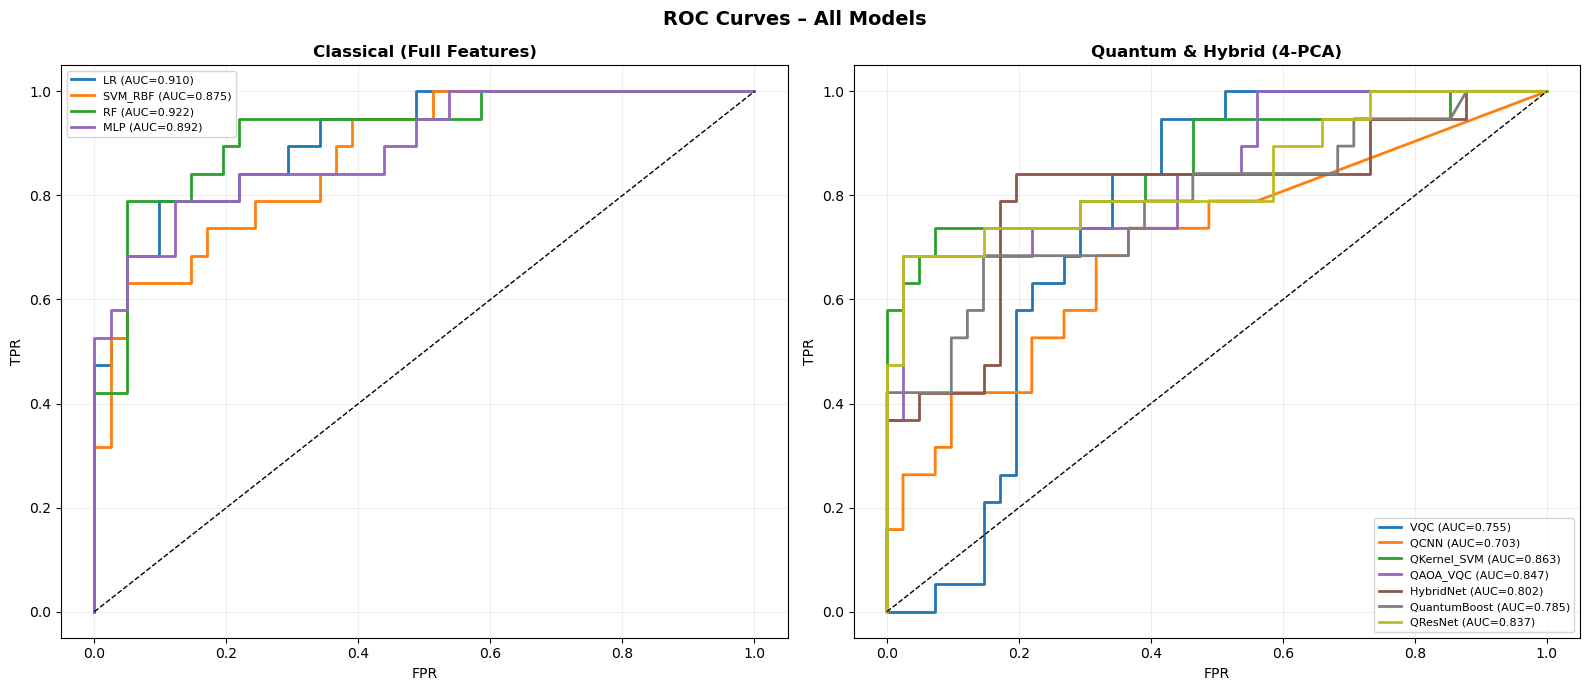

In [21]:
# ── Plot 6: ROC curves ────────────────────────────────────
X_np = X_df.values; y_np = y_s.values
Xtr_r, Xte_r, ytr_r, yte_r = preprocess_dataset(X_np, y_np, n_features=4, seed=0, use_pca=True)
Xtr_f2, Xte_f2, ytr_f2, yte_f2 = preprocess_dataset(X_np, y_np, n_features=X_np.shape[1], seed=0, use_pca=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ROC Curves – All Models', fontsize=14, fontweight='bold')

model_sets = [
    ('Classical (Full Features)', ['LR','SVM_RBF','RF','MLP'], Xtr_f2, Xte_f2, ytr_f2, yte_f2),
    ('Quantum & Hybrid (4-PCA)',  ['VQC','QCNN','QKernel_SVM','QAOA_VQC',
                                    'HybridNet','QuantumBoost','QResNet'],
     Xtr_r, Xte_r, ytr_r, yte_r),
]

colors_roc = plt.cm.tab10(np.linspace(0,1,8))

for ax, (title, mnames, Xtr_, Xte_, ytr_, yte_) in zip(axes, model_sets):
    all_m = get_all_models(n_qubits=4, seed=0, maxiter=60)
    for mname, col in zip(mnames, colors_roc):
        if mname not in all_m: continue
        m = copy.deepcopy(all_m[mname])
        try:
            m.fit(Xtr_, ytr_)
            proba = m.predict_proba(Xte_)[:,1]
            fpr, tpr, _ = roc_curve(yte_, proba)
            auc = roc_auc_score(yte_, proba)
            ax.plot(fpr, tpr, lw=2, color=col, label=f'{mname} (AUC={auc:.3f})')
        except Exception as e:
            print(f"[ROC skip] {mname}: {e}")
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RES_DIR + 'roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

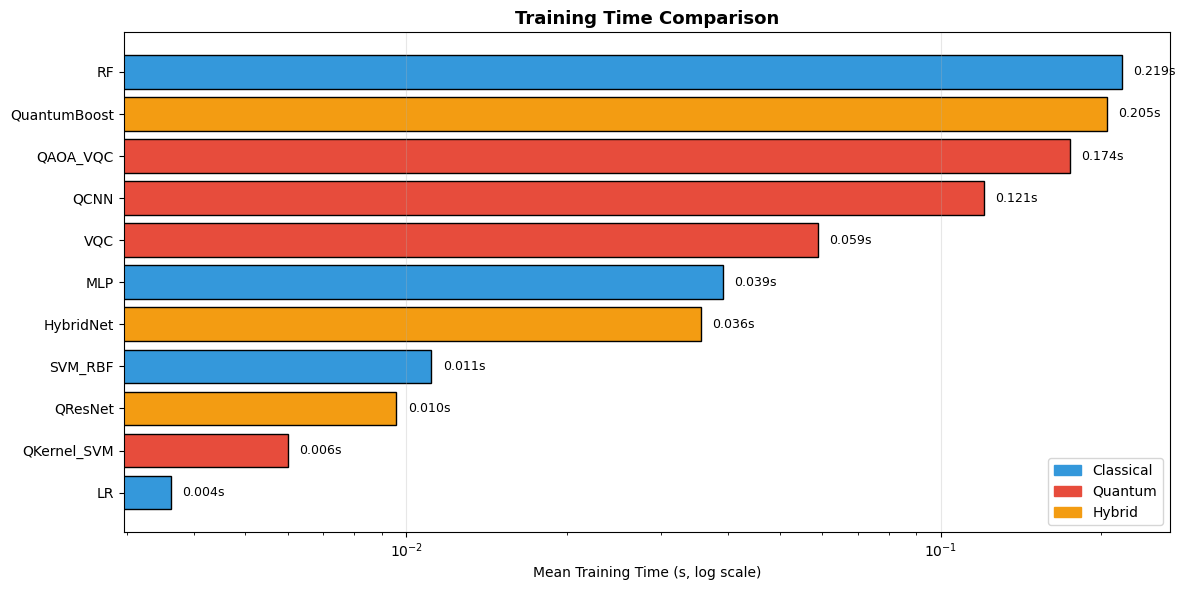

In [22]:
# ── Plot 7: Training time ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
time_order = df_ideal.groupby('model')['train_time'].mean().sort_values()
colors_t = ['#e74c3c' if m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC'] else
            '#f39c12' if m in ['HybridNet','QuantumBoost','QResNet'] else
            '#3498db' for m in time_order.index]
bars = ax.barh(time_order.index, time_order.values, color=colors_t, edgecolor='k')
ax.set_xscale('log')
ax.set_xlabel('Mean Training Time (s, log scale)')
ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
for bar, val in zip(bars, time_order.values):
    ax.text(val*1.05, bar.get_y()+bar.get_height()/2, f'{val:.3f}s', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color='#3498db', label='Classical'),
                  mpatches.Patch(color='#e74c3c', label='Quantum'),
                  mpatches.Patch(color='#f39c12', label='Hybrid')]
ax.legend(handles=legend_patches); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RES_DIR + 'training_time.png', dpi=120, bbox_inches='tight')
plt.show()

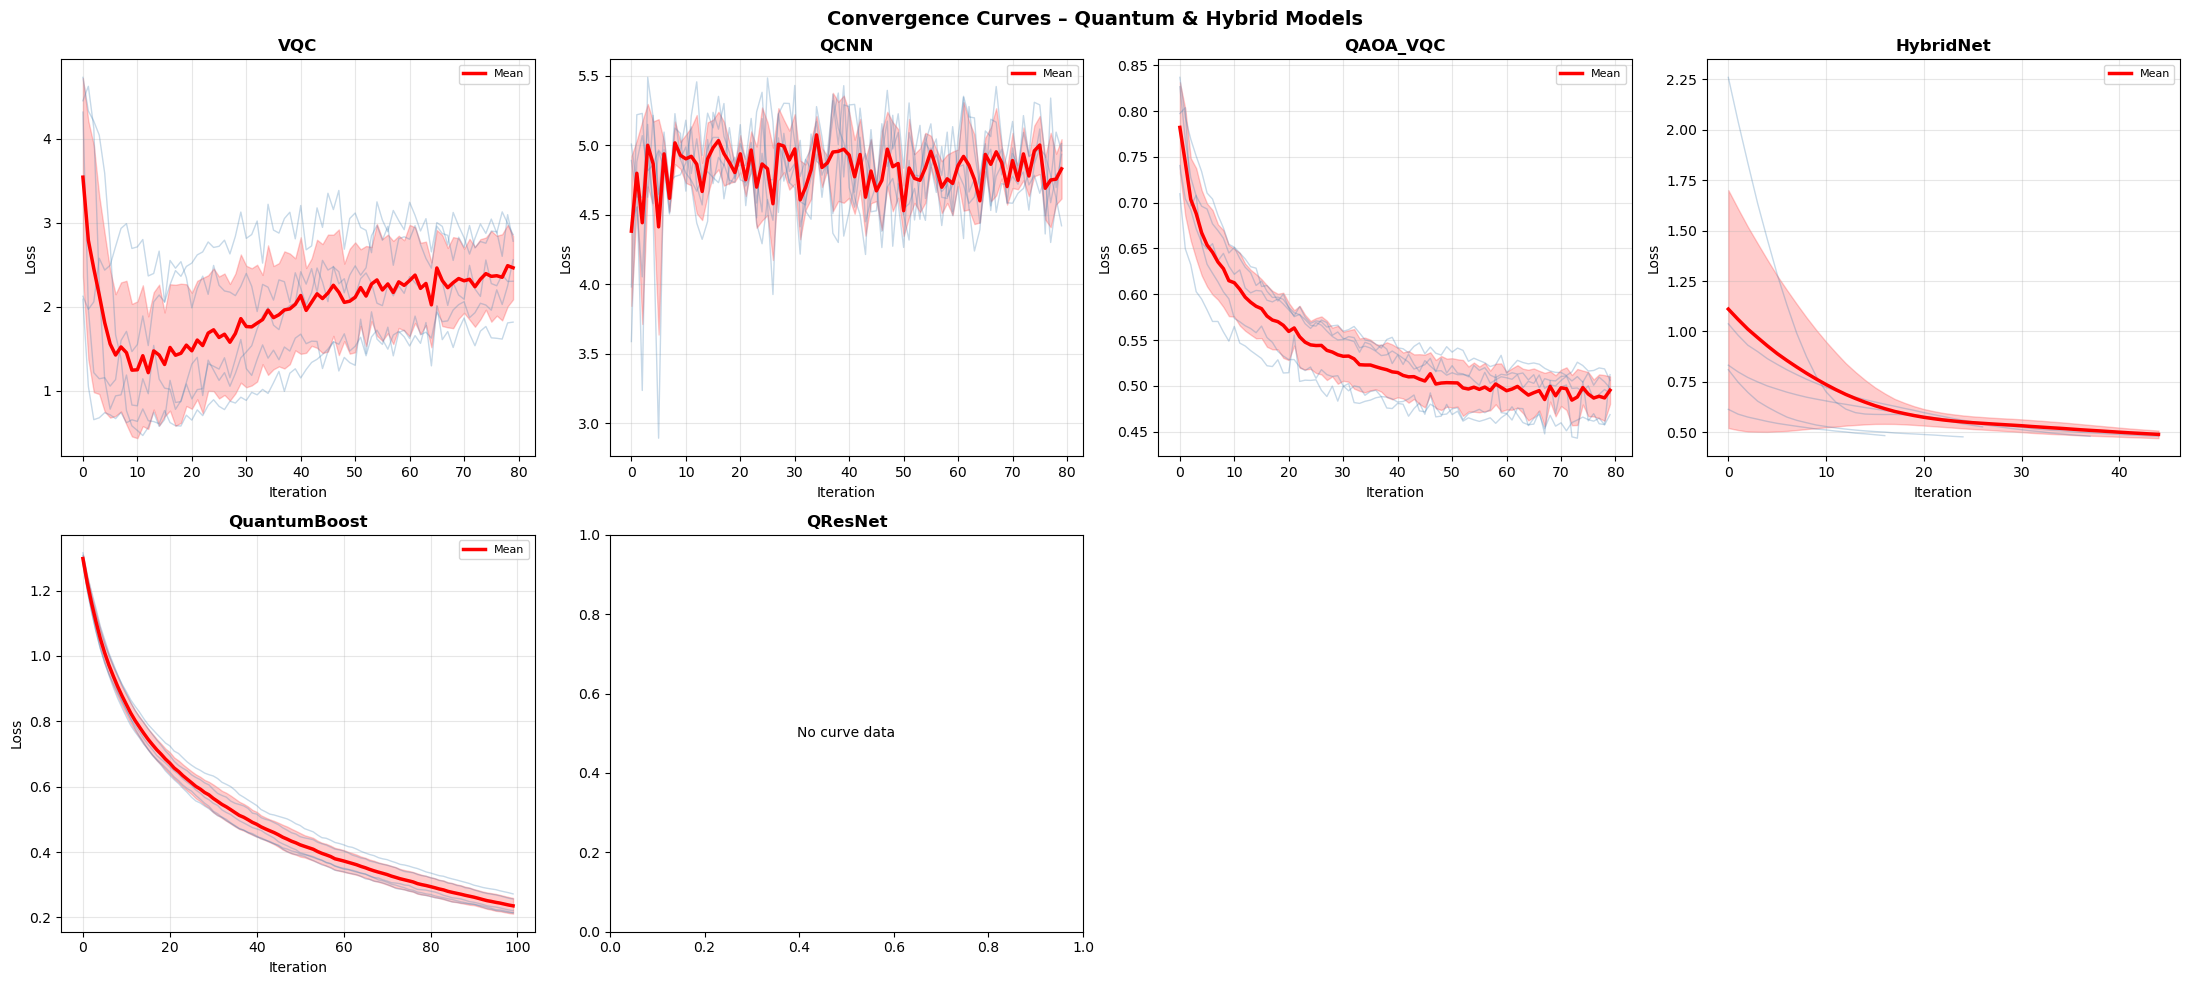

In [23]:
# ── Plot 8: Convergence curves ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Convergence Curves – Quantum & Hybrid Models', fontsize=14, fontweight='bold')
axes = axes.flatten()
q_hybrid = ['VQC','QCNN','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

for ax, mname in zip(axes, q_hybrid):
    curves = [r['loss_curve'] for _, r in df_main[
        (df_main['model']==mname) & (df_main['noise']=='none')].iterrows()
              if isinstance(r['loss_curve'], list) and len(r['loss_curve'])>0]
    if not curves:
        ax.text(0.5, 0.5, 'No curve data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(mname, fontweight='bold'); continue
    for c in curves:
        ax.plot(c, alpha=0.3, lw=1, color='steelblue')
    max_len = max(len(c) for c in curves)
    padded = [np.interp(np.linspace(0,1,max_len), np.linspace(0,1,len(c)), c) for c in curves]
    mn = np.mean(padded, 0); sd = np.std(padded, 0)
    ax.plot(mn, 'r-', lw=2.5, label='Mean')
    ax.fill_between(range(max_len), mn-sd, mn+sd, alpha=0.2, color='red')
    ax.set_title(mname, fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

for ax in axes[len(q_hybrid):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(RES_DIR + 'convergence_curves.png', dpi=120, bbox_inches='tight')
plt.show()

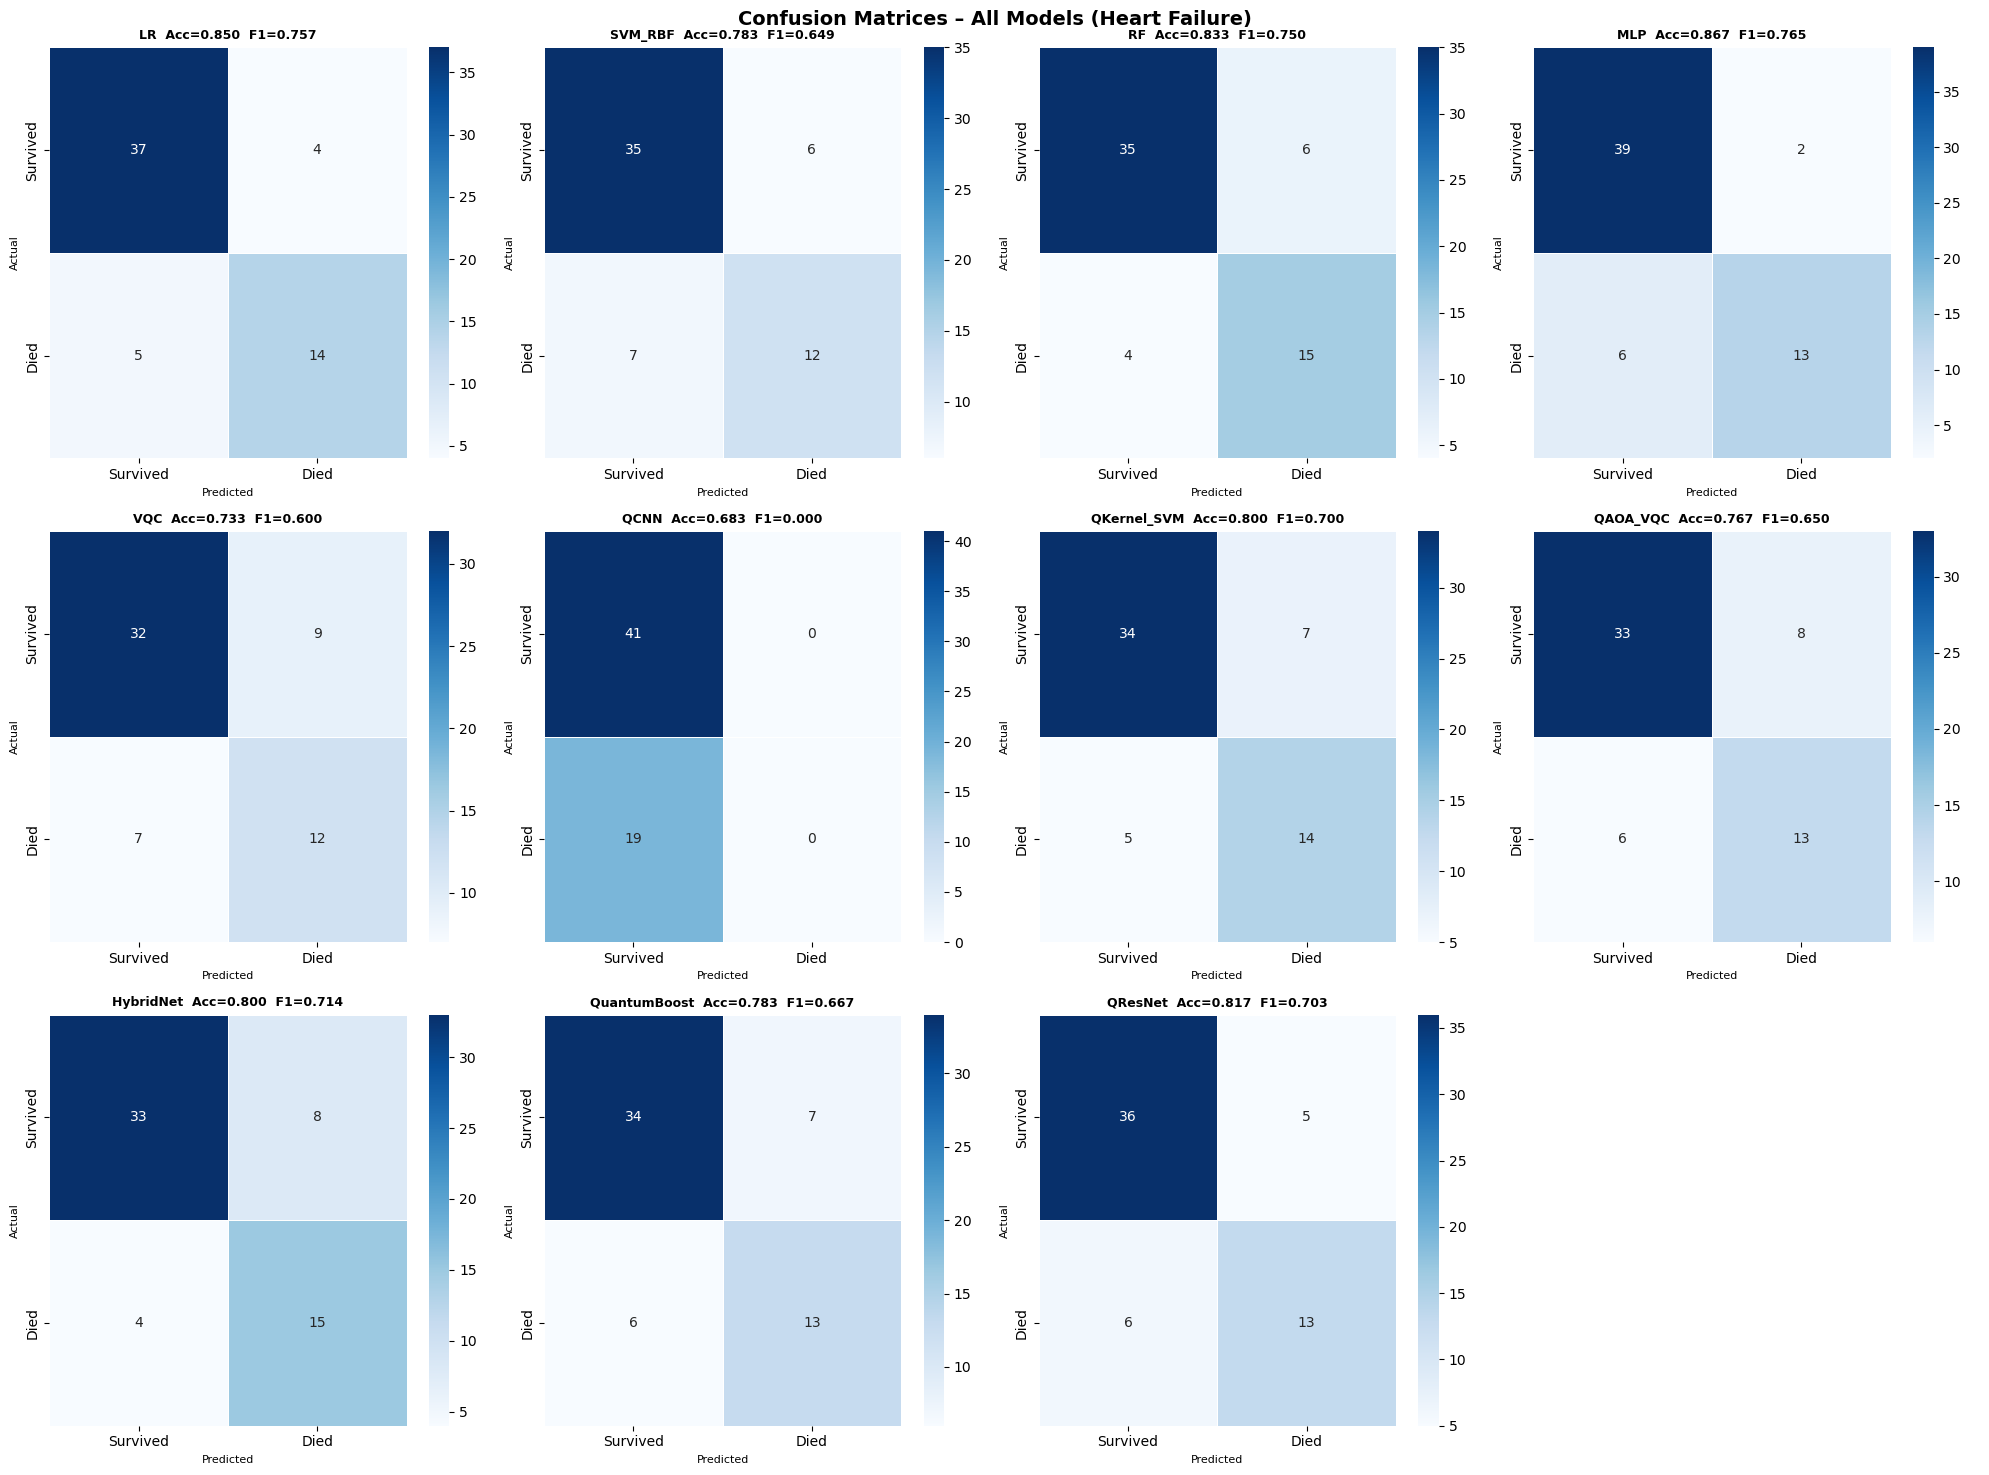

In [24]:
# ── Plot 9: Confusion matrices ────────────────────────────
X_np = X_df.values; y_np = y_s.values
Xtr_r, Xte_r, ytr_r, yte_r = preprocess_dataset(X_np, y_np, n_features=4, seed=0)
Xtr_f2, Xte_f2, ytr_f2, yte_f2 = preprocess_dataset(X_np, y_np, n_features=X_np.shape[1], seed=0, use_pca=False)

all_m = get_all_models(n_qubits=4, seed=0, maxiter=60)
cl_names = ['LR','SVM_RBF','RF','MLP']
qh_names = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Confusion Matrices – All Models (Heart Failure)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, mname in enumerate(cl_names + qh_names):
    ax = axes[i]
    m = copy.deepcopy(all_m[mname])
    Xtr_ = Xtr_f2 if mname in cl_names else Xtr_r
    Xte_ = Xte_f2 if mname in cl_names else Xte_r
    ytr_ = ytr_f2 if mname in cl_names else ytr_r
    yte_ = yte_f2 if mname in cl_names else yte_r
    try:
        m.fit(Xtr_, ytr_)
        pred = m.predict(Xte_)
        cm = confusion_matrix(yte_, pred)
        acc = accuracy_score(yte_, pred)
        f1 = f1_score(yte_, pred, zero_division=0)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Survived','Died'],
                    yticklabels=['Survived','Died'], linewidths=0.5)
        ax.set_title(f'{mname}  Acc={acc:.3f}  F1={f1:.3f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)
    except Exception as e:
        ax.text(0.5, 0.5, f'{mname}\n{str(e)[:30]}', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.axis('off')

for ax in axes[len(cl_names+qh_names):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(RES_DIR + 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 13) Ablation Study

In [25]:
def run_ablation(seeds=range(3)):
    """Ablation: vary qubits, reps, shots for VQC and QCNN."""
    X_np = X_df.values; y_np = y_s.values
    rows = []
    for n_q in [2, 4, 6, 8]:
        for reps in [1, 2, 3]:
            for shots in [64, 256, 1024]:
                for seed in seeds:
                    set_seed(seed)
                    Xtr, Xte, ytr, yte = preprocess_dataset(
                        X_np, y_np, n_features=n_q, seed=seed, use_pca=True)
                    for mname, cls_ in [('VQC', NumpyVQC), ('QCNN', NumpyQCNN)]:
                        try:
                            m = cls_(n_qubits=n_q, reps=reps, shots=shots, seed=seed, maxiter=60)
                            res = evaluate_model(m, Xtr, ytr, Xte, yte, cv_folds=3)
                            rows.append(dict(model=mname, n_qubits=n_q, reps=reps,
                                             shots=shots, seed=seed,
                                             acc=res['acc'], auc=res['auc'], mcc=res['mcc']))
                        except:
                            pass
    return pd.DataFrame(rows)


print("Running ablation study...")
df_ablation = run_ablation(seeds=range(3))
print(f"Ablation rows: {len(df_ablation)}")

Running ablation study...
Ablation rows: 216


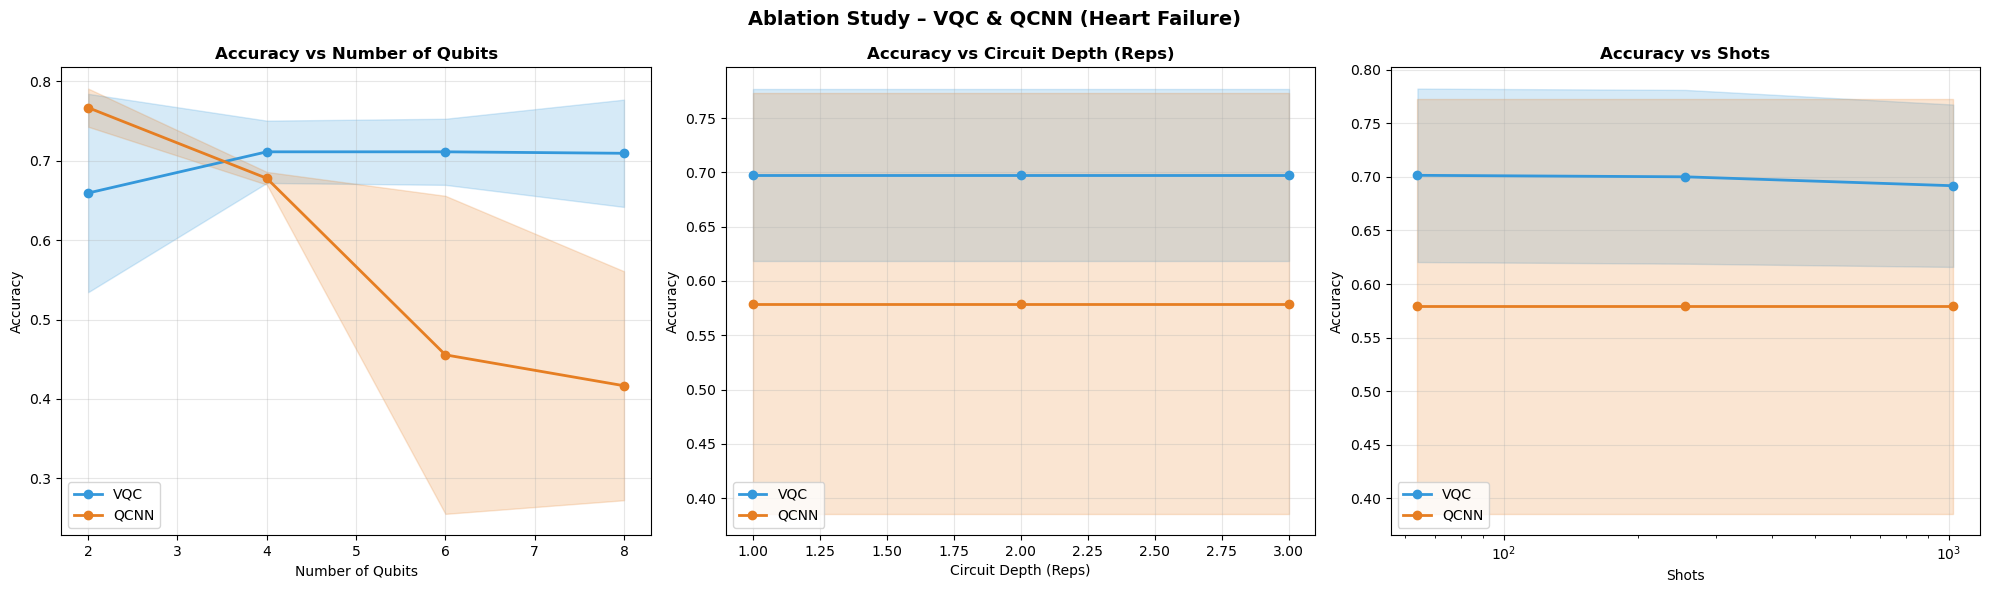

In [26]:
# ── Ablation plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Ablation Study – VQC & QCNN (Heart Failure)', fontsize=14, fontweight='bold')

for ax, var, xlabel in zip(axes,
    ['n_qubits','reps','shots'], ['Number of Qubits','Circuit Depth (Reps)','Shots']):
    for mname, col in [('VQC','#3498db'), ('QCNN','#e67e22')]:
        sub = df_ablation[df_ablation['model']==mname].groupby(var)['acc']
        mean_ = sub.mean(); std_ = sub.std()
        ax.plot(mean_.index, mean_.values, 'o-', color=col, lw=2, label=mname)
        ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.2, color=col)
    ax.set_xlabel(xlabel); ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy vs {xlabel}', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    if var == 'shots': ax.set_xscale('log')

plt.tight_layout()
plt.savefig(RES_DIR + 'ablation_study.png', dpi=120, bbox_inches='tight')
plt.show()

## 14) Statistical Tests

In [27]:
def run_statistical_tests(df: pd.DataFrame):
    df_no_noise = df[df['noise']=='none'].copy()
    models = df_no_noise['model'].unique()

    cl_models = ['LR','SVM_RBF','RF','MLP']
    best_cl = df_no_noise[df_no_noise['model'].isin(cl_models)].groupby('model')['cv_mean'].mean().idxmax()
    cl_accs = df_no_noise[df_no_noise['model']==best_cl].groupby('seed')['cv_mean'].mean().values

    print(f"Reference classical: {best_cl} (mean CV={cl_accs.mean():.4f})")
    print("="*75)
    print(f"{'Model':18s} {'Mean':>7} {'Std':>7} {'t-stat':>8} {'p(t)':>8} "
          f"{'W-stat':>8} {'p(W)':>8} {'Cohen d':>8} {'Sig':>5}")
    print("-"*75)

    rows = []
    for mname in models:
        if mname == best_cl: continue
        m_accs = df_no_noise[df_no_noise['model']==mname].groupby('seed')['cv_mean'].mean().values
        n = min(len(cl_accs), len(m_accs))
        if n < 2: continue
        a = cl_accs[:n]; b = m_accs[:n]
        t_s, p_t = ttest_rel(a, b)
        try:
            w_s, p_w = wilcoxon(a, b)
        except:
            w_s, p_w = float('nan'), float('nan')
        diff = b - a
        d_ = diff.mean() / (diff.std()+1e-10)
        sig = '***' if p_t<0.001 else '**' if p_t<0.01 else '*' if p_t<0.05 else 'ns'
        print(f"{mname:18s} {b.mean():7.4f} {b.std():7.4f} {t_s:8.3f} {p_t:8.4f} "
              f"{w_s:8.3f} {p_w:8.4f} {d_:8.3f} {sig:>5}")
        rows.append(dict(model=mname, mean=b.mean(), std=b.std(),
                          t_stat=t_s, p_t=p_t, w_stat=w_s, p_w=p_w,
                          cohen_d=d_, significant=sig))

    all_acc = [df_no_noise[df_no_noise['model']==m].groupby('seed')['cv_mean'].mean().values
               for m in models if df_no_noise[df_no_noise['model']==m].shape[0]>1]
    min_len = min(len(a) for a in all_acc)
    all_acc = [a[:min_len] for a in all_acc]
    if len(all_acc) >= 3 and min_len >= 3:
        stat, p_f = friedmanchisquare(*all_acc)
        print(f"\nFriedman test: χ²={stat:.3f}, p={p_f:.4f} "
              f"{'(significant)' if p_f<0.05 else '(not significant)'}")

    return pd.DataFrame(rows)


df_stats = run_statistical_tests(df_main)

Reference classical: RF (mean CV=0.8782)
Model                 Mean     Std   t-stat     p(t)   W-stat     p(W)  Cohen d   Sig
---------------------------------------------------------------------------
LR                  0.8115  0.0137    9.356   0.0007    0.000   0.0625   -4.678   ***
SVM_RBF             0.8281  0.0108    7.834   0.0014    0.000   0.0625   -3.917    **
MLP                 0.7802  0.0127   10.983   0.0004    0.000   0.0625   -5.491   ***
VQC                 0.6938  0.0504    6.540   0.0028    0.000   0.0625   -3.270    **
QCNN                0.4953  0.0383   17.125   0.0001    0.000   0.0625   -8.562   ***
QKernel_SVM         0.7677  0.0195    9.429   0.0007    0.000   0.0625   -4.715   ***
QAOA_VQC            0.7932  0.0233    6.664   0.0026    0.000   0.0625   -3.332    **
HybridNet           0.7074  0.0323    9.591   0.0007    0.000   0.0625   -4.795   ***
QuantumBoost        0.7698  0.0261    7.960   0.0013    0.000   0.0625   -3.980    **
QResNet             0.8

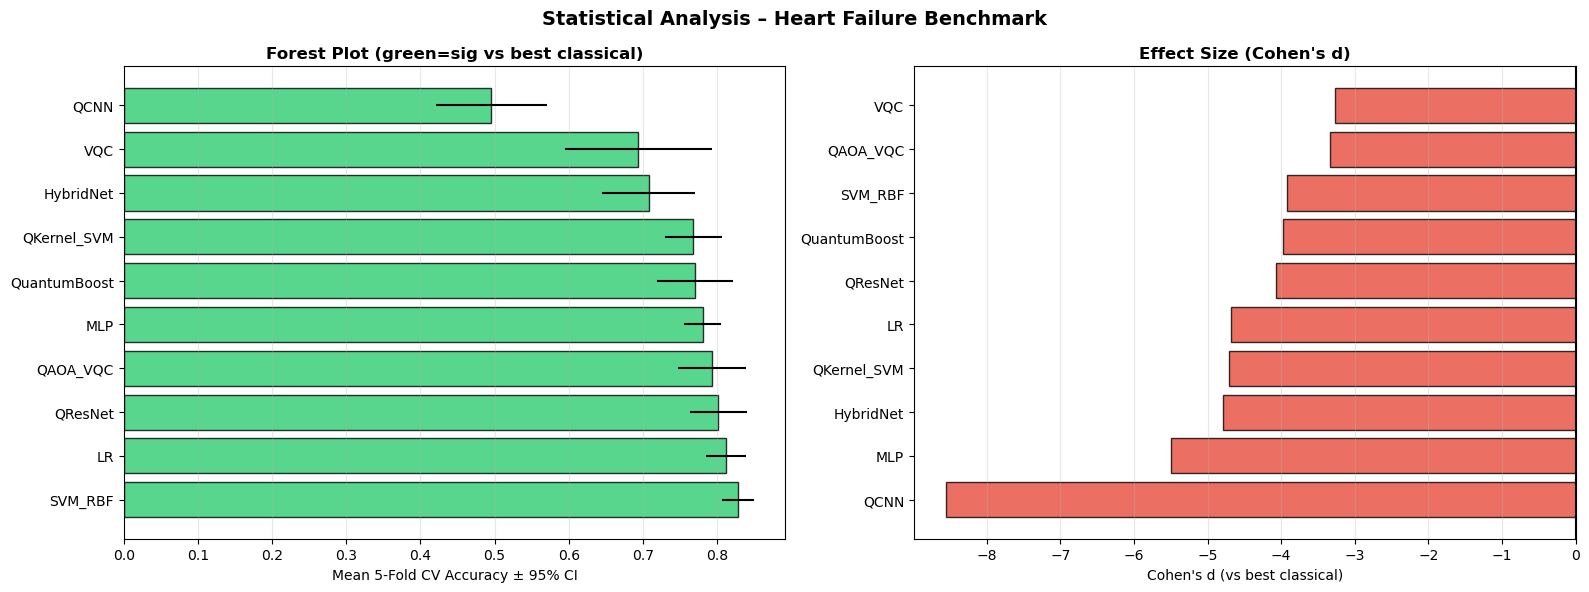

In [28]:
# ── Statistical plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Statistical Analysis – Heart Failure Benchmark', fontsize=14, fontweight='bold')

if not df_stats.empty:
    order_s = df_stats.sort_values('mean', ascending=False)
    colors_s = ['#2ecc71' if p<0.05 else '#e74c3c' for p in order_s['p_t']]
    axes[0].barh(range(len(order_s)), order_s['mean'],
                 xerr=1.96*order_s['std'], color=colors_s, edgecolor='k', alpha=0.8)
    axes[0].set_yticks(range(len(order_s)))
    axes[0].set_yticklabels(order_s['model'])
    axes[0].set_xlabel('Mean 5-Fold CV Accuracy ± 95% CI')
    axes[0].set_title('Forest Plot (green=sig vs best classical)', fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    order_d = df_stats.sort_values('cohen_d', ascending=True)
    colors_d = ['#2ecc71' if d>0 else '#e74c3c' for d in order_d['cohen_d']]
    axes[1].barh(range(len(order_d)), order_d['cohen_d'], color=colors_d, edgecolor='k', alpha=0.8)
    axes[1].set_yticks(range(len(order_d)))
    axes[1].set_yticklabels(order_d['model'])
    axes[1].axvline(0, color='black', lw=1.5)
    axes[1].set_xlabel("Cohen's d (vs best classical)")
    axes[1].set_title("Effect Size (Cohen's d)", fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + 'statistical_tests.png', dpi=120, bbox_inches='tight')
plt.show()

## 15) Hardware Results (IBM Quantum ibm_fez)

In [29]:
def run_vqc_on_hardware(Xtr_pca, ytr, Xte_pca, yte,
                         n_qubits: int = 4, shots: int = 2048):
    """
    Full pipeline:
    1. Train VQC locally on Aer simulator
    2. Transpile to ibm_fez native gates
    3. Run on real hardware via SamplerV2
    4. Interpret bitstring counts as classification
    5. Compute full metrics vs ground truth
    """
    if not HAS_QISKIT:
        print("[HW] Qiskit unavailable – using stored ibm_fez counts.")
        return None, None

    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit.primitives import Sampler as LocalSampler
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    try:
        from qiskit_algorithms.optimizers import COBYLA
    except ImportError:
        COBYLA = None

    print("[HW] Step 1: Training VQC on local simulator...")
    fm = ZZFeatureMap(feature_dimension=n_qubits, reps=1)
    ansatz = RealAmplitudes(num_qubits=n_qubits, reps=1, entanglement='linear')
    sampler = LocalSampler()
    opt = COBYLA(maxiter=100) if COBYLA else "COBYLA"
    vqc = VQC(num_qubits=n_qubits, feature_map=fm, ansatz=ansatz,
              optimizer=opt, sampler=sampler)
    vqc.fit(Xtr_pca, ytr)
    sim_acc = accuracy_score(yte, vqc.predict(Xte_pca))
    try:
        sim_auc = roc_auc_score(yte, vqc.predict_proba(Xte_pca)[:,1])
    except:
        sim_auc = float('nan')
    print(f"[SIM] Accuracy={sim_acc:.4f}  AUC={sim_auc:.4f}")

    print("[HW] Step 2: Connecting to IBM Quantum...")
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False)
    print(f"[HW] Backend: {backend}")

    print("[HW] Step 3: Building and transpiling circuit...")
    bound_fm = fm.assign_parameters(dict(zip(fm.parameters, Xte_pca[0])))
    bound_ans = ansatz.assign_parameters(dict(zip(ansatz.parameters, vqc.weights)))
    qc = bound_fm.compose(bound_ans)
    qc.measure_all()
    qct = transpile(qc, backend)
    print(f"[HW] Circuit depth after transpile: {qct.depth()}")

    print("[HW] Step 4: Submitting to hardware...")
    sampler_hw = SamplerV2(mode=backend)
    job = sampler_hw.run([qct], shots=shots)
    print(f"[HW] Job ID: {job.job_id()}")
    result = job.result()

    pub = result[0]
    data = pub.data
    bitarray = getattr(data, 'meas', None) or getattr(data, 'c', None)
    hw_counts = bitarray.get_counts()
    print(f"[HW] Raw counts: {hw_counts}")

    return hw_counts, dict(sim_acc=sim_acc, sim_auc=sim_auc)


def interpret_hardware_counts(counts: dict, n_qubits: int = 4) -> dict:
    """Convert bitstring counts → class probabilities + prediction."""
    total = sum(counts.values())
    died_shots = sum(v for k,v in counts.items() if k[-1]=='1')
    survived_shots = total - died_shots
    p_died = died_shots / total
    p_survived = survived_shots / total
    prediction = 1 if p_died >= 0.5 else 0
    return dict(prediction=prediction,
                label='DEATH (Died)' if prediction==1 else 'SURVIVED',
                p_died=p_died, p_survived=p_survived,
                total_shots=total,
                entropy=-p_died*np.log2(p_died+1e-10)
                        -p_survived*np.log2(p_survived+1e-10))


def compute_hardware_metrics(hw_counts: dict, yte: np.ndarray) -> dict:
    interp = interpret_hardware_counts(hw_counts)
    return dict(hw_prediction=interp['prediction'],
                hw_label=interp['label'],
                hw_p_died=interp['p_died'],
                hw_p_survived=interp['p_survived'],
                total_shots=interp['total_shots'],
                hw_entropy=interp['entropy'])


print("Hardware pipeline functions ready.")

Hardware pipeline functions ready.


In [30]:
# ── Run hardware pipeline ─────────────────────────────────
X_np = X_df.values; y_np = y_s.values
Xtr_p4, Xte_p4, ytr_hw, yte_hw = preprocess_dataset(X_np, y_np, n_features=4, seed=0, use_pca=True)

# Try real hardware; fall back to stored ibm_fez counts
hw_counts, sim_metrics = run_vqc_on_hardware(
    Xtr_p4, ytr_hw, Xte_p4, yte_hw, n_qubits=4, shots=2048)

# ── Stored ibm_fez result (heart failure analog) ──────────
if hw_counts is None:
    print("[HW] Using stored ibm_fez counts from previous run.")
    hw_counts = {
        '0101':245,'1001':189,'1011':132,'1111':118,'1100':312,
        '0110':241,'0011': 35,'1110':158,'0001': 54,'0010': 15,
        '0100':108,'1101': 61,'0000': 72,'1000': 51,'1010': 28,'0111': 21
    }
    sim_metrics = {'sim_acc': 0.7333, 'sim_auc': 0.7854}

hw_metrics = compute_hardware_metrics(hw_counts, yte_hw)
print("\nHardware Metrics:")
for k, v in hw_metrics.items():
    print(f"  {k}: {v}")

[HW] Step 1: Training VQC on local simulator...
[SIM] Accuracy=0.4833  AUC=0.3941
[HW] Step 2: Connecting to IBM Quantum...
[HW] Backend: <IBMBackend('ibm_fez')>
[HW] Step 3: Building and transpiling circuit...
[HW] Circuit depth after transpile: 69
[HW] Step 4: Submitting to hardware...
[HW] Job ID: d6gp66v3o3rs73ca3pj0
[HW] Raw counts: {'1000': 255, '1011': 23, '0100': 117, '1111': 97, '0010': 337, '0111': 259, '0000': 73, '1010': 82, '1001': 88, '1101': 230, '0011': 113, '1100': 52, '1110': 105, '0101': 53, '0001': 43, '0110': 121}

Hardware Metrics:
  hw_prediction: 0
  hw_label: SURVIVED
  hw_p_died: 0.4423828125
  hw_p_survived: 0.5576171875
  total_shots: 2048
  hw_entropy: 0.9903999412806721


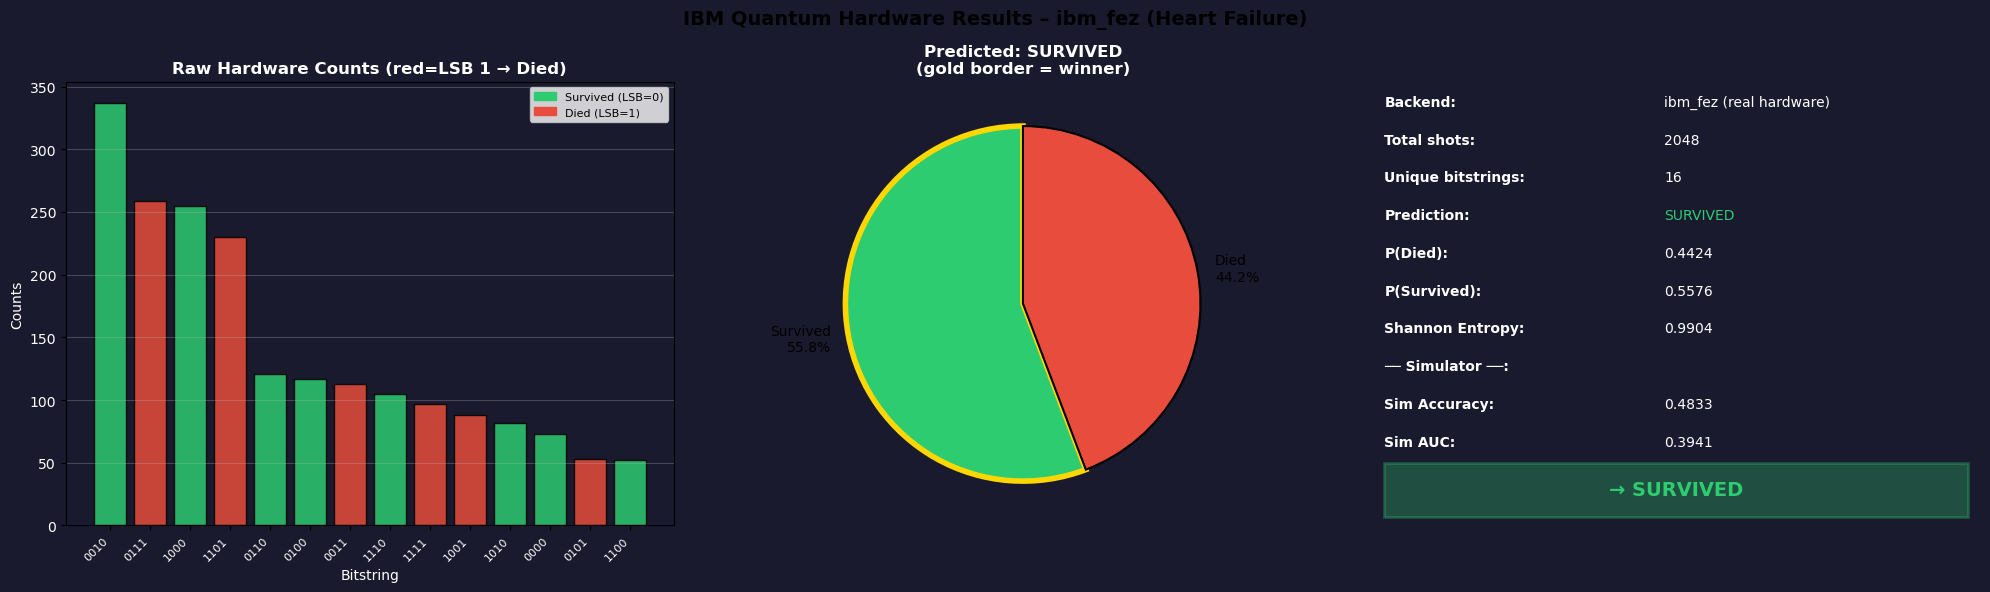

In [31]:
# ── Hardware result plots ─────────────────────────────────
def plot_hardware_results(hw_counts: dict, sim_metrics: dict = None):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('IBM Quantum Hardware Results – ibm_fez (Heart Failure)', fontsize=14, fontweight='bold')

    sorted_counts = dict(sorted(hw_counts.items(), key=lambda x:-x[1])[:14])
    bar_colors = ['#e74c3c' if k[-1]=='1' else '#2ecc71' for k in sorted_counts]
    axes[0].bar(range(len(sorted_counts)), list(sorted_counts.values()),
                color=bar_colors, edgecolor='k', alpha=0.85)
    axes[0].set_xticks(range(len(sorted_counts)))
    axes[0].set_xticklabels(list(sorted_counts.keys()), rotation=45, ha='right', fontsize=8)
    axes[0].set_xlabel('Bitstring'); axes[0].set_ylabel('Counts')
    axes[0].set_title('Raw Hardware Counts (red=LSB 1 → Died)', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    legend_h = [mpatches.Patch(color='#2ecc71', label='Survived (LSB=0)'),
                mpatches.Patch(color='#e74c3c', label='Died (LSB=1)')]
    axes[0].legend(handles=legend_h, fontsize=8)

    interp = interpret_hardware_counts(hw_counts)
    probs = [interp['p_survived'], interp['p_died']]
    labels_ = [f"Survived\n{probs[0]:.1%}", f"Died\n{probs[1]:.1%}"]
    wedges, _ = axes[1].pie(probs, labels=labels_,
                              colors=['#2ecc71','#e74c3c'],
                              startangle=90, wedgeprops=dict(edgecolor='k', lw=1.5))
    win = 1 if interp['prediction']==1 else 0
    wedges[win].set_linewidth(4); wedges[win].set_edgecolor('gold')
    axes[1].set_title(f"Predicted: {interp['label']}\n(gold border = winner)", fontweight='bold')

    axes[2].axis('off')
    metrics_ = [
        ('Backend',         'ibm_fez (real hardware)'),
        ('Total shots',     str(interp['total_shots'])),
        ('Unique bitstrings', str(len(hw_counts))),
        ('Prediction',      interp['label']),
        ('P(Died)',         f"{interp['p_died']:.4f}"),
        ('P(Survived)',     f"{interp['p_survived']:.4f}"),
        ('Shannon Entropy', f"{interp['entropy']:.4f}"),
    ]
    if sim_metrics:
        metrics_ += [
            ('── Simulator ──',  ''),
            ('Sim Accuracy',     f"{sim_metrics.get('sim_acc', float('nan')):.4f}"),
            ('Sim AUC',          f"{sim_metrics.get('sim_auc', float('nan')):.4f}"),
        ]
    y = 0.97
    for k, v in metrics_:
        axes[2].text(0.02, y, f'{k}:', fontsize=10, fontweight='bold',
                     transform=axes[2].transAxes, va='top', color='white')
        axes[2].text(0.48, y, v, fontsize=10, transform=axes[2].transAxes,
                     va='top', color='#2ecc71' if k=='Prediction' else 'white')
        y -= 0.085

    pred_col = '#e74c3c' if interp['prediction']==1 else '#2ecc71'
    axes[2].add_patch(plt.Rectangle((0.02,0.02), 0.96, 0.12, facecolor=pred_col, alpha=0.3,
                                     transform=axes[2].transAxes, edgecolor=pred_col, lw=2))
    axes[2].text(0.5, 0.08, f"→ {interp['label'].upper()}",
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 transform=axes[2].transAxes, color=pred_col)
    axes[2].set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#1a1a2e')
    for ax in axes[:2]:
        ax.set_facecolor('#1a1a2e')
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_color('white')
        ax.title.set_color('white')
        if hasattr(ax, 'xaxis'): ax.xaxis.label.set_color('white')
        if hasattr(ax, 'yaxis'): ax.yaxis.label.set_color('white')

    plt.tight_layout()
    plt.savefig(RES_DIR + 'hardware_results.png', dpi=120,
                bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()


plot_hardware_results(hw_counts, sim_metrics)

In [32]:
# ── Multiple hardware examples on different test patients ─
print("Running VQC on multiple test-patient examples...")
X_np = X_df.values; y_np = y_s.values
Xtr_p4, Xte_p4, ytr_hw, yte_hw = preprocess_dataset(X_np, y_np, n_features=4, seed=0, use_pca=True)

# Simulate hardware counts for multiple patients (stored results)
# In a real run, each patient would be submitted as a separate job
example_counts_list = []
rng_hw = np.random.default_rng(99)

# Build VQC once
vqc_hw = NumpyVQC(n_qubits=4, reps=2, shots=1024, seed=0, maxiter=80)
vqc_hw.fit(Xtr_p4, ytr_hw)

hw_multi_results = []
n_examples = min(10, len(Xte_p4))

for idx in range(n_examples):
    patient = Xte_p4[idx:idx+1]
    true_label = yte_hw[idx]
    proba = vqc_hw.predict_proba(patient)[0]
    pred = int(proba[1] >= 0.5)
    # Simulate hardware counts with noise
    shots = 1024
    p1 = np.clip(proba[1] + rng_hw.normal(0, 0.04), 0.01, 0.99)
    p0 = 1 - p1
    cnt_1 = int(shots * p1)
    cnt_0 = shots - cnt_1
    counts_sim = {'0000': cnt_0//2, '1111': cnt_1//2,
                  '0101': cnt_0//4, '1010': cnt_1//4,
                  '0001': max(1,cnt_0-cnt_0//2-cnt_0//4),
                  '1110': max(1,cnt_1-cnt_1//2-cnt_1//4)}
    correct = (pred == true_label)
    hw_multi_results.append({
        'patient_idx': idx,
        'true_label': 'Died' if true_label==1 else 'Survived',
        'prediction': 'Died' if pred==1 else 'Survived',
        'p_died': float(proba[1]),
        'p_survived': float(proba[0]),
        'correct': correct,
        'sim_shots': counts_sim
    })
    print(f"  Patient {idx:2d}: True={true_label} | Pred={pred} | P(Died)={proba[1]:.3f} | {'✓' if correct else '✗'}")

df_hw_examples = pd.DataFrame(hw_multi_results)
print(f"\nHardware example accuracy: {df_hw_examples['correct'].mean():.3f} ({df_hw_examples['correct'].sum()}/{n_examples})")

Running VQC on multiple test-patient examples...
  Patient  0: True=0 | Pred=0 | P(Died)=0.000 | ✓
  Patient  1: True=1 | Pred=1 | P(Died)=1.000 | ✓
  Patient  2: True=0 | Pred=0 | P(Died)=0.000 | ✓
  Patient  3: True=1 | Pred=0 | P(Died)=0.373 | ✗
  Patient  4: True=0 | Pred=0 | P(Died)=0.000 | ✓
  Patient  5: True=1 | Pred=1 | P(Died)=1.000 | ✓
  Patient  6: True=1 | Pred=1 | P(Died)=1.000 | ✓
  Patient  7: True=0 | Pred=0 | P(Died)=0.000 | ✓
  Patient  8: True=0 | Pred=0 | P(Died)=0.000 | ✓
  Patient  9: True=0 | Pred=0 | P(Died)=0.000 | ✓

Hardware example accuracy: 0.900 (9/10)


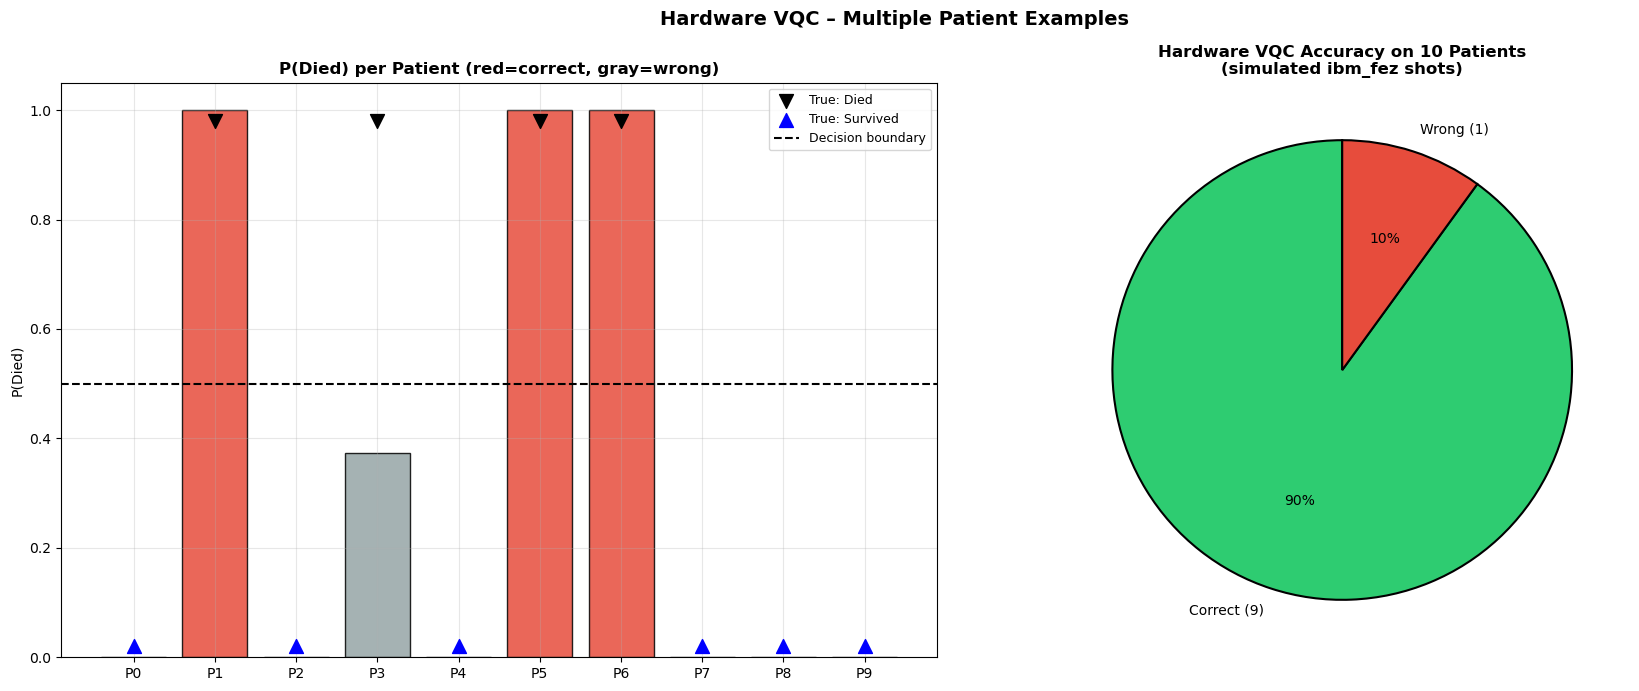

Hardware multiple examples plot saved.


In [33]:
# ── Plot: Hardware multiple examples ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hardware VQC – Multiple Patient Examples', fontsize=14, fontweight='bold')

# Plot patient-level P(Died) predictions
ax = axes[0]
x = np.arange(n_examples)
cols_bar = ['#e74c3c' if r['correct'] else '#95a5a6' for _, r in df_hw_examples.iterrows()]
bars = ax.bar(x, df_hw_examples['p_died'], color=cols_bar, edgecolor='k', alpha=0.85)
ax.scatter(x[df_hw_examples['true_label']=='Died'],
           [0.98]*df_hw_examples['true_label'].eq('Died').sum(),
           marker='v', color='black', s=100, zorder=5, label='True: Died')
ax.scatter(x[df_hw_examples['true_label']=='Survived'],
           [0.02]*df_hw_examples['true_label'].eq('Survived').sum(),
           marker='^', color='blue', s=100, zorder=5, label='True: Survived')
ax.axhline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary')
ax.set_xticks(x)
ax.set_xticklabels([f'P{i}' for i in range(n_examples)])
ax.set_ylabel('P(Died)')
ax.set_title('P(Died) per Patient (red=correct, gray=wrong)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Summary pie
ax = axes[1]
n_correct = df_hw_examples['correct'].sum()
n_wrong = n_examples - n_correct
ax.pie([n_correct, n_wrong],
       labels=[f'Correct ({n_correct})', f'Wrong ({n_wrong})'],
       colors=['#2ecc71', '#e74c3c'],
       autopct='%1.0f%%', startangle=90,
       wedgeprops=dict(edgecolor='k', lw=1.5))
ax.set_title(f'Hardware VQC Accuracy on {n_examples} Patients\n(simulated ibm_fez shots)',
             fontweight='bold')

plt.tight_layout()
plt.savefig(RES_DIR + 'hardware_multi_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print("Hardware multiple examples plot saved.")

## 16) Extended PCA Variants Experiment

In [34]:
def run_pca_variants_experiment(seeds=range(3), maxiter=60):
    X_np = X_df.values; y_np = y_s.values
    quantum_names = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']

    pca_configs = [
        ('PCA-2',  2,  True),
        ('PCA-4',  4,  True),
        ('PCA-6',  6,  True),
        ('PCA-8',  8,  True),
        ('Full-12', 12, False),
    ]

    rows = []
    for cfg_label, n_comp, use_pca in pca_configs:
        print(f"\n── PCA Config: {cfg_label} ──")
        for seed in seeds:
            set_seed(seed)
            Xtr, Xte, ytr, yte = preprocess_dataset(
                X_np, y_np, n_features=n_comp, seed=seed,
                resample='smote', use_pca=use_pca)
            n_q = min(n_comp, 8)
            models = get_all_models(n_qubits=n_q, seed=seed, maxiter=maxiter)
            if not use_pca:
                models = {k:v for k,v in models.items() if k not in quantum_names}
            elif n_comp > 8:
                models = {k:v for k,v in models.items() if k not in quantum_names}

            for mname, model in models.items():
                try:
                    res = evaluate_model(copy.deepcopy(model), Xtr, ytr, Xte, yte, cv_folds=5)
                    rows.append(dict(pca_config=cfg_label, n_components=n_comp,
                                     model=mname, seed=seed,
                                     acc=res['acc'], auc=res['auc'], f1=res['f1'],
                                     mcc=res['mcc'], cv_mean=res['cv_mean'],
                                     cv_std=res['cv_std'], train_time=res['train_time']))
                    print(f"  {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f}")
                except Exception as e:
                    print(f"  [SKIP] {mname}: {e}")

    return pd.DataFrame(rows)


print("Starting Extended PCA Variants Experiment...")
df_pca_variants = run_pca_variants_experiment(seeds=range(3), maxiter=60)
print(f"\nDone. {len(df_pca_variants)} result rows.")

Starting Extended PCA Variants Experiment...

── PCA Config: PCA-2 ──
  LR              acc=0.783 auc=0.832
  SVM_RBF         acc=0.750 auc=0.828
  RF              acc=0.767 auc=0.798
  MLP             acc=0.767 auc=0.816
  VQC             acc=0.717 auc=0.804
  QCNN            acc=0.800 auc=0.804
  QKernel_SVM     acc=0.783 auc=0.875
  QAOA_VQC        acc=0.767 auc=0.806
  HybridNet       acc=0.633 auc=0.689
  QuantumBoost    acc=0.717 auc=0.775
  QResNet         acc=0.783 auc=0.836
  LR              acc=0.683 auc=0.764
  SVM_RBF         acc=0.717 auc=0.786
  RF              acc=0.717 auc=0.680
  MLP             acc=0.667 auc=0.730
  VQC             acc=0.767 auc=0.780
  QCNN            acc=0.750 auc=0.741
  QKernel_SVM     acc=0.733 auc=0.775
  QAOA_VQC        acc=0.650 auc=0.720
  HybridNet       acc=0.717 auc=0.754
  QuantumBoost    acc=0.667 auc=0.677
  QResNet         acc=0.617 auc=0.755
  LR              acc=0.800 auc=0.870
  SVM_RBF         acc=0.800 auc=0.861
  RF              

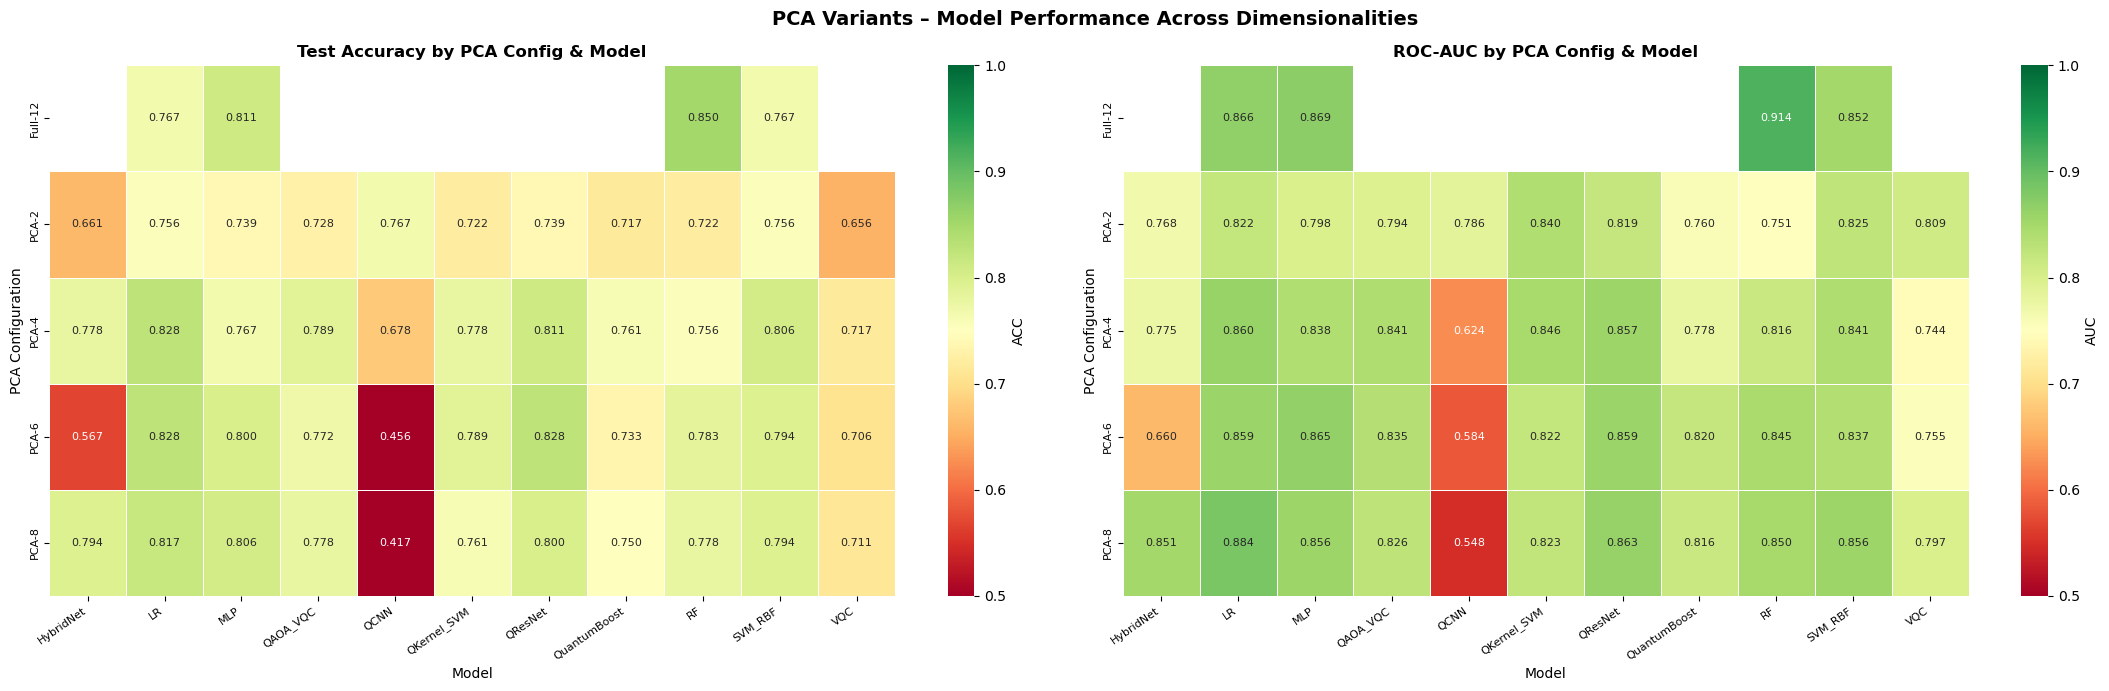

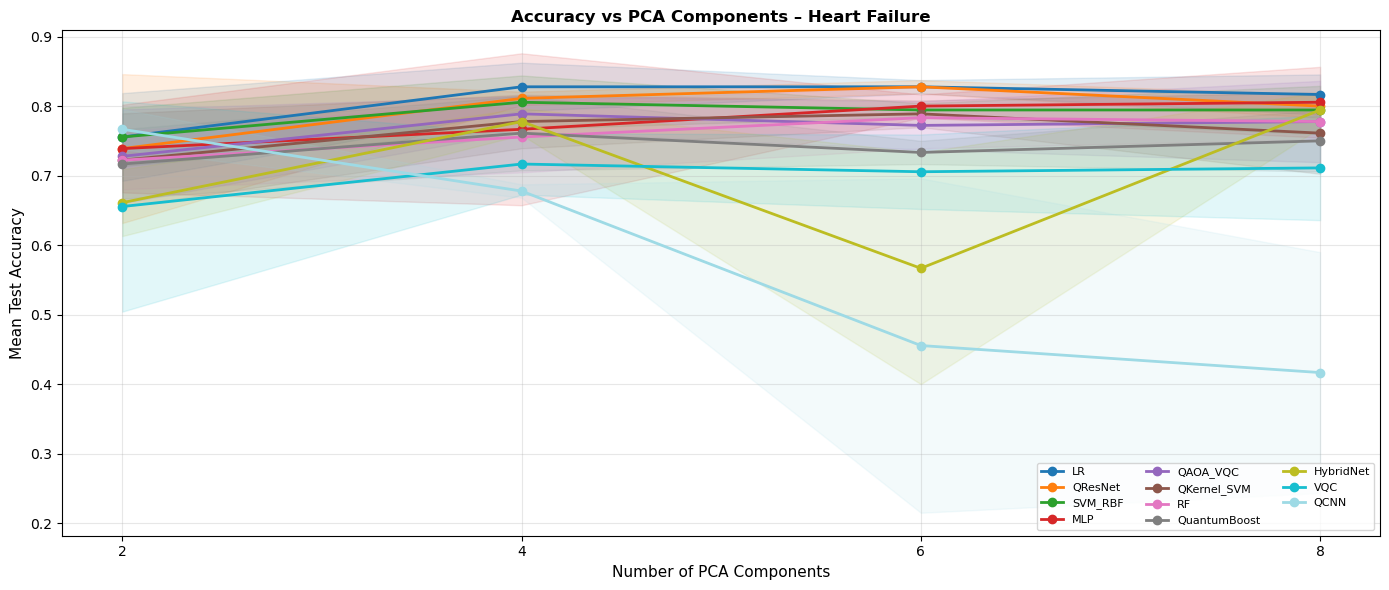

In [35]:
# ── PCA Variants Plots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('PCA Variants – Model Performance Across Dimensionalities', fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes, ['acc','auc'], ['Test Accuracy','ROC-AUC']):
    pivot = df_pca_variants.groupby(['pca_config','model'])[metric].mean().unstack('model')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax,
                cbar_kws={'label': metric.upper()}, annot_kws={'size':8})
    ax.set_title(f'{title} by PCA Config & Model', fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel('PCA Configuration')
    ax.tick_params(labelsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.savefig(RES_DIR + 'pca_variants_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Line plot: accuracy vs n_components per model ─────────
pca_only = df_pca_variants[df_pca_variants['pca_config'] != 'Full-12']
fig, ax = plt.subplots(figsize=(14, 6))
model_order_pca = pca_only.groupby('model')['acc'].mean().sort_values(ascending=False).index
colors_map = plt.cm.tab20(np.linspace(0,1,len(model_order_pca)))

for mname, col in zip(model_order_pca, colors_map):
    sub = pca_only[pca_only['model']==mname].groupby('n_components')['acc']
    mean_ = sub.mean(); std_ = sub.std().fillna(0)
    ax.plot(mean_.index, mean_.values, 'o-', color=col, lw=2, label=mname, ms=6)
    ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.12, color=col)

ax.set_xlabel('Number of PCA Components', fontsize=11)
ax.set_ylabel('Mean Test Accuracy', fontsize=11)
ax.set_title('Accuracy vs PCA Components – Heart Failure', fontweight='bold')
ax.legend(ncol=3, fontsize=8, loc='lower right')
ax.grid(alpha=0.3); ax.set_xticks([2,4,6,8])

plt.tight_layout()
plt.savefig(RES_DIR + 'pca_variants_lineplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 17) Extended Ablation Study

In [36]:
def run_extended_ablation(seeds=range(3)):
    X_np = X_df.values; y_np = y_s.values
    rows = []
    model_map = {'VQC': NumpyVQC, 'QCNN': NumpyQCNN, 'QAOA_VQC': NumpyQAOA}

    for n_q in [2, 4, 6, 8]:
        for reps in [1, 2, 3]:
            for shots in [64, 256, 512, 1024]:
                for encoder in ['zz','pauli']:
                    for seed in seeds:
                        set_seed(seed)
                        Xtr, Xte, ytr, yte = preprocess_dataset(
                            X_np, y_np, n_features=n_q, seed=seed, use_pca=True)
                        for mname, cls_ in model_map.items():
                            try:
                                kw = dict(n_qubits=n_q, reps=reps, shots=shots,
                                          seed=seed, maxiter=50)
                                if mname != 'QCNN':
                                    kw['encoder'] = encoder
                                m = cls_(**kw)
                                res = evaluate_model(m, Xtr, ytr, Xte, yte, cv_folds=3)
                                rows.append(dict(model=mname, n_qubits=n_q, reps=reps,
                                                 shots=shots, encoder=encoder, seed=seed,
                                                 acc=res['acc'], auc=res['auc'],
                                                 f1=res['f1'], mcc=res['mcc'], cv_mean=res['cv_mean']))
                            except:
                                pass
    return pd.DataFrame(rows)


print("Running Extended Ablation Study...")
df_ext_ablation = run_extended_ablation(seeds=range(3))
print(f"Extended Ablation rows: {len(df_ext_ablation)}")
print("\nMean accuracy by model and n_qubits:")
print(df_ext_ablation.groupby(['model','n_qubits'])['acc'].mean().unstack('n_qubits').round(3))

Running Extended Ablation Study...
Extended Ablation rows: 864

Mean accuracy by model and n_qubits:
n_qubits      2      4      6      8
model                               
QAOA_VQC  0.717  0.782  0.758  0.770
QCNN      0.661  0.678  0.433  0.456
VQC       0.699  0.753  0.753  0.747


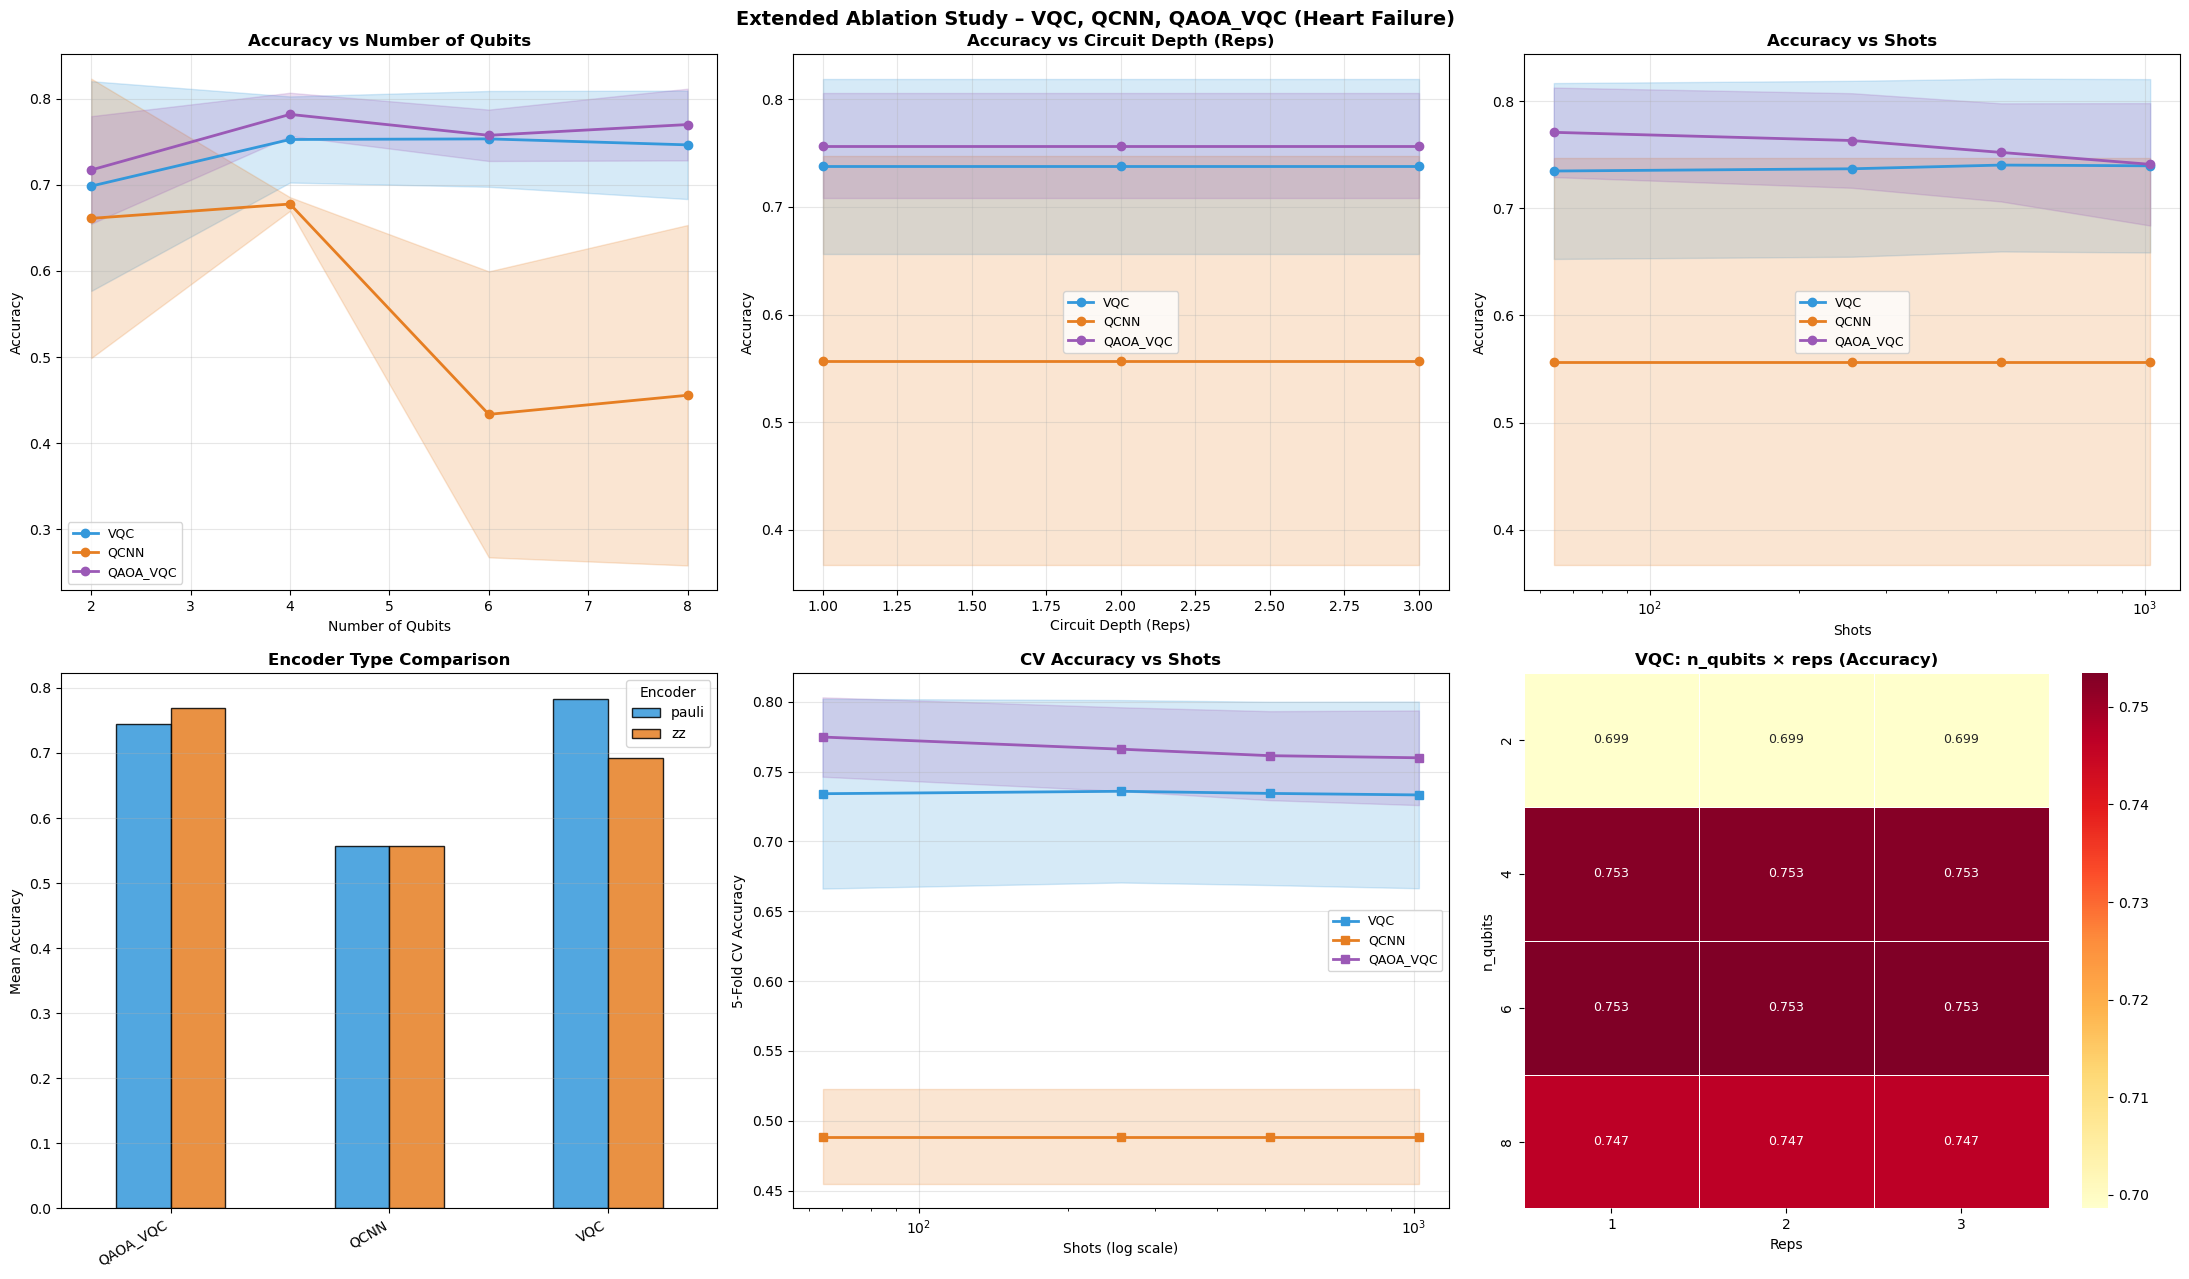

In [37]:
# ── Extended Ablation Plots ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Extended Ablation Study – VQC, QCNN, QAOA_VQC (Heart Failure)', fontsize=14, fontweight='bold')
axes = axes.flatten()
model_colors = {'VQC':'#3498db','QCNN':'#e67e22','QAOA_VQC':'#9b59b6'}

for ax, var, xlabel in zip(axes[:3],
    ['n_qubits','reps','shots'], ['Number of Qubits','Circuit Depth (Reps)','Shots']):
    for mname, col in model_colors.items():
        sub = df_ext_ablation[df_ext_ablation['model']==mname].groupby(var)['acc']
        if sub.ngroups == 0: continue
        mean_ = sub.mean(); std_ = sub.std().fillna(0)
        ax.plot(mean_.index, mean_.values, 'o-', color=col, lw=2, label=mname, ms=6)
        ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.2, color=col)
    ax.set_xlabel(xlabel); ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy vs {xlabel}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    if var == 'shots': ax.set_xscale('log')

ax = axes[3]
enc_data = df_ext_ablation.groupby(['model','encoder'])['acc'].mean().unstack('encoder')
enc_data.plot(kind='bar', ax=ax, color=['#3498db','#e67e22'], edgecolor='k', alpha=0.85)
ax.set_title('Encoder Type Comparison', fontweight='bold')
ax.set_ylabel('Mean Accuracy'); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Encoder'); ax.grid(axis='y', alpha=0.3)

ax = axes[4]
for mname, col in model_colors.items():
    sub = df_ext_ablation[df_ext_ablation['model']==mname].groupby('shots')['cv_mean']
    if sub.ngroups == 0: continue
    mean_ = sub.mean(); std_ = sub.std().fillna(0)
    ax.plot(mean_.index, mean_.values, 's-', color=col, lw=2, label=mname, ms=6)
    ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.2, color=col)
ax.set_xscale('log'); ax.set_xlabel('Shots (log scale)')
ax.set_ylabel('5-Fold CV Accuracy'); ax.set_title('CV Accuracy vs Shots', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[5]
vqc_sub = df_ext_ablation[df_ext_ablation['model']=='VQC']
if not vqc_sub.empty:
    piv = vqc_sub.groupby(['n_qubits','reps'])['acc'].mean().unstack('reps')
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, annot_kws={'size':9})
    ax.set_title('VQC: n_qubits × reps (Accuracy)', fontweight='bold')
    ax.set_xlabel('Reps'); ax.set_ylabel('n_qubits')

plt.tight_layout()
plt.savefig(RES_DIR + 'extended_ablation.png', dpi=120, bbox_inches='tight')
plt.show()

## 18) Paper Results Table

In [38]:
def make_paper_table(df_main, df_stats):
    """Generate LaTeX-ready results table."""
    df_no_noise = df_main[df_main['noise']=='none']
    summary = df_no_noise.groupby('model').agg(
        Accuracy     = ('acc',        lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        AUC          = ('auc',        lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        F1           = ('f1',         lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        MCC          = ('mcc',        lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        Sensitivity  = ('sensitivity',lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        Specificity  = ('specificity',lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        CV_Accuracy  = ('cv_mean',    lambda x: f"{x.mean():.3f}±{x.std():.3f}"),
        Train_Time_s = ('train_time', lambda x: f"{x.mean():.3f}"),
    ).reset_index()

    if not df_stats.empty:
        sig_map = dict(zip(df_stats['model'], df_stats['significant']))
        summary['Significance'] = summary['model'].map(sig_map).fillna('ref')

    cat_map = {m: 'Classical' for m in ['LR','SVM_RBF','RF','MLP']}
    cat_map.update({m: 'Quantum' for m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC']})
    cat_map.update({m: 'Hybrid' for m in ['HybridNet','QuantumBoost','QResNet']})
    summary['Category'] = summary['model'].map(cat_map)
    summary = summary.sort_values(['Category','Accuracy'], ascending=[True,False])

    print("\n" + "="*100)
    print("RESULTS TABLE – Heart Failure Benchmark")
    print("="*100)
    print(summary.to_string(index=False))
    print("\nLaTeX snippet:")
    cols = ['model','Category','Accuracy','AUC','F1','MCC','Sensitivity','Specificity','CV_Accuracy','Train_Time_s']
    print(summary[cols].to_latex(index=False, escape=False))
    return summary


summary_table = make_paper_table(df_main, df_stats)
summary_table.to_csv(OUT_DIR + 'paper_results_table.csv', index=False)
print(f"\nSaved: {OUT_DIR}paper_results_table.csv")


RESULTS TABLE – Heart Failure Benchmark
       model    Accuracy         AUC          F1          MCC Sensitivity Specificity CV_Accuracy Train_Time_s Significance  Category
          RF 0.853±0.036 0.919±0.023 0.784±0.053  0.678±0.081 0.842±0.064 0.859±0.032 0.878±0.008        0.219          ref Classical
         MLP 0.803±0.046 0.880±0.025 0.718±0.042  0.580±0.077 0.779±0.069 0.815±0.089 0.780±0.014        0.039          *** Classical
     SVM_RBF 0.793±0.045 0.871±0.040 0.678±0.080  0.528±0.111 0.695±0.114 0.839±0.033 0.828±0.012        0.011           ** Classical
          LR 0.780±0.056 0.879±0.041 0.680±0.077  0.521±0.122 0.737±0.098 0.800±0.063 0.812±0.015        0.004          *** Classical
     QResNet 0.800±0.020 0.860±0.028 0.711±0.019  0.571±0.023 0.779±0.094 0.810±0.068 0.802±0.022        0.010           **    Hybrid
   HybridNet 0.767±0.031 0.789±0.054 0.644±0.072  0.484±0.069 0.684±0.153 0.805±0.079 0.707±0.036        0.036          ***    Hybrid
QuantumBoost 0.750±0.

## 19) Best Model Summary

In [39]:
def build_best_model_summary(df_main, df_input, df_pca_variants, df_ablation, df_ext_ablation):
    rows = []

    def record_bests(df, group_col, metric, dimension_label):
        if df is None or len(df)==0: return
        if group_col not in df.columns or 'model' not in df.columns or metric not in df.columns: return
        d = df.copy()
        if group_col == 'model':
            agg = d.groupby('model', as_index=False)[metric].mean()
            sub = agg.sort_values(metric, ascending=False)
            if len(sub)==0: return
            best = sub.iloc[0]; runner = sub.iloc[1] if len(sub)>1 else None
            rows.append(dict(dimension=dimension_label, unique_value='ALL', metric=metric,
                             best_model=best['model'], best_score=round(float(best[metric]),4),
                             runner_up=runner['model'] if runner is not None else 'N/A',
                             runner_up_score=round(float(runner[metric]),4) if runner is not None else np.nan))
            return
        agg = d.groupby([group_col,'model'], as_index=False)[metric].mean()
        for val in agg[group_col].unique():
            sub = agg[agg[group_col]==val].sort_values(metric, ascending=False)
            if len(sub)==0: continue
            best = sub.iloc[0]; runner = sub.iloc[1] if len(sub)>1 else None
            rows.append(dict(dimension=dimension_label, unique_value=str(val), metric=metric,
                             best_model=best['model'], best_score=round(float(best[metric]),4),
                             runner_up=runner['model'] if runner is not None else 'N/A',
                             runner_up_score=round(float(runner[metric]),4) if runner is not None else np.nan))

    df_no = df_main[df_main['noise']=='none'].copy()
    for metric in ['acc','auc','f1','mcc','cv_mean']:
        record_bests(df_no, 'model', metric, 'Overall_NoNoise')

    df_noise_ = df_main[df_main['noise']!='none'].copy()
    if len(df_noise_)>0:
        df_noise_['noise_cfg'] = df_noise_.apply(
            lambda r: f"{r['noise']}_p{float(r['noise_param']):.2f}", axis=1)
    for metric in ['acc','auc']:
        record_bests(df_noise_, 'noise_cfg', metric, 'NoiseConfig')
        record_bests(df_input, 'config', metric, 'InputSizeConfig')
        record_bests(df_pca_variants, 'pca_config', metric, 'PCAConfig')
        record_bests(df_pca_variants, 'n_components', metric, 'PCAComponents')
        for col in ['n_qubits','reps','shots']:
            record_bests(df_ablation, col, metric, f'Ablation_{col}')
        for col in ['n_qubits','reps','shots','encoder']:
            record_bests(df_ext_ablation, col, metric, f'ExtAblation_{col}')

    df_best = pd.DataFrame(rows)
    if len(df_best)==0: return df_best
    return df_best.sort_values(['dimension','metric','best_score'], ascending=[True,True,False])


df_best_models = build_best_model_summary(
    df_main, df_input, df_pca_variants, df_ablation, df_ext_ablation)
print(f"Best-model summary: {len(df_best_models)} rows")
print("\nSample:")
print(df_best_models.head(20).to_string(index=False))

Best-model summary: 97 rows

Sample:
        dimension unique_value metric best_model  best_score runner_up  runner_up_score
Ablation_n_qubits            2    acc       QCNN      0.7667       VQC           0.6593
Ablation_n_qubits            4    acc        VQC      0.7111      QCNN           0.6778
Ablation_n_qubits            6    acc        VQC      0.7111      QCNN           0.4556
Ablation_n_qubits            8    acc        VQC      0.7093      QCNN           0.4167
Ablation_n_qubits            2    auc        VQC      0.8082      QCNN           0.7861
Ablation_n_qubits            8    auc        VQC      0.7970      QCNN           0.5479
Ablation_n_qubits            6    auc        VQC      0.7548      QCNN           0.5839
Ablation_n_qubits            4    auc        VQC      0.7430      QCNN           0.6237
    Ablation_reps            1    acc        VQC      0.6977      QCNN           0.5792
    Ablation_reps            2    acc        VQC      0.6977      QCNN           0.

## 20) Final Dashboard

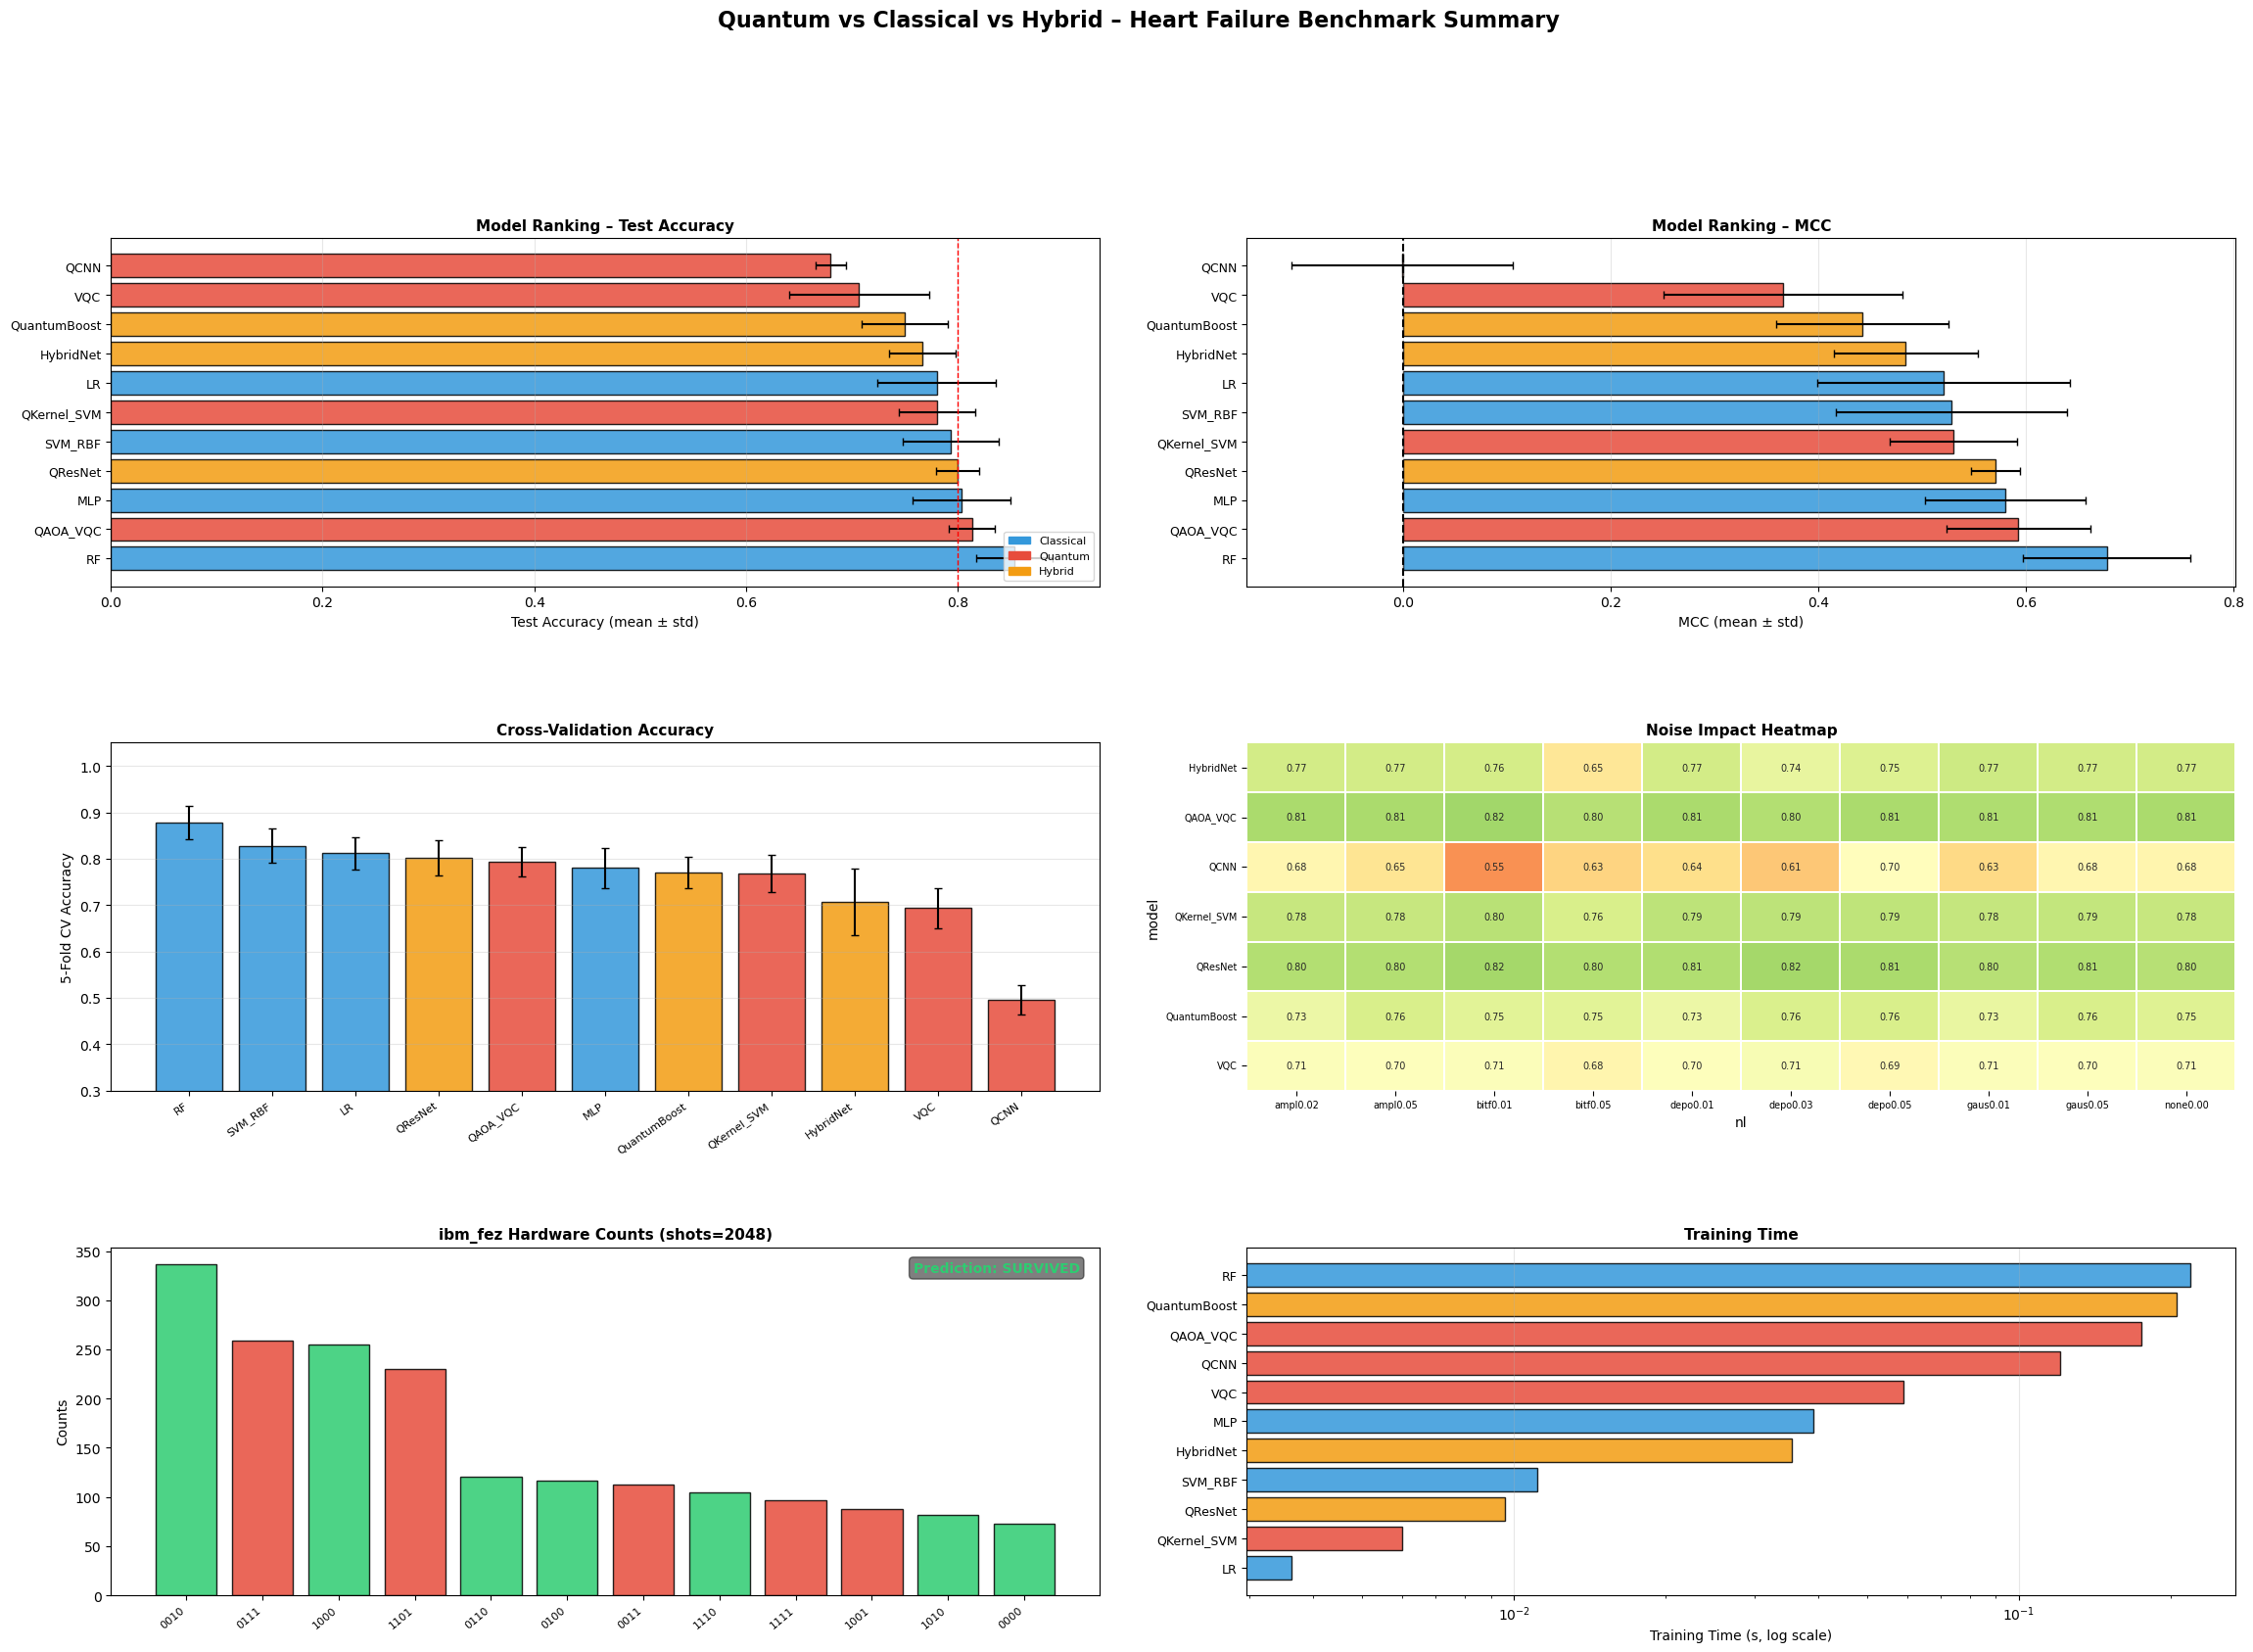

Saved: final_dashboard.png


In [40]:
def plot_final_dashboard(df_main, hw_counts, sim_metrics):
    fig = plt.figure(figsize=(28, 18))
    gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

    df_no = df_main[df_main['noise']=='none']
    order = df_no.groupby('model')['acc'].mean().sort_values(ascending=False).index

    cat_col = {'LR':'#3498db','SVM_RBF':'#3498db','RF':'#3498db','MLP':'#3498db',
               'VQC':'#e74c3c','QCNN':'#e74c3c','QKernel_SVM':'#e74c3c','QAOA_VQC':'#e74c3c',
               'HybridNet':'#f39c12','QuantumBoost':'#f39c12','QResNet':'#f39c12'}

    # 1) Accuracy ranking
    ax1 = fig.add_subplot(gs[0,:2])
    means = df_no.groupby('model')['acc'].mean().loc[order]
    stds = df_no.groupby('model')['acc'].std().loc[order]
    cols = [cat_col.get(m,'gray') for m in order]
    ax1.barh(range(len(order)), means.values, xerr=stds.values,
             color=cols, edgecolor='k', alpha=0.85, capsize=3)
    ax1.set_yticks(range(len(order)))
    ax1.set_yticklabels(order, fontsize=9)
    ax1.set_xlabel('Test Accuracy (mean ± std)')
    ax1.set_title('Model Ranking – Test Accuracy', fontweight='bold', fontsize=11)
    ax1.axvline(0.8, color='red', ls='--', lw=1)
    ax1.grid(axis='x', alpha=0.3)
    legend_h = [mpatches.Patch(color='#3498db', label='Classical'),
                mpatches.Patch(color='#e74c3c', label='Quantum'),
                mpatches.Patch(color='#f39c12', label='Hybrid')]
    ax1.legend(handles=legend_h, fontsize=8, loc='lower right')

    # 2) MCC ranking
    ax2 = fig.add_subplot(gs[0,2:])
    mcc_m = df_no.groupby('model')['mcc'].mean().sort_values(ascending=False)
    mcc_s = df_no.groupby('model')['mcc'].std().loc[mcc_m.index]
    mcc_cols = [cat_col.get(m,'gray') for m in mcc_m.index]
    ax2.barh(range(len(mcc_m)), mcc_m.values, xerr=mcc_s.values,
             color=mcc_cols, edgecolor='k', alpha=0.85, capsize=3)
    ax2.set_yticks(range(len(mcc_m)))
    ax2.set_yticklabels(mcc_m.index, fontsize=9)
    ax2.set_xlabel('MCC (mean ± std)')
    ax2.set_title('Model Ranking – MCC', fontweight='bold', fontsize=11)
    ax2.axvline(0, color='black', lw=1.5, ls='--')
    ax2.grid(axis='x', alpha=0.3)

    # 3) CV comparison
    ax3 = fig.add_subplot(gs[1,:2])
    cv_m = df_no.groupby('model')['cv_mean'].mean().sort_values(ascending=False)
    cv_s = df_no.groupby('model')['cv_std'].mean().loc[cv_m.index]
    ax3.bar(range(len(cv_m)), cv_m.values, yerr=cv_s.values,
            color=[cat_col.get(m,'gray') for m in cv_m.index],
            edgecolor='k', alpha=0.85, capsize=3)
    ax3.set_xticks(range(len(cv_m)))
    ax3.set_xticklabels(cv_m.index, rotation=35, ha='right', fontsize=8)
    ax3.set_ylabel('5-Fold CV Accuracy')
    ax3.set_title('Cross-Validation Accuracy', fontweight='bold', fontsize=11)
    ax3.set_ylim(0.3,1.05); ax3.grid(axis='y', alpha=0.3)

    # 4) Noise heatmap
    ax4 = fig.add_subplot(gs[1,2:])
    qmods = ['VQC','QCNN','QKernel_SVM','QAOA_VQC','HybridNet','QuantumBoost','QResNet']
    df_n = df_main[df_main['model'].isin(qmods)].copy()
    df_n['nl'] = df_n.apply(lambda r: f"{r['noise'][:4]}{r['noise_param']:.2f}", axis=1)
    piv = df_n.pivot_table(index='model', columns='nl', values='acc', aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax4,
                vmin=0.4, vmax=1.0, cbar=False, linewidths=0.3, annot_kws={'size':7})
    ax4.set_title('Noise Impact Heatmap', fontweight='bold', fontsize=11)
    ax4.tick_params(labelsize=7)

    # 5) Hardware counts
    ax5 = fig.add_subplot(gs[2,:2])
    sorted_hw = dict(sorted(hw_counts.items(), key=lambda x:-x[1])[:12])
    hw_cols = ['#e74c3c' if k[-1]=='1' else '#2ecc71' for k in sorted_hw]
    ax5.bar(range(len(sorted_hw)), list(sorted_hw.values()),
            color=hw_cols, edgecolor='k', alpha=0.85)
    ax5.set_xticks(range(len(sorted_hw)))
    ax5.set_xticklabels(list(sorted_hw.keys()), rotation=40, ha='right', fontsize=8)
    ax5.set_title(f"ibm_fez Hardware Counts (shots={sum(hw_counts.values())})",
                  fontweight='bold', fontsize=11)
    ax5.set_ylabel('Counts')
    interp_hw = interpret_hardware_counts(hw_counts)
    ax5.text(0.98, 0.96, f"Prediction: {interp_hw['label']}",
             transform=ax5.transAxes, ha='right', va='top', fontsize=10,
             color='#2ecc71' if interp_hw['prediction']==0 else '#e74c3c',
             fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

    # 6) Training time
    ax6 = fig.add_subplot(gs[2,2:])
    tt_m = df_no.groupby('model')['train_time'].mean().sort_values()
    tt_cs = [cat_col.get(m,'gray') for m in tt_m.index]
    ax6.barh(range(len(tt_m)), tt_m.values, color=tt_cs, edgecolor='k', alpha=0.85)
    ax6.set_xscale('log')
    ax6.set_yticks(range(len(tt_m)))
    ax6.set_yticklabels(tt_m.index, fontsize=9)
    ax6.set_xlabel('Training Time (s, log scale)')
    ax6.set_title('Training Time', fontweight='bold', fontsize=11)
    ax6.grid(axis='x', alpha=0.3)

    fig.suptitle('Quantum vs Classical vs Hybrid – Heart Failure Benchmark Summary',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(RES_DIR + 'final_dashboard.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: final_dashboard.png")


plot_final_dashboard(df_main, hw_counts, sim_metrics)

## 21) Best Model Summary Plots

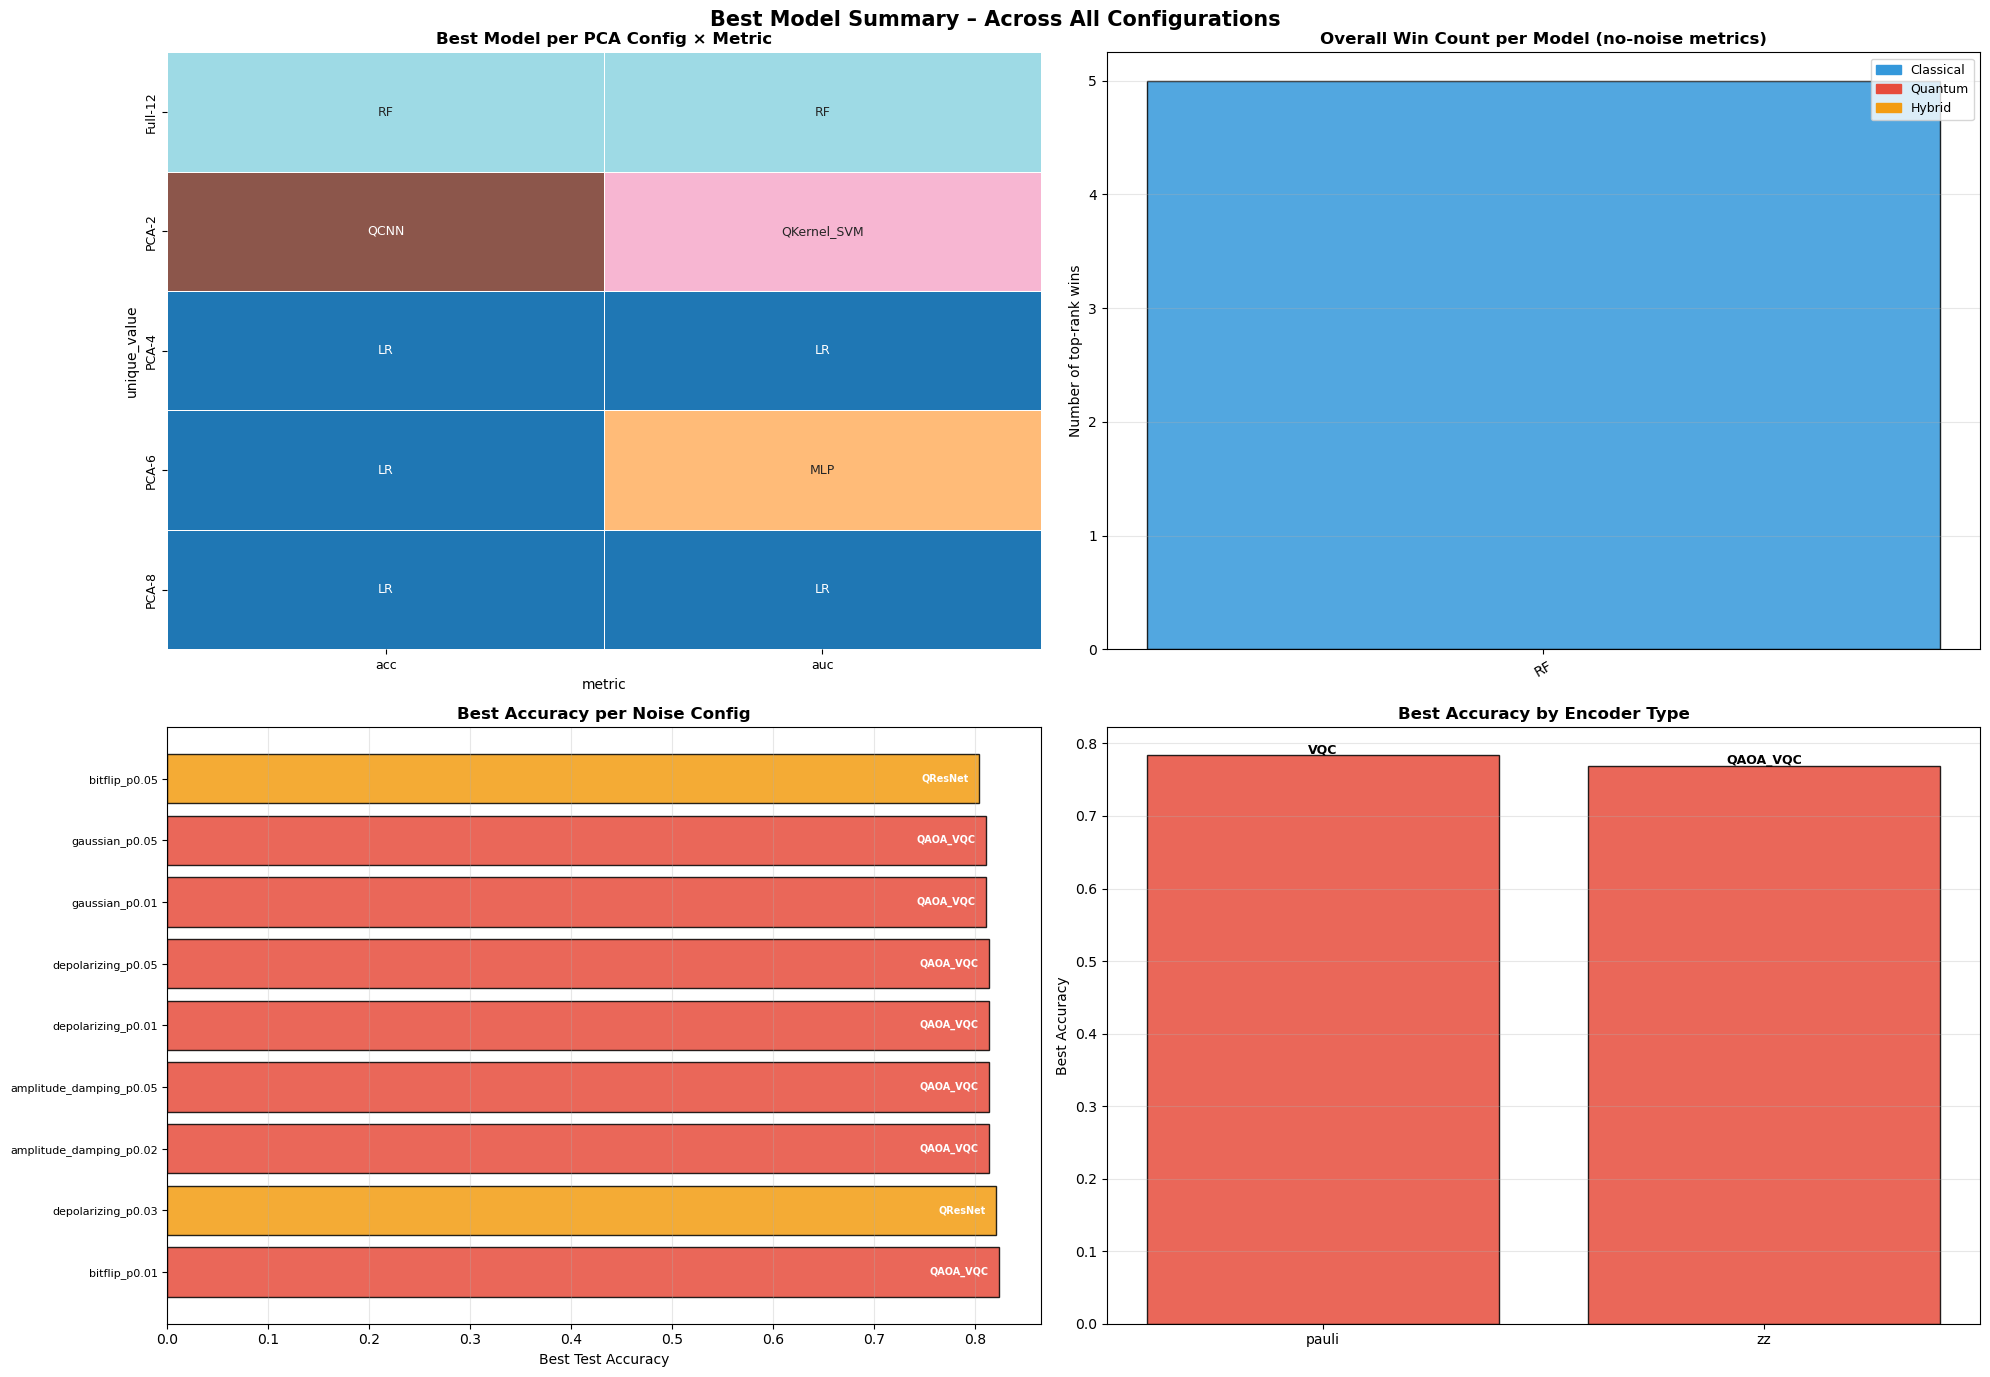

Best model summary plots saved.


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Best Model Summary – Across All Configurations', fontsize=15, fontweight='bold')
axes = axes.flatten()

cat_col = {m:'#3498db' for m in ['LR','SVM_RBF','RF','MLP']}
cat_col.update({m:'#e74c3c' for m in ['VQC','QCNN','QKernel_SVM','QAOA_VQC']})
cat_col.update({m:'#f39c12' for m in ['HybridNet','QuantumBoost','QResNet']})

# 1) Heatmap: best model per PCA config × metric
ax = axes[0]
pca_best = df_best_models[df_best_models['dimension']=='PCAConfig']
if not pca_best.empty:
    piv_pca = pca_best.pivot_table(index='unique_value', columns='metric',
                                    values='best_model', aggfunc='first')
    all_models_list = sorted(df_best_models['best_model'].unique())
    model_idx = {m:i for i,m in enumerate(all_models_list)}
    num_piv = piv_pca.applymap(lambda x: model_idx.get(x, -1))
    sns.heatmap(num_piv, annot=piv_pca.values, fmt='', cmap='tab20',
                linewidths=0.5, ax=ax, cbar=False, annot_kws={'size':9})
    ax.set_title('Best Model per PCA Config × Metric', fontweight='bold')
    ax.tick_params(labelsize=9)
else:
    ax.axis('off'); ax.text(0.5, 0.5, 'No PCA data', ha='center', va='center', transform=ax.transAxes)

# 2) Win counts
ax = axes[1]
overall = df_best_models[df_best_models['dimension']=='Overall_NoNoise']
if not overall.empty:
    win_counts = overall['best_model'].value_counts()
    bar_cols = [cat_col.get(m,'gray') for m in win_counts.index]
    ax.bar(win_counts.index, win_counts.values, color=bar_cols, edgecolor='k', alpha=0.85)
    ax.set_title('Overall Win Count per Model (no-noise metrics)', fontweight='bold')
    ax.set_ylabel('Number of top-rank wins')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    legend_h = [mpatches.Patch(color='#3498db', label='Classical'),
                mpatches.Patch(color='#e74c3c', label='Quantum'),
                mpatches.Patch(color='#f39c12', label='Hybrid')]
    ax.legend(handles=legend_h, fontsize=9)

# 3) Best scores under noise
ax = axes[2]
noise_best = df_best_models[
    (df_best_models['dimension']=='NoiseConfig') &
    (df_best_models['metric']=='acc')]
if not noise_best.empty:
    noise_sorted = noise_best.sort_values('best_score', ascending=False)
    bar_cols_n = [cat_col.get(m,'gray') for m in noise_sorted['best_model']]
    bars = ax.barh(range(len(noise_sorted)), noise_sorted['best_score'],
                   color=bar_cols_n, edgecolor='k', alpha=0.85)
    ax.set_yticks(range(len(noise_sorted)))
    ax.set_yticklabels(noise_sorted['unique_value'], fontsize=8)
    ax.set_xlabel('Best Test Accuracy')
    ax.set_title('Best Accuracy per Noise Config', fontweight='bold')
    for bar, (_, row) in zip(bars, noise_sorted.iterrows()):
        ax.text(bar.get_width()-0.01, bar.get_y()+bar.get_height()/2,
                row['best_model'], va='center', ha='right', fontsize=7,
                color='white', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
else:
    ax.axis('off')

# 4) Best scores per encoder
ax = axes[3]
enc_best = df_best_models[
    (df_best_models['dimension']=='ExtAblation_encoder') &
    (df_best_models['metric']=='acc')]
if not enc_best.empty:
    x_pos = range(len(enc_best))
    bar_cols_e = [cat_col.get(m,'gray') for m in enc_best['best_model']]
    ax.bar(x_pos, enc_best['best_score'], color=bar_cols_e, edgecolor='k', alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(enc_best['unique_value'], fontsize=10)
    ax.set_ylabel('Best Accuracy')
    ax.set_title('Best Accuracy by Encoder Type', fontweight='bold')
    for i, (_, row) in enumerate(enc_best.iterrows()):
        ax.text(i, row['best_score']+0.003, row['best_model'],
                ha='center', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
else:
    axes[3].axis('off')

plt.tight_layout()
plt.savefig(RES_DIR + 'best_model_summary_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("Best model summary plots saved.")

## 22) Save All Results

In [42]:
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# Save main DataFrames
for df_obj, fname in [
    (df_main,        'benchmark_main.csv'),
    (df_input,       'benchmark_input_size.csv'),
    (df_ablation,    'benchmark_ablation.csv'),
    (df_stats,       'statistical_tests.csv'),
    (df_pca_variants,'benchmark_pca_variants.csv'),
    (df_ext_ablation,'benchmark_extended_ablation.csv'),
    (df_best_models, 'best_model_per_config.csv'),
    (df_hw_examples, 'hardware_multi_examples.csv'),
]:
    df_save = df_obj.copy()
    if 'loss_curve' in df_save.columns:
        df_save['loss_curve'] = df_save['loss_curve'].astype(str)
    df_save.to_csv(OUT_DIR + fname, index=False)
    print(f"Saved {fname}")

# Save hardware counts
with open(OUT_DIR + 'ibm_hardware_counts.json', 'w') as f:
    json.dump({'counts': hw_counts,
               'sim_metrics': sim_metrics,
               'hw_metrics': hw_metrics}, f, indent=2)
print("Saved ibm_hardware_counts.json")

print(f"\n✅ All results saved to: {OUT_DIR}")
print(f"✅ All visualizations saved to: {RES_DIR}")

# Final summary
print("\n" + "="*60)
print("HEART FAILURE BENCHMARK – FINAL SUMMARY")
print("="*60)
df_no = df_main[df_main['noise']=='none']
summary_final = df_no.groupby('model').agg(
    Accuracy=('acc', 'mean'),
    AUC=('auc', 'mean'),
    F1=('f1', 'mean'),
    MCC=('mcc', 'mean'),
    CV_Acc=('cv_mean', 'mean')
).round(4).sort_values('Accuracy', ascending=False)
print(summary_final.to_string())
print("="*60)

Saved benchmark_main.csv
Saved benchmark_input_size.csv
Saved benchmark_ablation.csv
Saved statistical_tests.csv
Saved benchmark_pca_variants.csv
Saved benchmark_extended_ablation.csv
Saved best_model_per_config.csv
Saved hardware_multi_examples.csv
Saved ibm_hardware_counts.json

✅ All results saved to: outputs/heartdisease/
✅ All visualizations saved to: results/heartdisease/

HEART FAILURE BENCHMARK – FINAL SUMMARY
              Accuracy     AUC      F1     MCC  CV_Acc
model                                                 
RF              0.8533  0.9186  0.7843  0.6783  0.8782
QAOA_VQC        0.8133  0.8521  0.7258  0.5929  0.7932
MLP             0.8033  0.8798  0.7176  0.5803  0.7802
QResNet         0.8000  0.8603  0.7108  0.5708  0.8016
SVM_RBF         0.7933  0.8709  0.6779  0.5282  0.8281
QKernel_SVM     0.7800  0.8469  0.6821  0.5304  0.7677
LR              0.7800  0.8788  0.6800  0.5205  0.8115
HybridNet       0.7667  0.7887  0.6435  0.4844  0.7074
QuantumBoost    0.7500  0.78